<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/SOT_SAW_Gold_Cluster_Quantum_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SOT control, SAW quantum interconnects, and gold nanocluster spin candidates

## What this experiment-design model computes

An effective spin doublet represents a **conditional spin-active gold nanocluster**, a classical spin-orbit-torque oscillator supplies the local transverse field, and two such spins exchange excitations with one quantized surface acoustic wave cavity mode. The calculations expose requirements for a physical device. Every coherence time, acoustic coupling, source linewidth, and readout pointer separation is an adjustable design input.

The notebook contains finite-pulse Lindblad Rabi dynamics; Ramsey and Hahn-echo signals with an exact idle channel and ideal pulses; a separately labeled spin-1 anharmonicity and qutrit leakage study; thermal acoustic exchange; a Bell overlap and negativity; I/Q shot likelihoods; and deterministic versus Metropolis–Hastings uncertainty integration.

**The gold composition, ligand, charge, substrate attachment, strain tensor, spin Hamiltonian, and readout mechanism still require sample-specific specification.** A large HOMO–LUMO gap, a magnetic moment, and useful microwave coherence describe different measurements. The isolated doublet has two levels, so an oscillator-style $f_{12}-f_{01}$ is undefined inside that basis. The spin-1 sensitivity section supplies an explicit third level without assigning it to the gold sample.

```text
Conditional device model
├── Classical SOT control
│   ├── Axisymmetric LLGS startup and frequency pulling
│   ├── Dipole field at a nearby gold-cluster site
│   └── Steady-source amplitude and relative phase-noise assumptions
├── Gold-cluster effective spin doublet
│   ├── Finite-duration Rabi control and a Bloch-plane trajectory
│   ├── Ramsey, Hahn echo, thermal preparation, and relaxation
│   └── Separate hypothetical multiplet for spectral selectivity
├── Quantized SAW cavity
│   ├── Thermal occupation and automatic oscillator cutoff
│   ├── Two-site excitation transfer and entanglement
│   └── Single-phonon coupling budget and exchange-disabled control
└── Equivalent numerical representations
    ├── Dense Lindblad reference
    ├── Graph-generated local tensor contractions or CSR operators
    ├── Adaptive Dormand–Prince time integration
    └── Metropolis–Hastings integration of classical device uncertainty
```

## Running in Colab

Select a GPU runtime, run the installation cell, inspect `Settings`, and run the remaining cells in order. The simulation selects a checked CuPy backend and has an explicit NumPy fallback. Set `require_gpu=True` to stop whenever CUDA initialization fails. Every scientific figure renders in memory at 250 DPI, with an optional local ZIP export containing PNGs, arrays, settings, and diagnostics.

The complete model is embedded below; a separate source-file download is unnecessary for executing this notebook. The installation cell preserves an existing single CuPy distribution and avoids installing conflicting CUDA wheels. Package versions are recorded in the output.


In [1]:
"""Install the scientific stack and a CUDA-matched CuPy wheel in Colab."""

# --------------------------- Installation controls ---------------------------
INSTALL_PACKAGES = True
CUDA_MAJOR_OVERRIDE = None  # Set to 12 or 13 to select a particular toolkit.

import importlib.metadata
import re
import shutil
import subprocess
import sys

if INSTALL_PACKAGES:
    %pip -q install uv
    !uv pip install --python {sys.executable} "numpy>=2.0,<3" "scipy>=1.14,<2" "matplotlib>=3.9,<4" "networkx>=3.2,<4" "qutip>=5.2,<6"

    gpu_check = subprocess.run(
        ["nvidia-smi", "-L"], capture_output=True, text=True, check=False
    ) if shutil.which("nvidia-smi") else None
    gpu_present = gpu_check is not None and gpu_check.returncode == 0
    installed = [
        dist.metadata["Name"]
        for dist in importlib.metadata.distributions()
        if dist.metadata["Name"].lower().replace("_", "-")
        in {"cupy", "cupy-cuda12x", "cupy-cuda13x", "cupy-cuda11x"}
    ]
    if len(installed) > 1:
        raise RuntimeError(
            "Conflicting CuPy distributions are installed. Start a fresh "
            "Colab runtime with a single CUDA-matched CuPy wheel."
        )
    if gpu_present and len(installed) == 0:
        nvcc = shutil.which("nvcc")
        toolkit_major = None
        if nvcc:
            version_text = subprocess.run(
                [nvcc, "--version"], capture_output=True, text=True,
                check=True,
            ).stdout
            match = re.search(r"release (\d+)\.", version_text)
            toolkit_major = int(match.group(1)) if match else None
        cuda_major = CUDA_MAJOR_OVERRIDE or toolkit_major or 12
        if cuda_major not in (12, 13):
            raise RuntimeError("This installation cell supports CUDA 12 or 13.")
        extras = "" if toolkit_major == cuda_major else "[ctk]"
        cupy_requirement = f"cupy-cuda{cuda_major}x{extras}>=13.6,<15"
        !uv pip install --python {sys.executable} "{cupy_requirement}"
    elif gpu_present:
        print(f"Keeping the existing CuPy distribution: {installed[0]}")
    else:
        print("A CUDA GPU is absent. The model will use its CPU path.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 18.7 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 14 packages in 597ms
Prepared 1 package in 1.23s
Installed 1 package in 60ms
 + qutip==5.3.1
A CUDA GPU is absent. The model will use its CPU path.


## Imports and control knobs

Inspect the physical targets before running the quantum experiments.

In [2]:
"""Explore a conditional SOT-controlled gold-cluster spin and SAW quantum bus.

The figures show macrospin-generated local control, Lindblad Rabi dynamics,
Ramsey and echo signals, an explicitly hypothetical three-level selectivity
study, thermal SAW state transfer and entanglement, and a calibrated-readout
assumption for I/Q shots. Graph-generated dense, local-tensor, and CSR equations
represent the same finite Hilbert space. Metropolis-Hastings samples a static
fabrication-detuning distribution; its steps have no physical-time meaning.

All device numbers are adjustable design assumptions, except fundamental
constants. The model supplies experimental targets, separate from predictions
of the electronic structure of a particular gold cluster. Frequency inputs use
MHz, propagation time uses microseconds, and Hamiltonians use rad/microsecond.
"""

import dataclasses
import io
import json
import math
from pathlib import Path
import time
import platform
import importlib.metadata
from typing import Any, Callable
import warnings
import zipfile

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy.constants as constants
import scipy.integrate as integrate
import scipy.sparse as sp
import scipy.stats as stats

In [3]:
# ------------------------------ Control knobs -------------------------------
@dataclasses.dataclass
class Settings:
    """Collect physical assumptions and numerical resource limits."""

    backend: str = "auto"  # "auto", "cupy", or "numpy".
    require_gpu: bool = False
    sparse_policy: str = "auto"  # "auto", "always", or "never".
    sparse_dimension_threshold: int = 64
    sparse_density_threshold: float = 0.18
    gpu_memory_fraction: float = 0.30
    cpu_memory_budget_gib: float = 1.5
    max_density_dimension: int = 384
    max_batch: int = 128
    relative_tolerance: float = 2.0e-7
    absolute_tolerance: float = 2.0e-9
    maximum_step_us: float = 0.04
    maximum_solver_steps: int = 250_000
    seed: int = 73021
    run_qutip_reference: bool = True
    run_sparse_crosscheck: bool = True
    run_cutoff_crosscheck: bool = True
    run_zero_coupling_control: bool = True
    run_quadrature_crosscheck: bool = True
    run_uncertainty: bool = True
    run_macrospin: bool = True
    display_figures: bool = True
    export_results: bool = True
    output_directory: str = "sot_saw_gold_results"
    dpi: int = 250

    # Spin-doublet targets; these require measurement on the chosen cluster.
    cluster_label: str = "spin-active ligand-protected Au cluster (conditional)"
    qubit_frequency_mhz: float = 1000.0
    electron_g: float = 2.0
    temperature_k: float = 0.020
    t1_zero_temperature_us: float = 50.0
    tphi_intrinsic_us: float = 30.0
    detuning_disorder_mhz: float = 0.050
    source_linewidth_mhz: float = 0.010  # Lorentzian FWHM, white phase diffusion.
    residual_sot_dephasing_per_us: float = 0.0  # SOT off during bus operations.
    actively_prepare_spin_ground: bool = False

    # Classical SOT oscillator: an axisymmetric macrospin design example.
    magnet_ms_a_per_m: float = 8.0e5
    magnet_length_nm: float = 40.0
    magnet_width_nm: float = 25.0
    magnet_thickness_nm: float = 2.0
    magnet_alpha: float = 0.010
    magnet_gamma_rad_per_s_t: float = 1.76085963e11
    easy_plane_field_t: float = -0.020
    target_cone_angle_deg: float = 20.0
    initial_cone_angle_deg: float = 5.0
    spin_torque_efficiency: float = 0.20
    source_to_cluster_nm: float = 80.0
    neighbor_to_source_nm: float = 800.0
    control_mode: str = "circular"  # "circular" or "linear".
    rabi_frequency_override_mhz: float | None = None
    # Relative phase across the two Ramsey pulses, independent of shot phase.
    source_phase_reproducible: bool = True
    macrospin_duration_us: float = 2.0
    channel_length_nm: float = 100.0
    channel_width_nm: float = 40.0
    channel_thickness_nm: float = 4.0
    channel_resistivity_ohm_m: float = 2.0e-6
    source_duty_fraction: float = 0.01

    # Single-mode SAW cavity targets. Coupling is an unmeasured design input.
    saw_frequency_mhz: float = 1000.0
    saw_quality_factor: float = 1.0e5
    saw_coupling_mhz: float = 0.250
    exchange_enabled: bool = True
    saw_velocity_m_per_s: float = 3500.0
    saw_cavity_length_um: float = 175.0
    saw_effective_mass_kg: float = 1.0e-15
    # Absolute matrix element <0|d(H/h)/d(strain)|1>, in Hz per unit strain.
    assumed_transverse_strain_matrix_hz: float = 1.0e11
    assumed_field_gradient_t_per_m: float = 1.0e6
    thermal_tail_tolerance: float = 1.0e-7
    bus_top_population_tolerance: float = 2.0e-5
    bus_levels_override: int | None = None
    minimum_bus_levels: int = 4
    maximum_bus_levels: int = 28
    edge_phase_rad: float = 0.0

    # Deliberately hypothetical spin-1 / three-level design study.
    hypothetical_axial_anisotropy_mhz: float = -40.0
    hypothetical_transverse_anisotropy_mhz: float = 0.0
    hypothetical_dipole_ratio_12_to_01: float = 1.0
    anharmonicity_scan_limit_mhz: float = 400.0
    leakage_rabi_max_mhz: float = 40.0

    # Acquisition assumptions; these supply an I/Q likelihood, not a transducer.
    readout_pointer_separation: float = 3.0
    readout_sigma: float = 0.70
    readout_phase_rad: float = 0.35
    readout_duration_us: float = 0.40
    iq_shots_per_state: int = 1200
    ramsey_shots_per_point: int = 400

    # Resolution and classical uncertainty integration.
    rabi_points: int = 241
    rabi_detuning_points: int = 71
    rabi_cycles: float = 5.0
    ramsey_points: int = 241
    ramsey_detuning_points: int = 81
    ramsey_duration_us: float = 12.0
    bus_points_per_segment: int = 81
    spectrum_points: int = 241
    leakage_alpha_points: int = 151
    leakage_drive_points: int = 65
    quadrature_order: int = 25
    mh_chains: int = 16
    mh_burn_in: int = 256
    mh_production_steps: int = 768
    mh_prediction_samples_per_chain: int = 8
    mh_initial_proposal_scale: float = 1.8


CFG = Settings()

## Hamiltonians, rates, and physical assumptions

For the single-spin driven experiment, the rotating-frame Hamiltonian is

$$
\frac{H_q}{\hbar}=\Delta n+\frac{\Omega}{2}\sigma_x,
\qquad n=|1\rangle\langle1|,
\qquad \Omega=2\pi f_R.
$$

For two spin sites and one acoustic mode, the rotating frame follows the SAW frequency,

$$
\frac{H_{\mathrm{bus}}}{\hbar}
=\sum_{j=A,B}\Delta_j n_j+
\sum_{j=A,B}\left(g_j(t)e^{i\phi_j}\sigma_j^+a+
 g_j(t)e^{-i\phi_j}\sigma_j^-a^\dagger\right).
$$

Each edge in the NetworkX graph generates its corresponding product operator. During a transfer, the A edge acts for $\pi/(2g)$ and the B edge subsequently acts for the same duration. During Bell preparation, the first duration is $\pi/(4g)$ and the second is $\pi/(2g)$. Edge switching is idealized; a real device needs a demonstrated detuning or coupling-control mechanism. Spin A is ideally prepared excited for these sequences, spin B is thermal unless reset is enabled, and the acoustic mode starts thermal. Thus the final $P_B$ is an excitation-transfer population, separate from average process fidelity.

Open-system evolution uses

$$
\dot\rho=-\frac{i}{\hbar}[H,\rho]+
\sum_k\mathcal{D}[L_k]\rho,
\qquad
\mathcal{D}[L]\rho=L\rho L^\dagger-\frac12\{L^\dagger L,\rho\}.
$$

The spin collapse operators are $\sqrt{\gamma_\downarrow}\sigma_-$,
$\sqrt{\gamma_\uparrow}\sigma_+$, and $\sqrt{2\gamma_\phi}n$.
A bosonic thermal bath gives $\gamma_\downarrow=(1+\bar n_q)/T_{1,0}$ and
$\gamma_\uparrow=\bar n_q/T_{1,0}$ in this illustrative rate model. The bus uses
$\sqrt{\kappa(1+\bar n_b)}a$ and $\sqrt{\kappa\bar n_b}a^\dagger$, with

$$
\bar n_b=\frac{1}{\exp(hf_b/k_BT)-1},
\qquad \kappa=\frac{2\pi f_b}{Q_b}.
$$

This is a local, weak-coupling, Markovian bath approximation close to resonance. Rates are evaluated at the nominal transition frequencies. Strong dressing, structured noise, and large detunings call for dressed-state or spectral-density treatments. Frequency inputs are MHz; time is microseconds; every Hamiltonian used in propagation is rad/µs.

### How the control source connects to the quantum model

The axisymmetric macrospin uses

$$
\dot\theta=\frac{\gamma_m}{1+\alpha_G^2}
\left[B_{\mathrm{DL}}-\alpha_G(B_0+B_K\cos\theta)\right]\sin\theta,
$$

$$
\dot\phi=\frac{\gamma_m}{1+\alpha_G^2}
\left[B_0+B_K\cos\theta+\alpha_G B_{\mathrm{DL}}\right].
$$

Choosing $B_K<0$ gives a stable-cone effective model. The elliptical footprint supplies a volume estimate; a micromagnetic calculation must replace the axisymmetric anisotropy approximation for a real patterned source. The source drive is a damping-like SOT parameterized by

$$
B_{\mathrm{DL}}=\frac{\hbar\theta_{\mathrm{DL}}J}{2eM_st_F}.
$$

At a site on the dipole axis,

$$
B_\perp=\frac{\mu_0M_sV}{4\pi r^3}\sin\theta,
\qquad
f_R=\frac{g_e\mu_B}{h}B_\perp
$$

for a co-rotating circular field. A linearly oscillating field of the same peak amplitude contributes half this resonant drive. The source requires about 54.5 mT bias in the default anisotropy model, whereas the chosen spin Zeeman frequency requires about 35.7 mT. Matching both to 1 GHz requires independent local bias or anisotropy engineering; one uniform field would generally miss this matching condition. The quantum calculations use the settled source and ideal envelope gating. Startup chirp and the settling time appear in separate figures, so a cold-start SOT pulse should be checked against those traces before interpreting a short square-pulse gate.

The source linewidth is an independent Lorentzian design input, mapped to white relative-phase diffusion with $\gamma_{\phi,\mathrm{source}}=\pi\Delta f_{\mathrm{FWHM}}$. Deriving that linewidth would require stochastic micromagnetics and a calibrated noise model. Absolute oscillator phase may vary across repetitions if the two pulses within a Ramsey pair retain their relative phase. Setting `source_phase_reproducible=False` models a uniformly randomized **relative** phase between the two pulses. It then removes ensemble Ramsey contrast. SOT-off dephasing during bus operations has a separate knob. The electrical power calculation is $J^2\rho V$; local heating needs a measured thermal impedance or a heat-transport model.

### The single-phonon matrix element is a central experimental target

The geometric scale estimates are

$$
x_{\mathrm{zpf}}=\sqrt{\frac{\hbar}{2m_{\mathrm{eff}}\omega_b}},
\qquad \epsilon_{\mathrm{zpf}}\simeq kx_{\mathrm{zpf}}.
$$

Define the transverse matrix element explicitly,

$$
\Lambda_{01}=\left|\left\langle0\left|
\frac{\partial(H/h)}{\partial\epsilon}\right|1\right\rangle\right|,
\qquad
\frac{g}{2\pi}=\Lambda_{01}\epsilon_{\mathrm{zpf}}.
$$

A strain-induced transition-frequency shift usually measures a diagonal susceptibility. It supplies this exchange coupling only after its transverse matrix element has been established. The default $10^{11}$ Hz/strain is an assumed $\Lambda_{01}$, including its orientation and selection-rule projection. The effective mass and strain estimate also require a finite-element acoustic mode calculation. A transverse magnetic-gradient alternative gives

$$
\frac{g_{\mathrm{gradient}}}{2\pi}
=\frac{g_e\mu_B}{2h}G_\perp x_{\mathrm{zpf}}.
$$

At the supplied design point, these estimates are approximately 520 Hz and 41 Hz, compared with the adjustable 250 kHz target used by the quantum-bus plots. They expose a coupling gap. A resolved classical SAW-driven spin signal alone supplies neither the single-phonon value nor a quantum-transfer benchmark. The geometric estimates are diagnostics; changing `saw_coupling_mhz` explicitly changes the dynamics.

### Anharmonicity and readout

For an isolated spin doublet, $f_{12}$ lies outside the model. A separate hypothetical spin-1 Hamiltonian

$$
\frac{H_{S=1}}{h}=f_ZS_z+D_f\left(S_z^2-\frac23 I\right)
+E_f(S_x^2-S_y^2)
$$

produces three eigenenergies and an explicit $\alpha/(2\pi)=f_{12}-f_{01}$. Here $D_f$ and $E_f$ are in frequency units; plots label them as $D/h$ and $E/h$. With $E_f=0$ and the ordering used in the default scan, $\alpha/(2\pi)=2D_f$. A separate qutrit rotating-wave square-pulse calculation maps leakage versus spectral isolation and Rabi rate. These sections measure sensitivity to an assumed level structure; they supply zero material-specific predictions about the gold-cluster spectrum.

The I/Q plots simulate a classical spin-dependent pointer, Gaussian amplifier noise, and thermal spin jumps during an integration window. Both pointer calibration and a working spin-to-detector transducer are inputs. The displayed assignment score is separate from QND fidelity, measurement-induced dephasing, detector efficiency, and gate performance.


## Dense reference and adaptive graph–tensor–MH comparison

Both deterministic representations evolve the **same complex density matrix and the same Lindblad generator**. Local tensor contractions use the subsystem factorization $(2,2,N_b)$; CSR multiplication uses sparse Hamiltonian and collapse operators. Neither method builds a $D^2\times D^2$ Liouvillian. Density storage still scales as $D^2$, so this two-spin benchmark is a building block for an architecture study with an explicit full-density size cap.

| Adaptation | Decision implemented | Override or limit |
| :--- | :--- | :--- |
| Array backend | CUDA allocation, arithmetic, eigensolver, and CSR smoke checks | `backend`, `require_gpu` |
| Acoustic Hilbert cutoff | Bose-tail tolerance plus room for two spin excitations | `bus_levels_override`, `maximum_bus_levels` |
| Time integration | Embedded Dormand–Prince 5(4) local-error estimate | `relative_tolerance`, `absolute_tolerance`, `maximum_step_us` |
| Sparse operators | Hilbert dimension and graph-operator fill fraction | `sparse_policy`, size and density thresholds |
| Predictive batching | Available-memory estimate and full-density workspace budget | `max_batch`, GPU fraction, CPU budget, dimension cap |
| MH proposals | Tune the symmetric random-walk scale during burn-in | Burn-in length, initial proposal scale |
| Convergence diagnostics | Trace, Hermiticity, positivity, cutoff and representation agreement | Explicit failure thresholds in the functions |

Automatic selection is rule-based and visible in the reports. A cutoff, memory, or step-cap failure stops the run instead of discarding additional physical states. The code keeps complex128 arithmetic. GPU dispatch can be slower for tiny state spaces, and the measured timing table separates workload size from speedup assertions.

Metropolis–Hastings samples a classical static-detuning prior. For standardized detuning $z$, the demonstration target is $p(z)\propto\exp(-z^2/2)$, with a symmetric proposal and acceptance

$$
A(z\rightarrow z')=\min\left[1,\exp\left(-\frac{z'^2-z^2}{2}\right)\right].
$$

Production begins after proposal adaptation stops. Each retained draw initializes a new quantum-dynamics prediction; a Monte Carlo step has no physical-time interpretation. Dense Gauss–Hermite integration of the **same prior** supplies an independent ensemble reference. The notebook reports a classic split $\hat R$, an approximate autocorrelation effective sample size, prediction count, and a chain-based Monte Carlo standard error. Its predictive percentiles describe device variation, whereas its mean interval describes sampling error. A narrow statistical interval leaves material-model uncertainty untouched.

For this one-dimensional Gaussian demonstration, deterministic quadrature is economical. MH earns a stronger role with a fitted, higher-dimensional or non-Gaussian posterior. The current prior is a design distribution, separate from a posterior inferred from experimental data. The default 128 quantum predictions produce a visible finite-sampling discrepancy; increasing the production chain length alone leaves the retained prediction count unchanged.

The independent dynamics checks include the analytic resonant zero-loss Rabi limit, SciPy DOP853, optional QuTiP `mesolve`, dense versus tensor versus CSR propagation, two extra oscillator levels, eight extra quadrature nodes, and an exchange-disabled Bell control. The shipped reference run exercised the CPU, tensor, CSR, and SciPy paths. Its environment had neither a CUDA GPU nor an installed QuTiP package. Colab executes those optional checks after installation.


In [4]:
# ---------------------------- Array-backend setup ---------------------------
class Backend:
    """Provide a checked NumPy/CuPy backend with explicit resource reporting."""

    def __init__(self, cfg: Settings):
        """Select a backend and exercise GPU allocation and eigensolvers."""
        self.xp = np
        self.sparse = sp
        self.gpu = False
        self.name = "NumPy / CPU"
        if cfg.backend in ("auto", "cupy"):
            try:
                import cupy as cp
                import cupyx.scipy.sparse as csp

                if cp.cuda.runtime.getDeviceCount() < 1:
                    raise RuntimeError("CUDA reports zero devices.")
                test = cp.eye(3, dtype=cp.complex128)
                cp.linalg.eigh(test)
                cp.sum(cp.sin(cp.arange(8, dtype=cp.float64))).item()
                csp.csr_matrix(test).dot(test)
                cp.cuda.Stream.null.synchronize()
                self.xp, self.sparse = cp, csp
                self.gpu = True
                props = cp.cuda.runtime.getDeviceProperties(0)
                name = props["name"]
                if isinstance(name, bytes):
                    name = name.decode()
                self.name = f"CuPy {cp.__version__} / {name}"
            except Exception as exc:
                if cfg.backend == "cupy" or cfg.require_gpu:
                    raise RuntimeError(
                        "GPU initialization failed. Use a Colab GPU runtime "
                        "and the CUDA-matched CuPy wheel."
                    ) from exc
                warnings.warn(f"Using CPU fallback: {exc}", stacklevel=2)
        elif cfg.backend != "numpy":
            raise ValueError("backend must be auto, cupy, or numpy.")
        if cfg.require_gpu and self.gpu is False:
            raise RuntimeError("require_gpu=True requires a working CUDA GPU.")
        if self.gpu:
            free, _ = self.xp.cuda.runtime.memGetInfo()
            self.memory_budget = int(free * cfg.gpu_memory_fraction)
        else:
            self.memory_budget = int(cfg.cpu_memory_budget_gib * 1024**3)
        self.rng = self.xp.random.RandomState(cfg.seed)

    def host(self, array: Any) -> np.ndarray:
        """Copy an array to host memory for reporting and plotting."""
        return self.xp.asnumpy(array) if self.gpu else np.asarray(array)

    def scalar(self, value: Any) -> float:
        """Return a real scalar, synchronizing the GPU if required."""
        return float(value.item() if hasattr(value, "item") else value)

    def synchronize(self) -> None:
        """Complete queued GPU work before timing a calculation."""
        if self.gpu:
            self.xp.cuda.Stream.null.synchronize()

In [5]:
# ---------------------------- Physical bookkeeping ---------------------------
def validate_settings(cfg: Settings) -> None:
    """Reject incompatible settings and invalid physical rates."""
    positive = (
        "qubit_frequency_mhz", "saw_frequency_mhz", "electron_g",
        "t1_zero_temperature_us", "tphi_intrinsic_us", "saw_quality_factor",
        "saw_coupling_mhz", "source_to_cluster_nm", "saw_effective_mass_kg",
        "readout_sigma", "magnet_alpha", "spin_torque_efficiency",
        "readout_duration_us", "maximum_step_us", "relative_tolerance",
        "absolute_tolerance", "cpu_memory_budget_gib", "magnet_ms_a_per_m",
        "magnet_length_nm", "magnet_width_nm", "magnet_thickness_nm",
        "neighbor_to_source_nm", "saw_velocity_m_per_s",
        "saw_cavity_length_um", "thermal_tail_tolerance",
        "bus_top_population_tolerance", "ramsey_duration_us",
    )
    for name in positive:
        if getattr(cfg, name) <= 0:
            raise ValueError(f"{name} must be positive.")
    if cfg.rabi_detuning_points % 2 == 0:
        raise ValueError("Use an odd rabi_detuning_points to include resonance.")
    if cfg.quadrature_order < 5:
        raise ValueError("Use quadrature_order >= 5.")
    if cfg.temperature_k < 0 or cfg.source_linewidth_mhz < 0:
        raise ValueError("Temperature and source linewidth must be nonnegative.")
    if cfg.detuning_disorder_mhz < 0:
        raise ValueError("The detuning standard deviation must be nonnegative.")
    if cfg.residual_sot_dephasing_per_us < 0:
        raise ValueError("The residual SOT dephasing rate must be nonnegative.")
    if not 0 <= cfg.source_duty_fraction <= 1:
        raise ValueError("The source duty fraction must lie between zero and one.")
    if cfg.sparse_policy not in ("auto", "always", "never"):
        raise ValueError("sparse_policy must be auto, always, or never.")
    if cfg.control_mode not in ("linear", "circular"):
        raise ValueError("control_mode must be circular or linear.")
    if cfg.easy_plane_field_t >= 0:
        raise ValueError("The stable-cone source model requires an easy plane.")
    if not 0 < cfg.target_cone_angle_deg < 90:
        raise ValueError("The source cone angle must lie between 0 and 90 deg.")
    if not 0 < cfg.gpu_memory_fraction < 0.8:
        raise ValueError("gpu_memory_fraction must lie between 0 and 0.8.")
    if cfg.mh_chains < 4 or cfg.mh_prediction_samples_per_chain < 2:
        raise ValueError("Use at least four MH chains and two predictive draws.")
    if cfg.mh_production_steps < 4 * cfg.mh_prediction_samples_per_chain:
        raise ValueError("Increase MH production steps for predictive thinning.")


def bose_occupation(frequency_mhz: Any, temperature_k: Any) -> np.ndarray:
    """Evaluate a Bose occupation with a well-defined zero-temperature limit."""
    f, temp = np.broadcast_arrays(
        np.asarray(frequency_mhz, dtype=float),
        np.asarray(temperature_k, dtype=float),
    )
    safe_temp = np.maximum(temp, np.finfo(float).tiny)
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        ratio = constants.h * f * 1e6 / (constants.k * safe_temp)
        value = 1.0 / np.expm1(np.minimum(ratio, 745.0))
    return np.where(temp <= 0, 0.0, value)


def physical_parameters(cfg: Settings) -> dict[str, float]:
    """Derive rates, SOT fields, acoustic scales, and coupling requirements."""
    mu_b = constants.physical_constants["Bohr magneton"][0]
    gamma_hz_t = cfg.electron_g * mu_b / constants.h
    fq = cfg.qubit_frequency_mhz * 1e6
    fs = cfg.saw_frequency_mhz * 1e6
    n_q = float(bose_occupation(cfg.qubit_frequency_mhz, cfg.temperature_k))
    n_b = float(bose_occupation(cfg.saw_frequency_mhz, cfg.temperature_k))
    gamma_down = (1 + n_q) / cfg.t1_zero_temperature_us
    gamma_up = n_q / cfg.t1_zero_temperature_us
    gamma_phi = 1.0 / cfg.tphi_intrinsic_us
    source_phi = np.pi * cfg.source_linewidth_mhz
    theta = np.deg2rad(cfg.target_cone_angle_deg)
    b_eff = 2 * np.pi * fq / cfg.magnet_gamma_rad_per_s_t
    b_bias = b_eff - cfg.easy_plane_field_t * np.cos(theta)
    b_dl = cfg.magnet_alpha * b_eff
    volume = (
        np.pi / 4 * cfg.magnet_length_nm * cfg.magnet_width_nm
        * cfg.magnet_thickness_nm * 1e-27
    )
    b_coefficient = (
        constants.mu_0 * cfg.magnet_ms_a_per_m * volume
        / (4 * np.pi * (cfg.source_to_cluster_nm * 1e-9)**3)
    )
    b_circular = b_coefficient * np.sin(theta)
    polarization = 1.0 if cfg.control_mode == "circular" else 0.5
    f_rabi = gamma_hz_t * b_circular * polarization / 1e6
    if cfg.rabi_frequency_override_mhz is not None:
        if cfg.rabi_frequency_override_mhz <= 0:
            raise ValueError("The Rabi frequency override must be positive.")
        f_rabi = cfg.rabi_frequency_override_mhz
    current_density = (
        2 * constants.e * cfg.magnet_ms_a_per_m
        * cfg.magnet_thickness_nm * 1e-9 * b_dl
        / (constants.hbar * cfg.spin_torque_efficiency)
    )
    channel_volume = (
        cfg.channel_length_nm * cfg.channel_width_nm
        * cfg.channel_thickness_nm * 1e-27
    )
    power_w = current_density**2 * cfg.channel_resistivity_ohm_m * channel_volume
    x_zpf = np.sqrt(constants.hbar / (2 * cfg.saw_effective_mass_kg * 2 * np.pi * fs))
    strain_zpf = 2 * np.pi * fs / cfg.saw_velocity_m_per_s * x_zpf
    gradient_g = gamma_hz_t * cfg.assumed_field_gradient_t_per_m * x_zpf / 2
    strain_g = cfg.assumed_transverse_strain_matrix_hz * strain_zpf
    kappa = 2 * np.pi * cfg.saw_frequency_mhz / cfg.saw_quality_factor
    gamma_2 = 0.5 * (gamma_down + gamma_up) + gamma_phi
    length = cfg.saw_cavity_length_um * 1e-6
    return {
        "fq_mhz": cfg.qubit_frequency_mhz,
        "nbar_qubit": n_q, "nbar_bus": n_b,
        "thermal_spin_excited_probability": n_q / (2 * n_q + 1),
        "gamma_down_per_us": gamma_down, "gamma_up_per_us": gamma_up,
        "gamma_phi_per_us": gamma_phi, "source_phi_per_us": source_phi,
        "gamma_2_idle_per_us": gamma_2,
        "t1_at_temperature_us": 1 / (gamma_down + gamma_up),
        "t2_idle_us": 1 / gamma_2,
        "t2_source_referenced_us": 1 / (gamma_2 + source_phi),
        "cluster_bias_t": fq / gamma_hz_t,
        "source_bias_t": b_bias, "source_effective_field_t": b_eff,
        "source_bdl_t": b_dl, "source_field_peak_t": b_circular,
        "source_dipole_coefficient_t": b_coefficient,
        "rabi_frequency_mhz": f_rabi, "pi_pulse_us": 1 / (2 * f_rabi),
        "current_density_a_per_m2": current_density,
        "source_power_w": power_w,
        "source_average_power_w": power_w * cfg.source_duty_fraction,
        "neighbor_rabi_ratio": (cfg.source_to_cluster_nm / cfg.neighbor_to_source_nm)**3,
        "x_zpf_m": x_zpf, "strain_zpf": strain_zpf,
        "gradient_coupling_estimate_hz": gradient_g,
        "strain_coupling_estimate_hz": strain_g,
        "required_transverse_strain_matrix_hz": cfg.saw_coupling_mhz * 1e6 / strain_zpf,
        "required_gradient_t_per_m": cfg.saw_coupling_mhz * 1e6 * 2 / (gamma_hz_t * x_zpf),
        "bus_kappa_per_us": kappa, "bus_energy_lifetime_us": 1 / kappa,
        "bus_linewidth_hz": fs / cfg.saw_quality_factor,
        "saw_wavelength_um": cfg.saw_velocity_m_per_s / fs * 1e6,
        "saw_transit_us": length / cfg.saw_velocity_m_per_s * 1e6,
        "saw_fsr_mhz": cfg.saw_velocity_m_per_s / (2 * length) / 1e6,
        "full_swap_us": 1 / (4 * cfg.saw_coupling_mhz),
        "cooperativity_convention_4g2_over_kappa_gamma2":
            4 * (2 * np.pi * cfg.saw_coupling_mhz)**2 / (kappa * gamma_2),
    }


def choose_bus_levels(cfg: Settings, pars: dict[str, float]) -> tuple[int, float]:
    """Cover the thermal tail and two initially available spin excitations."""
    occupation = pars["nbar_bus"]
    ratio = occupation / (occupation + 1)
    thermal_levels = 1 if ratio == 0 else math.ceil(
        math.log(cfg.thermal_tail_tolerance) / math.log(ratio)
    )
    needed = max(cfg.minimum_bus_levels, thermal_levels + 2)
    levels = cfg.bus_levels_override if cfg.bus_levels_override is not None else needed
    if levels < 3:
        raise ValueError("Use at least three SAW oscillator levels.")
    if levels > cfg.maximum_bus_levels:
        raise RuntimeError(
            f"Thermal occupation requires {levels} bus levels, exceeding the "
            f"configured cap {cfg.maximum_bus_levels}. Increase the cap and "
            "memory budget or choose a colder / higher-frequency scenario."
        )
    tail = ratio**levels
    if tail > cfg.thermal_tail_tolerance:
        raise RuntimeError("The requested oscillator cutoff discards excessive thermal weight.")
    return levels, tail

In [6]:
# --------------------------- Numerical infrastructure -----------------------
def density_diagnostics(rho: Any, backend: Backend) -> dict[str, float]:
    """Measure trace, Hermiticity, and positivity without repairing states."""
    array = backend.host(rho).reshape(-1, rho.shape[-1], rho.shape[-1])
    adjoint = array.conj().swapaxes(-1, -2)
    return {
        "max_trace_error": float(np.max(np.abs(np.trace(array, axis1=-2, axis2=-1) - 1))),
        "max_hermiticity_error": float(np.max(np.abs(array - adjoint))),
        "minimum_eigenvalue": float(np.linalg.eigvalsh((array + adjoint) / 2).min()),
    }


def check_density(rho: Any, backend: Backend, label: str) -> dict[str, float]:
    """Stop if integrated states exceed explicitly chosen physical tolerances."""
    report = density_diagnostics(rho, backend)
    if (report["max_trace_error"] > 2e-5
            or report["max_hermiticity_error"] > 2e-5
            or report["minimum_eigenvalue"] < -2e-5):
        raise RuntimeError(f"Density-matrix check failed for {label}: {report}")
    return report


def evolve(
    rhs: Callable[[Any], Any],
    initial: Any,
    times: np.ndarray,
    backend: Backend,
    cfg: Settings,
    observe: Callable[[Any], Any] | None = None,
) -> tuple[Any, Any, dict[str, Any]]:
    """Integrate an autonomous equation using an embedded Dormand-Prince pair.

    Args:
        rhs: Derivative function acting on batched density matrices.
        initial: Batch of complex density matrices.
        times: Increasing requested output times, in microseconds.
        backend: Checked array backend.
        cfg: Tolerance and resource controls.
        observe: Optional reduced observable function; omitting it stores states.

    Returns:
        Final states, stacked observations, and numerical work diagnostics.
    """
    xp = backend.xp
    times = np.asarray(times, dtype=float)
    if times.ndim != 1 or times.size < 2 or np.any(np.diff(times) <= 0):
        raise ValueError("times must be a strictly increasing one-dimensional array.")
    y = xp.asarray(initial, dtype=xp.complex128).copy()
    read = (lambda state: state.copy()) if observe is None else observe
    observations = [read(y)]
    current = float(times[0])
    step = min(cfg.maximum_step_us, float(times[1] - times[0]))
    accepted = rejected = 0
    min_step = float("inf")
    max_error = 0.0
    backend.synchronize()
    started = time.perf_counter()
    for endpoint in times[1:]:
        while current < endpoint - 1e-13:
            if accepted + rejected >= cfg.maximum_solver_steps:
                raise RuntimeError("Solver step cap reached; inspect stiffness and tolerances.")
            h = min(step, float(endpoint - current), cfg.maximum_step_us)
            if h < 1e-12:
                raise RuntimeError("Adaptive step underflow; inspect model scales.")
            k1 = rhs(y)
            k2 = rhs(y + h * k1 / 5)
            k3 = rhs(y + h * (3 * k1 / 40 + 9 * k2 / 40))
            k4 = rhs(y + h * (44 * k1 / 45 - 56 * k2 / 15 + 32 * k3 / 9))
            k5 = rhs(y + h * (
                19372 * k1 / 6561 - 25360 * k2 / 2187
                + 64448 * k3 / 6561 - 212 * k4 / 729
            ))
            k6 = rhs(y + h * (
                9017 * k1 / 3168 - 355 * k2 / 33 + 46732 * k3 / 5247
                + 49 * k4 / 176 - 5103 * k5 / 18656
            ))
            y5 = y + h * (35 * k1 / 384 + 500 * k3 / 1113 + 125 * k4 / 192
                          - 2187 * k5 / 6784 + 11 * k6 / 84)
            k7 = rhs(y5)
            y4 = y + h * (
                5179 * k1 / 57600 + 7571 * k3 / 16695 + 393 * k4 / 640
                - 92097 * k5 / 339200 + 187 * k6 / 2100 + k7 / 40
            )
            scale = cfg.absolute_tolerance + cfg.relative_tolerance * xp.maximum(
                xp.abs(y), xp.abs(y5)
            )
            error = backend.scalar(xp.max(xp.abs(y5 - y4) / scale))
            if math.isfinite(error) is False:
                raise FloatingPointError("A nonfinite local solver error occurred.")
            if error <= 1.0:
                y = y5
                current += h
                accepted += 1
                min_step = min(min_step, h)
                max_error = max(max_error, error)
            else:
                rejected += 1
            factor = 4.0 if error == 0 else float(np.clip(0.9 * error**(-0.2), 0.15, 4.0))
            step = h * factor
        observations.append(read(y))
    backend.synchronize()
    return y, xp.stack(observations), {
        "accepted_steps": accepted, "rejected_steps": rejected,
        "minimum_step_us": min_step, "maximum_accepted_scaled_error": max_error,
        "wall_seconds": time.perf_counter() - started,
    }


def direct_rhs(hamiltonian: Any, collapses: list[Any], backend: Backend) -> Callable:
    """Compile a dense, batched Lindblad derivative."""
    xp = backend.xp
    ham = xp.asarray(hamiltonian, dtype=xp.complex128)
    prepared = []
    for operator in collapses:
        c = xp.asarray(operator, dtype=xp.complex128)
        cd = c.conj().swapaxes(-1, -2)
        prepared.append((c, cd, cd @ c))

    def derivative(rho: Any) -> Any:
        """Evaluate coherent motion and completely positive dissipators."""
        result = -1j * (ham @ rho - rho @ ham)
        for c, cd, cc in prepared:
            result = result + c @ rho @ cd - 0.5 * (cc @ rho + rho @ cc)
        return result

    return derivative


def spin_collapses(cfg: Settings, pars: dict[str, float], source_on: bool) -> list[np.ndarray]:
    """Construct spin rates with detailed balance and a stated source-noise model."""
    sm = np.array([[0, 1], [0, 0]], dtype=complex)
    number = np.diag([0.0, 1.0]).astype(complex)
    phi = pars["gamma_phi_per_us"]
    phi += pars["source_phi_per_us"] if source_on else cfg.residual_sot_dephasing_per_us
    return [np.sqrt(pars["gamma_down_per_us"]) * sm,
            np.sqrt(pars["gamma_up_per_us"]) * sm.conj().T,
            np.sqrt(2 * phi) * number]

In [7]:
# ------------------------- Graph and tensor operators -----------------------
@dataclasses.dataclass
class ProductTerm:
    """Represent a Hamiltonian coefficient and local operator factors."""

    coefficient: Any
    factors: tuple[tuple[int, np.ndarray], ...]


class BusModel:
    """Compile a two-spin SAW graph into dense, local-tensor, or CSR dynamics."""

    def __init__(self, cfg: Settings, pars: dict[str, float], levels: int):
        """Build the local Hilbert spaces and physical coupling graph."""
        self.cfg, self.pars = cfg, pars
        self.dims = (2, 2, levels)
        self.dimension = 4 * levels
        self.sm = np.array([[0, 1], [0, 0]], dtype=complex)
        self.number = self.sm.conj().T @ self.sm
        self.a = np.diag(np.sqrt(np.arange(1, levels)), 1).astype(complex)
        self.nb = self.a.conj().T @ self.a
        self.graph = nx.Graph()
        self.graph.add_node("Au A", site=0, kind="spin")
        self.graph.add_node("Au B", site=1, kind="spin")
        self.graph.add_node("SAW", site=2, kind="oscillator")
        self.graph.add_edge("Au A", "SAW", g_mhz=cfg.saw_coupling_mhz, phase=0.0)
        self.graph.add_edge("Au B", "SAW", g_mhz=cfg.saw_coupling_mhz,
                            phase=cfg.edge_phase_rad)
        self.local_collapses = []
        for site in (0, 1):
            for c in spin_collapses(cfg, pars, source_on=False):
                self.local_collapses.append((site, c))
        kappa, nbar = pars["bus_kappa_per_us"], pars["nbar_bus"]
        self.local_collapses.extend([
            (2, np.sqrt(kappa * (nbar + 1)) * self.a),
            (2, np.sqrt(kappa * nbar) * self.a.conj().T),
        ])

    def embed(self, factors: tuple, sparse: bool = False) -> Any:
        """Construct a product operator with identities on unused sites."""
        factor_map = dict(factors)
        result = sp.csr_matrix([[1.0 + 0j]]) if sparse else np.array([[1.0 + 0j]])
        for site, size in enumerate(self.dims):
            local = factor_map.get(site, np.eye(size, dtype=complex))
            result = sp.kron(result, sp.csr_matrix(local), format="csr") if sparse else np.kron(result, local)
        return result

    def terms(self, active_spin: int, mismatch_mhz: Any = 0.0) -> list[ProductTerm]:
        """Generate interactions from graph edges and antisymmetric detuning."""
        mismatch = np.asarray(mismatch_mhz)
        common = self.cfg.qubit_frequency_mhz - self.cfg.saw_frequency_mhz
        terms = [
            ProductTerm(2 * np.pi * (common + mismatch / 2), ((0, self.number),)),
            ProductTerm(2 * np.pi * (common - mismatch / 2), ((1, self.number),)),
        ]
        for first, second, data in self.graph.edges(data=True):
            spin_name = second if first == "SAW" else first
            site = self.graph.nodes[spin_name]["site"]
            if site == active_spin and self.cfg.exchange_enabled:
                coefficient = 2 * np.pi * data["g_mhz"] * np.exp(1j * data["phase"])
                terms.extend([
                    ProductTerm(coefficient, ((site, self.sm.conj().T), (2, self.a))),
                    ProductTerm(np.conj(coefficient), ((site, self.sm), (2, self.a.conj().T))),
                ])
        return terms

    def initial(self, backend: Backend, batch: int = 1) -> Any:
        """Prepare spin A excited, spin B thermal or reset, and a thermal bus."""
        xp = backend.xp
        q = self.pars["thermal_spin_excited_probability"]
        if self.cfg.actively_prepare_spin_ground:
            q = 0.0
        excited_a = np.diag([0.0, 1.0])
        spin_b = np.diag([1 - q, q])
        nbar = self.pars["nbar_bus"]
        ratio = nbar / (nbar + 1)
        probabilities = ratio**np.arange(self.dims[-1])
        probabilities /= probabilities.sum()
        rho = np.kron(np.kron(excited_a, spin_b), np.diag(probabilities))
        return xp.broadcast_to(xp.asarray(rho, dtype=xp.complex128),
                               (batch, self.dimension, self.dimension)).copy()

    def dense(self, terms: list[ProductTerm], backend: Backend, batch: int) -> tuple[Any, list[Any]]:
        """Build a dense Hamiltonian batch and embedded collapse operators."""
        xp = backend.xp
        ham = xp.zeros((batch, self.dimension, self.dimension), dtype=xp.complex128)
        for term in terms:
            coefficient = xp.asarray(term.coefficient).reshape(-1, 1, 1)
            ham += coefficient * xp.asarray(self.embed(term.factors))
        collapses = [xp.asarray(self.embed(((site, c),))) for site, c in self.local_collapses]
        return ham, collapses

    def tensor_rhs(self, terms: list[ProductTerm], backend: Backend) -> Callable:
        """Contract exact local operators against the full density tensor."""
        xp = backend.xp
        prepared_terms = [(xp.asarray(term.coefficient).reshape(-1, 1, 1),
                           [(site, xp.asarray(op)) for site, op in term.factors])
                          for term in terms]
        collapses = [(site, xp.asarray(c), xp.asarray(c.conj().T @ c))
                     for site, c in self.local_collapses]
        sites = len(self.dims)

        def apply(state: Any, factors: list, right: bool) -> Any:
            """Apply local product factors on row or column tensor indices."""
            tensor = state.reshape((state.shape[0],) + self.dims + self.dims)
            for site, operator in factors:
                axis = 1 + site + (sites if right else 0)
                local = operator.T if right else operator
                tensor = xp.moveaxis(xp.tensordot(local, tensor, axes=(1, axis)), 0, axis)
            return tensor.reshape(state.shape)

        def derivative(rho: Any) -> Any:
            """Evaluate the same Lindblad generator using local contractions."""
            out = xp.zeros_like(rho)
            for coefficient, factors in prepared_terms:
                out += -1j * coefficient * (apply(rho, factors, False) - apply(rho, factors, True))
            for site, c, cc in collapses:
                gain = apply(apply(rho, [(site, c)], False), [(site, c.conj().T)], True)
                out += gain - 0.5 * (apply(rho, [(site, cc)], False) + apply(rho, [(site, cc)], True))
            return out

        return derivative

    def csr_rhs(self, terms: list[ProductTerm], backend: Backend) -> Callable:
        """Use sparse-dense products without constructing a D^2 by D^2 matrix."""
        xp, sparse = backend.xp, backend.sparse
        prepared = [(xp.asarray(term.coefficient).reshape(-1, 1, 1),
                     sparse.csr_matrix(self.embed(term.factors, sparse=True)))
                    for term in terms]
        collapses = []
        for site, c in self.local_collapses:
            local = self.embed(((site, c),), sparse=True)
            operator = sparse.csr_matrix(local)
            cd = operator.conj().T.tocsr()
            collapses.append((operator, cd, (cd @ operator).tocsr()))

        def left(operator: Any, rho: Any) -> Any:
            """Apply one CSR matrix to all column vectors in a density batch."""
            batch, dim, _ = rho.shape
            columns = xp.ascontiguousarray(rho.transpose(1, 0, 2)).reshape(dim, batch * dim)
            result = operator.dot(columns)
            return result.reshape(dim, batch, dim).transpose(1, 0, 2)

        def right(rho: Any, operator: Any) -> Any:
            """Apply a CSR matrix on the right using a transpose identity."""
            return left(operator.T.tocsr(), rho.swapaxes(-1, -2)).swapaxes(-1, -2)

        def derivative(rho: Any) -> Any:
            """Evaluate the complete generator without dropping graph edges."""
            out = xp.zeros_like(rho)
            for coefficient, operator in prepared:
                out += -1j * coefficient * (left(operator, rho) - right(rho, operator))
            for c, cd, cc in collapses:
                out += right(left(c, rho), cd) - 0.5 * (left(cc, rho) + right(rho, cc))
            return out

        return derivative

    def choose_method(self) -> str:
        """Choose a sparse representation only above an explicit size threshold."""
        if self.cfg.sparse_policy == "always":
            return "csr"
        if self.cfg.sparse_policy == "never":
            return "tensor"
        adjacency_ham = sum(
            (self.embed(term.factors, sparse=True) * complex(np.asarray(term.coefficient))
             for term in self.terms(0)),
            sp.csr_matrix((self.dimension, self.dimension), dtype=complex),
        )
        fraction = adjacency_ham.nnz / self.dimension**2
        if (self.dimension >= self.cfg.sparse_dimension_threshold
                and fraction <= self.cfg.sparse_density_threshold):
            return "csr"
        return "tensor"

    def compile(self, active_spin: int, mismatch: Any, method: str,
                backend: Backend, batch: int) -> Callable:
        """Compile a selected representation for one gate segment."""
        terms = self.terms(active_spin, mismatch)
        if method == "dense":
            ham, collapses = self.dense(terms, backend, batch)
            return direct_rhs(ham, collapses, backend)
        if method == "tensor":
            return self.tensor_rhs(terms, backend)
        if method == "csr":
            return self.csr_rhs(terms, backend)
        raise ValueError(f"Unknown representation: {method}")

    def observe(self, rho: Any, backend: Backend) -> Any:
        """Return spin populations, phonon occupation, Bell overlap, and edge mass."""
        xp = backend.xp
        batch, levels = rho.shape[0], self.dims[-1]
        composite = rho.reshape(batch, 4, levels, 4, levels)
        pair = xp.einsum("...anbn->...ab", composite)
        diagonal = xp.real(xp.diagonal(rho, axis1=-2, axis2=-1)).reshape(batch, 2, 2, levels)
        p_a = diagonal[:, 1, :, :].sum(axis=(1, 2))
        p_b = diagonal[:, :, 1, :].sum(axis=(1, 2))
        n_bus = (diagonal * xp.arange(levels)[None, None, None, :]).sum(axis=(1, 2, 3))
        # The transfer phase is known from the graph and incorporated in the target.
        bell = xp.zeros(4, dtype=xp.complex128)
        bell[2] = 1 / np.sqrt(2)
        bell[1] = -np.exp(1j * self.cfg.edge_phase_rad) / np.sqrt(2)
        fidelity = xp.real(xp.einsum("i,bij,j->b", bell.conj(), pair, bell))
        edge = diagonal[:, :, :, -1].sum(axis=(1, 2))
        return xp.stack((p_a, p_b, n_bus, fidelity, edge), axis=-1)


def run_protocol(
    model: BusModel, protocol: str, mismatches: Any, method: str,
    backend: Backend, cfg: Settings,
) -> dict[str, Any]:
    """Run sequential resonant transfer or a half-swap entangling sequence."""
    offsets = np.atleast_1d(np.asarray(mismatches, dtype=float))
    dim, batch = model.dimension, offsets.size
    estimated_workspace = 32 * batch * dim**2 * np.dtype(np.complex128).itemsize
    if dim > cfg.max_density_dimension or estimated_workspace > backend.memory_budget:
        raise MemoryError("Density batch exceeds the configured memory or dimension budget.")
    rho = model.initial(backend, batch)
    full = model.pars["full_swap_us"]
    durations = (full, full) if protocol == "transfer" else (full / 2, full)
    timelines, records, reports = [], [], []
    elapsed = 0.0
    for segment, duration in enumerate(durations):
        grid = np.linspace(0.0, duration, cfg.bus_points_per_segment)
        rhs = model.compile(segment, offsets, method, backend, batch)
        rho, record, report = evolve(
            rhs, rho, grid, backend, cfg, lambda state: model.observe(state, backend)
        )
        start = 0 if segment == 0 else 1
        timelines.append(grid[start:] + elapsed)
        records.append(backend.host(record[start:]))
        reports.append(report)
        elapsed += duration
    observables = np.concatenate(records)
    max_edge = float(observables[:, :, 4].max())
    if max_edge > cfg.bus_top_population_tolerance:
        raise RuntimeError(
            f"Top SAW-level population {max_edge:.3g} exceeds its tolerance. "
            "Increase the oscillator cutoff."
        )
    return {
        "times_us": np.concatenate(timelines), "observables": observables,
        "final_state": rho, "method": method, "solver_reports": reports,
        "density_check": check_density(rho, backend, f"{protocol}/{method}"),
        "maximum_top_level_population": max_edge,
    }

In [8]:
# -------------------------- Plot and export helpers -------------------------
class Outputs:
    """Render independent figures in memory and retain optional PNG exports."""

    def __init__(self, cfg: Settings):
        """Set plotting resolution without changing Matplotlib colors or styles."""
        self.cfg = cfg
        self.images: dict[str, bytes] = {}
        self.arrays: dict[str, np.ndarray] = {}
        self.summary: dict[str, Any] = {}
        plt.rcParams["figure.dpi"] = cfg.dpi
        plt.rcParams["savefig.dpi"] = cfg.dpi

    def figure(self, title: str, xlabel: str, ylabel: str) -> tuple:
        """Create a separate axes for one scientific figure."""
        fig, ax = plt.subplots(figsize=(7.4, 4.7))
        ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
        return fig, ax

    def finish(self, fig: Any, name: str, legend: bool = False) -> None:
        """Display a completed figure and serialize its PNG into memory."""
        if legend:
            ax = fig.axes[0]
            ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=2)
        fig.tight_layout()
        stream = io.BytesIO()
        fig.savefig(stream, format="png", dpi=self.cfg.dpi, bbox_inches="tight")
        self.images[name] = stream.getvalue()
        if self.cfg.display_figures:
            plt.show()
        plt.close(fig)

    def heatmap(self, data: Any, x: Any, y: Any, title: str,
                xlabel: str, ylabel: str, colorbar_label: str, name: str) -> None:
        """Plot one heatmap with its own unobstructed colorbar."""
        fig, ax = self.figure(title, xlabel, ylabel)
        mesh = ax.pcolormesh(x, y, data, shading="auto")
        fig.colorbar(mesh, ax=ax, label=colorbar_label)
        self.finish(fig, name)

    def export(self) -> Path | None:
        """Write figures, machine-readable arrays, settings, and a ZIP bundle."""
        if self.cfg.export_results is False:
            return None
        directory = Path(self.cfg.output_directory)
        directory.mkdir(parents=True, exist_ok=True)
        for name, image in self.images.items():
            (directory / f"{name}.png").write_bytes(image)
        np.savez_compressed(directory / "simulation_arrays.npz", **self.arrays)
        (directory / "settings.json").write_text(json.dumps(dataclasses.asdict(self.cfg), indent=2))
        (directory / "summary.json").write_text(json.dumps(self.summary, indent=2, default=str))
        archive = directory.with_suffix(".zip")
        with zipfile.ZipFile(archive, "w", zipfile.ZIP_DEFLATED) as bundle:
            for path in sorted(directory.iterdir()):
                if path.is_file():
                    bundle.write(path, arcname=path.name)
        return archive

In [9]:
# ----------------------------- Classical control ---------------------------
def macrospin_study(cfg: Settings, pars: dict[str, float], out: Outputs) -> None:
    """Integrate axisymmetric LLGS cone dynamics and demodulated source phase."""
    gamma = cfg.magnet_gamma_rad_per_s_t * 1e-6
    alpha, bdl = cfg.magnet_alpha, pars["source_bdl_t"]
    b0, bk = pars["source_bias_t"], cfg.easy_plane_field_t
    omega_ref = 2 * np.pi * cfg.qubit_frequency_mhz

    def equation(_time: float, state: np.ndarray) -> np.ndarray:
        """Evolve the cone angle and phase relative to the target carrier."""
        theta = state[0]
        effective = b0 + bk * np.cos(theta)
        dtheta = gamma * (bdl - alpha * effective) * np.sin(theta) / (1 + alpha**2)
        dphase = gamma * (effective + alpha * bdl) / (1 + alpha**2) - omega_ref
        return np.array([dtheta, dphase])

    grid = np.linspace(0, cfg.macrospin_duration_us, 801)
    result = integrate.solve_ivp(
        equation, (grid[0], grid[-1]),
        [np.deg2rad(cfg.initial_cone_angle_deg), 0.0],
        t_eval=grid, rtol=1e-10, atol=1e-11,
    )
    if result.success is False:
        raise RuntimeError(result.message)
    envelope = pars["source_dipole_coefficient_t"] * np.sin(result.y[0])
    fig, ax = out.figure("Classical SOT oscillator startup (LLGS model)",
                         "Time (µs)", "Rotating transverse field amplitude (µT)")
    ax.plot(grid, envelope * 1e6, label="LLGS startup envelope")
    ax.axhline(pars["source_field_peak_t"] * 1e6, linestyle="--", label="Steady-cone design point")
    out.finish(fig, "01_sot_startup", legend=True)
    fig, ax = out.figure("SOT source startup frequency pulling", "Time (µs)",
                         "Carrier offset (MHz)")
    freq = gamma * (b0 + bk * np.cos(result.y[0]) + alpha * bdl) / (1 + alpha**2) / (2 * np.pi)
    ax.plot(grid, freq - cfg.qubit_frequency_mhz)
    out.finish(fig, "02_sot_frequency_pulling")
    out.arrays.update(sot_time_us=grid, sot_envelope_t=envelope,
                      sot_frequency_offset_mhz=freq - cfg.qubit_frequency_mhz)
    out.summary["source_startup"] = {
        "final_cone_angle_deg": float(np.rad2deg(result.y[0, -1])),
        "assumption_for_quantum_control": "source settled; phase reproducible or continuously referenced",
    }

In [10]:
# ------------------------- Single-spin characterization ---------------------
def rabi_study(cfg: Settings, pars: dict[str, float], backend: Backend,
               out: Outputs) -> dict[str, Any]:
    """Compute finite-duration driven two-level Lindblad trajectories."""
    xp = backend.xp
    f_rabi = pars["rabi_frequency_mhz"]
    detunings = np.linspace(-3 * f_rabi, 3 * f_rabi, cfg.rabi_detuning_points)
    times = np.linspace(0, cfg.rabi_cycles / f_rabi, cfg.rabi_points)
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    number = np.diag([0.0, 1.0]).astype(complex)
    ham = 2 * np.pi * (detunings[:, None, None] * number + f_rabi * sx / 2)
    initial = np.zeros((detunings.size, 2, 2), dtype=complex)
    peq = 0.0 if cfg.actively_prepare_spin_ground else pars["thermal_spin_excited_probability"]
    initial[:, 0, 0], initial[:, 1, 1] = 1 - peq, peq
    collapses = spin_collapses(cfg, pars, source_on=True)
    final, states, work = evolve(direct_rhs(ham, collapses, backend), initial, times, backend, cfg)
    states_host = backend.host(states)
    population = states_host[:, :, 1, 1].real
    center = int(np.argmin(abs(detunings)))
    fig, ax = out.figure("Rabi oscillations from the driven spin-doublet model",
                         "Pulse duration (µs)", "Excited-state probability")
    ax.plot(times, population[:, center], label="Open-system, source phase noise included")
    ax.plot(times, peq + (1 - 2 * peq) * np.sin(np.pi * f_rabi * times)**2,
            linestyle="--", label="Same preparation, closed-system reference")
    out.finish(fig, "03_rabi_trace", legend=True)
    out.heatmap(population.T, times, detunings,
                "Rabi chevron (conditional Au spin doublet)",
                "Pulse duration (µs)", "Qubit minus drive detuning (MHz)",
                "Excited-state probability", "04_rabi_chevron")
    # Bloch projection is a spin phase-space view, separate from a bosonic Wigner plot.
    coherence = states_host[:, center, 0, 1]
    fig, ax = out.figure("Driven spin phase-space projection", "⟨σy⟩", "⟨σz⟩")
    ax.plot(-2 * coherence.imag, 1 - 2 * population[:, center])
    ax.set_aspect("equal", adjustable="box")
    out.finish(fig, "05_bloch_projection")
    checks = check_density(states, backend, "Rabi")
    out.summary["rabi"] = {"work": work, "density_check": checks}
    out.arrays.update(rabi_times_us=times, rabi_detunings_mhz=detunings,
                      rabi_excited_population=population)
    return {"times": times, "states": states_host[:, center],
            "ham": ham[center], "collapses": collapses,
            "initial": initial[center], "population": population[:, center]}


def ramsey_echo_study(cfg: Settings, pars: dict[str, float], backend: Backend,
                      out: Outputs) -> None:
    """Compose exact idle Lindblad channels and ideal short-pulse rotations.

    Static Gaussian detuning uses its exact characteristic function.
    The pulse-duration approximation is stated explicitly, so this routine can be compared with
    the finite-pulse Rabi calculation without conflating their assumptions.
    """
    xp = backend.xp
    times = np.linspace(0, cfg.ramsey_duration_us, cfg.ramsey_points)
    detunings = np.linspace(-1.0, 1.0, cfg.ramsey_detuning_points)
    tq, dq = xp.asarray(times), xp.asarray(detunings)
    gamma2 = pars["gamma_2_idle_per_us"] + pars["source_phi_per_us"]
    peq = 0.0 if cfg.actively_prepare_spin_ground else pars["thermal_spin_excited_probability"]
    contrast = 1 - 2 * peq
    # An exact Gaussian characteristic function avoids high-time GH aliasing.
    static_coherence = xp.exp(-2 * np.pi**2 * cfg.detuning_disorder_mhz**2 * tq**2)
    white_coherence = xp.exp(-gamma2 * tq)
    phase_reference = 1.0 if cfg.source_phase_reproducible else 0.0
    fringe = 0.5 + 0.5 * contrast * phase_reference * white_coherence[None, :] * static_coherence[None, :] * xp.cos(2 * np.pi * dq[:, None] * tq[None, :])
    echo = 0.5 + 0.5 * contrast * phase_reference * white_coherence
    ramsey = backend.host(fringe)
    out.heatmap(ramsey, times, detunings, "Ramsey fringes: idle channel + ideal π/2 pulses",
                "Free-evolution delay (µs)", "Detuning (MHz)",
                "Excited-state probability", "06_ramsey_fringes")
    fig, ax = out.figure("Static disorder versus refocusing", "Free-evolution delay (µs)",
                         "Excited-state probability")
    center = len(detunings) // 2
    trace = ramsey[center]
    rng = np.random.default_rng(cfg.seed + 1)
    measured = rng.binomial(cfg.ramsey_shots_per_point, np.clip(trace, 0, 1)) / cfg.ramsey_shots_per_point
    ax.plot(times, trace, label="Ramsey, zero intentional detuning")
    ax.plot(times, backend.host(echo), label="Hahn echo; Gaussian static noise refocused")
    ax.scatter(times[::6], measured[::6], s=10, label="Simulated finite-shot measurements")
    out.finish(fig, "07_ramsey_echo", legend=True)
    fig, ax = out.figure("Longitudinal relaxation and thermal initialization", "Delay (µs)",
                         "Excited-state probability")
    relaxation = pars["thermal_spin_excited_probability"] + (1 - pars["thermal_spin_excited_probability"]) * np.exp(-times / pars["t1_at_temperature_us"])
    ax.plot(times, relaxation, label="Initially excited spin, ideal preparation")
    ax.axhline(pars["thermal_spin_excited_probability"], linestyle="--", label="Thermal equilibrium")
    out.finish(fig, "08_t1_relaxation", legend=True)
    out.arrays.update(ramsey_times_us=times, ramsey_detunings_mhz=detunings,
                      ramsey_probability=ramsey, echo_probability=backend.host(echo))
    out.summary["ramsey"] = {
        "pulse_model": "ideal instantaneous rotations; exact idle channel",
        "static_noise_model": "Gaussian quasi-static detuning",
        "phase_reference_reproducible": cfg.source_phase_reproducible,
        "pulse_duration_us": pars["pi_pulse_us"] / 2,
    }


def hypothetical_multilevel_study(cfg: Settings, pars: dict[str, float],
                                  backend: Backend, out: Outputs) -> None:
    """Compute a spin-1 spectrum and a clearly labeled three-level leakage map."""
    xp = backend.xp
    sx = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]], dtype=complex) / np.sqrt(2)
    sy = np.array([[0, -1j, 0], [1j, 0, -1j], [0, 1j, 0]], dtype=complex) / np.sqrt(2)
    sz = np.diag([1, 0, -1]).astype(complex)
    anisotropy = np.linspace(-cfg.anharmonicity_scan_limit_mhz / 2,
                             cfg.anharmonicity_scan_limit_mhz / 2, cfg.spectrum_points)
    zeeman = cfg.qubit_frequency_mhz
    hs = (zeeman * sz + anisotropy[:, None, None] * (sz @ sz - 2 * np.eye(3) / 3)
          + cfg.hypothetical_transverse_anisotropy_mhz * (sx @ sx - sy @ sy))
    energies = backend.host(xp.linalg.eigvalsh(xp.asarray(hs)))
    f01, f12 = energies[:, 1] - energies[:, 0], energies[:, 2] - energies[:, 1]
    alpha = f12 - f01
    selected_h = (
        zeeman * sz
        + cfg.hypothetical_axial_anisotropy_mhz * (sz @ sz - 2 * np.eye(3) / 3)
        + cfg.hypothetical_transverse_anisotropy_mhz * (sx @ sx - sy @ sy)
    )
    selected_energy = np.linalg.eigvalsh(selected_h)
    selected_alpha = float(np.diff(selected_energy, n=2)[0])
    fig, ax = out.figure("Hypothetical spin-1 multiplet: transition frequencies",
                         "Assumed axial anisotropy D/h (MHz)", "Transition frequency (MHz)")
    ax.plot(anisotropy, f01, label="f01")
    ax.plot(anisotropy, f12, label="f12")
    out.finish(fig, "09_hypothetical_spectrum", legend=True)
    fig, ax = out.figure("Anharmonicity of the hypothetical spin-1 model",
                         "Assumed axial anisotropy D/h (MHz)", "α/(2π) = f12 − f01 (MHz)")
    ax.plot(anisotropy, alpha)
    ax.plot(cfg.hypothetical_axial_anisotropy_mhz, selected_alpha,
            marker="o", linestyle="None")
    ax.axhline(0, linestyle=":")
    out.finish(fig, "10_hypothetical_anharmonicity")
    av = np.linspace(-cfg.anharmonicity_scan_limit_mhz,
                      cfg.anharmonicity_scan_limit_mhz, cfg.leakage_alpha_points)
    rv = np.linspace(0.5, cfg.leakage_rabi_max_mhz, cfg.leakage_drive_points)
    aa, rr = np.meshgrid(av, rv)
    hamiltonians = xp.zeros((aa.size, 3, 3), dtype=xp.complex128)
    flat_r = xp.asarray(rr.ravel())
    hamiltonians[:, 2, 2] = 2 * np.pi * xp.asarray(aa.ravel())
    hamiltonians[:, 0, 1] = hamiltonians[:, 1, 0] = np.pi * flat_r
    hamiltonians[:, 1, 2] = hamiltonians[:, 2, 1] = np.pi * flat_r * cfg.hypothetical_dipole_ratio_12_to_01
    eigvals, eigvecs = xp.linalg.eigh(hamiltonians)
    phase = xp.exp(-1j * eigvals / (2 * flat_r[:, None]))
    coefficients = eigvecs[:, 0, :].conj()
    psi = xp.einsum("bij,bj->bi", eigvecs, phase * coefficients)
    leakage = backend.host(xp.abs(psi[:, 2])**2).reshape(aa.shape)
    p1 = backend.host(xp.abs(psi[:, 1])**2).reshape(aa.shape)
    out.heatmap(leakage, av, rv,
                "Three-level design sensitivity: leakage after a nominal π pulse",
                "Assumed α/(2π) (MHz)", "Requested Rabi frequency (MHz)",
                "Population outside {|0⟩, |1⟩}", "11_leakage_map")
    fig, ax = out.figure("Selectivity versus assumed spectral isolation",
                         "Assumed α/(2π) (MHz)", "Probability after nominal π pulse")
    row = int(np.argmin(abs(rv - pars["rabi_frequency_mhz"])))
    ax.plot(av, leakage[row], label=f"Leakage, fR ≈ {rv[row]:.2f} MHz")
    ax.plot(av, p1[row], label="Target-state population")
    out.finish(fig, "12_selectivity", legend=True)
    out.arrays.update(hypothetical_anisotropy_mhz=anisotropy,
                      hypothetical_alpha_mhz=alpha, leakage_alpha_mhz=av,
                      leakage_drive_mhz=rv, leakage_probability=leakage)
    out.summary["multilevel_model"] = {
        "status": "hypothetical spin-1 multiplet and three-level design sensitivity",
        "material_assignment": "requires measured spectrum; separate from Au spin-doublet model",
        "selected_hypothetical_D_over_h_mhz": cfg.hypothetical_axial_anisotropy_mhz,
        "selected_hypothetical_alpha_over_2pi_mhz": selected_alpha,
        "spin_half_anharmonicity": "undefined: the isolated doublet has no third level",
        "leakage_model": "closed-system rotating-wave square pulse",
    }

In [11]:
# ------------------------------ Acoustic studies ----------------------------
def acoustic_budget_study(cfg: Settings, pars: dict[str, float], out: Outputs) -> None:
    """Expose thermal loading and the gap between coupling estimates and targets."""
    temperatures = np.geomspace(0.005, 4.0, 251)
    fig, ax = out.figure("SAW thermal occupation", "Temperature (K)", "Mean phonon occupation")
    for frequency in (1000.0, 5000.0, 10000.0):
        ax.loglog(temperatures, np.maximum(bose_occupation(frequency, temperatures), 1e-25),
                  label=f"{frequency / 1000:g} GHz")
    ax.axhline(0.1, linestyle=":", label="n̄ = 0.1")
    ax.axvline(cfg.temperature_k, linestyle="--", label="Configured temperature")
    ax.set_ylim(1e-8, 1e3)
    out.finish(fig, "13_thermal_occupation", legend=True)
    couplings = np.geomspace(1e-6, 2.0, 251)  # MHz.
    swap_times = 1 / (4 * couplings)
    fig, ax = out.figure("Acoustic coupling requirement versus decoherence",
                         "Single-phonon g/(2π) (MHz)", "Characteristic time (µs)")
    ax.loglog(couplings, swap_times, label="One ideal resonant swap")
    ax.axhline(pars["t2_idle_us"], linestyle="--", label="Assumed idle T2")
    ax.axhline(pars["bus_energy_lifetime_us"], linestyle=":", label="Assumed SAW energy lifetime")
    ax.axvline(cfg.saw_coupling_mhz, linestyle="-.", label="Quantum-bus design target")
    ax.axvline(pars["strain_coupling_estimate_hz"] / 1e6, linestyle="--",
               label="Illustrative strain-coupling estimate")
    out.finish(fig, "14_coupling_budget", legend=True)
    out.arrays.update(thermal_temperatures_k=temperatures, coupling_scan_mhz=couplings,
                      ideal_swap_times_us=swap_times)


def bus_study(cfg: Settings, pars: dict[str, float], backend: Backend,
              out: Outputs, levels: int) -> tuple[BusModel, dict[str, Any]]:
    """Compare dense and graph-generated dynamics and quantify a Bell witness."""
    model = BusModel(cfg, pars, levels)
    method = model.choose_method()
    print(f"Bus Hilbert dimensions {model.dims}; hybrid representation = {method}.")
    baseline = run_protocol(model, "transfer", [0.0], "dense", backend, cfg)
    hybrid = run_protocol(model, "transfer", [0.0], method, backend, cfg)
    error = float(np.max(abs(baseline["observables"] - hybrid["observables"])))
    fig, ax = out.figure("Thermal SAW-mediated state transfer", "Sequence time (µs)",
                         "Population / mean phonon number")
    for i, label in enumerate(("Au A excited population", "Au B excited population", "SAW phonon occupation")):
        ax.plot(baseline["times_us"], baseline["observables"][:, 0, i], label=label)
    ax.plot(hybrid["times_us"][::8], hybrid["observables"][::8, 0, 1],
            linestyle="None", marker="o", markersize=3, label=f"{method} crosscheck")
    ax.axvline(pars["full_swap_us"], linestyle=":")
    out.finish(fig, "15_state_transfer", legend=True)
    bell_result = run_protocol(model, "bell", [0.0], method, backend, cfg)
    fig, ax = out.figure("SAW-generated Bell-state overlap, without postselection",
                         "Sequence time (µs)", "Target Bell-state fidelity")
    ax.plot(bell_result["times_us"], bell_result["observables"][:, 0, 3], label="Unconditional two-spin overlap")
    ax.axhline(0.5, linestyle="--", label="Separable-state upper bound for this overlap")
    zero_result = None
    if cfg.run_zero_coupling_control:
        control_cfg = dataclasses.replace(cfg, exchange_enabled=False)
        control_model = BusModel(control_cfg, pars, levels)
        zero_result = run_protocol(
            control_model, "bell", [0.0], method, backend, control_cfg
        )
        ax.plot(zero_result["times_us"], zero_result["observables"][:, 0, 3],
                linestyle=":", label="Same sequence with exchange disabled")
    out.finish(fig, "16_bell_witness", legend=True)
    # A true partial transpose gives an independent entanglement diagnostic.
    rho = backend.host(bell_result["final_state"])[0]
    pair = np.einsum("anbn->ab", rho.reshape(4, levels, 4, levels))
    partial_transpose = pair.reshape(2, 2, 2, 2).transpose(0, 3, 2, 1).reshape(4, 4)
    negativity = float((np.linalg.norm(np.linalg.eigvalsh(partial_transpose), ord=1) - 1) / 2)
    out.heatmap(np.abs(pair), np.arange(4), np.arange(4),
                "Magnitude of the final two-spin density matrix",
                "Basis index: 00, 01, 10, 11", "Basis index: 00, 01, 10, 11",
                "|ρij|", "17_bell_density_matrix")
    # One-excitation closed-system spectrum with both graph edges enabled.
    detuning = np.linspace(-2.0, 2.0, cfg.spectrum_points)
    hs = np.zeros((detuning.size, 3, 3), dtype=complex)
    hs[:, 0, 0] = detuning
    hs[:, 1, 1] = -0.4
    hs[:, 0, 2] = hs[:, 2, 0] = cfg.saw_coupling_mhz
    hs[:, 1, 2] = hs[:, 2, 1] = cfg.saw_coupling_mhz
    dressed = backend.host(backend.xp.linalg.eigvalsh(backend.xp.asarray(hs)))
    fig, ax = out.figure("Closed-system one-excitation dressed spectrum",
                         "Au A detuning from SAW (MHz)", "Eigenfrequency offset (MHz)")
    for branch in range(3):
        ax.plot(detuning, dressed[:, branch], label=f"Dressed branch {branch + 1}")
    out.finish(fig, "18_bus_avoided_crossing", legend=True)
    out.arrays.update(bus_times_us=baseline["times_us"],
                      bus_transfer_observables=baseline["observables"][:, 0],
                      bell_times_us=bell_result["times_us"],
                      bell_observables=bell_result["observables"][:, 0],
                      bell_density_matrix=pair, dressed_detuning_mhz=detuning,
                      dressed_eigenfrequencies_mhz=dressed)
    checks = {
        "dense_vs_hybrid_max_observable_difference": error,
        "hybrid_method": method,
        "state_transfer_excited_population_B": float(baseline["observables"][-1, 0, 1]),
        "bell_fidelity": float(bell_result["observables"][-1, 0, 3]),
        "bell_negativity": negativity,
        "dense_wall_seconds": sum(r["wall_seconds"] for r in baseline["solver_reports"]),
        "hybrid_wall_seconds": sum(r["wall_seconds"] for r in hybrid["solver_reports"]),
        "density_check": baseline["density_check"],
        "maximum_top_level_population": baseline["maximum_top_level_population"],
    }
    if zero_result is not None:
        checks["exchange_disabled_bell_fidelity"] = float(
            zero_result["observables"][-1, 0, 3]
        )
        if checks["exchange_disabled_bell_fidelity"] > 0.5 + 2e-5:
            raise RuntimeError("The decoupled control exceeds the Bell witness bound.")
    if error > 2e-5:
        raise RuntimeError(f"The dense and hybrid representations disagree: {error}")
    if cfg.run_sparse_crosscheck:
        sparse_run = run_protocol(model, "transfer", [0.0], "csr", backend, cfg)
        sparse_error = float(np.max(abs(sparse_run["observables"] - baseline["observables"])))
        checks["dense_vs_csr_max_observable_difference"] = sparse_error
        if sparse_error > 2e-5:
            raise RuntimeError("CSR dynamics disagree with the dense reference.")
    if cfg.run_cutoff_crosscheck:
        larger = BusModel(cfg, pars, levels + 2)
        larger_run = run_protocol(larger, "bell", [0.0], larger.choose_method(), backend, cfg)
        cutoff_error = float(abs(larger_run["observables"][-1, 0, 3] - checks["bell_fidelity"]))
        checks["bell_fidelity_change_with_two_extra_bus_levels"] = cutoff_error
        if cutoff_error > 2e-4:
            raise RuntimeError("Oscillator-cutoff convergence failed; increase levels.")
    out.summary["bus"] = checks
    return model, bell_result

In [12]:
# ------------------------- Classical MH uncertainty -------------------------
def split_rhat_and_ess(samples: np.ndarray) -> dict[str, float]:
    """Estimate classic split R-hat and a positive-sequence autocorrelation ESS."""
    steps, chains = samples.shape
    half = steps // 2
    split = np.concatenate((samples[:half], samples[-half:]), axis=1)
    within = split.var(axis=0, ddof=1).mean()
    between = half * split.mean(axis=0).var(ddof=1)
    variance = (half - 1) / half * within + between / half
    rhat = float(np.sqrt(variance / within))
    centered = samples - samples.mean(axis=0, keepdims=True)
    nfft = 1 << (2 * steps - 1).bit_length()
    transformed = np.fft.rfft(centered, n=nfft, axis=0)
    acov = np.fft.irfft(transformed * transformed.conj(), n=nfft, axis=0)[:steps]
    acov /= np.arange(steps, 0, -1)[:, None]
    acorr = (acov / np.maximum(acov[0], 1e-30)).mean(axis=1)
    pair_sum = 0.0
    for lag in range(1, min(steps - 1, steps // 2), 2):
        pair = acorr[lag] + acorr[lag + 1]
        if pair <= 0:
            break
        pair_sum += float(pair)
    ess = steps * chains / max(1.0, 1 + 2 * pair_sum)
    return {"classic_split_rhat": rhat, "autocorrelation_ess_estimate": float(ess)}


def sample_static_detuning(cfg: Settings, backend: Backend) -> tuple[np.ndarray, dict[str, Any]]:
    """Sample a standard-normal design prior with parallel random-walk MH.

    Proposal tuning ends after burn-in. Production sampling uses the frozen
    symmetric proposal, making the acceptance ratio the target-density ratio.
    """
    xp, rng = backend.xp, backend.rng
    current = rng.normal(0.0, 2.0, size=cfg.mh_chains)
    scale = cfg.mh_initial_proposal_scale
    adaptation_accepts = xp.zeros(cfg.mh_chains, dtype=xp.float64)
    production_accepts = xp.zeros(cfg.mh_chains, dtype=xp.float64)
    records = []
    total = cfg.mh_burn_in + cfg.mh_production_steps
    for step in range(total):
        proposed = current + scale * rng.normal(size=cfg.mh_chains)
        log_ratio = -0.5 * (proposed**2 - current**2)
        uniform = xp.maximum(rng.uniform(size=cfg.mh_chains), 1e-300)
        accepted = xp.log(uniform) < xp.minimum(0.0, log_ratio)
        current = xp.where(accepted, proposed, current)
        if step < cfg.mh_burn_in:
            adaptation_accepts += accepted
            if (step + 1) % 32 == 0:
                rate = backend.scalar(adaptation_accepts.mean()) / 32
                scale *= math.exp(0.6 * (rate - 0.44))
                scale = float(np.clip(scale, 0.2, 5.0))
                adaptation_accepts *= 0
        else:
            production_accepts += accepted
            records.append(current.copy())
    samples = backend.host(xp.stack(records))
    report = split_rhat_and_ess(samples)
    report.update({
        "frozen_proposal_scale": scale,
        "production_acceptance_fraction": backend.scalar(production_accepts.mean()) / cfg.mh_production_steps,
        "sample_mean_expected_zero": float(samples.mean()),
        "sample_std_expected_one": float(samples.std(ddof=1)),
        "target": "N(0,1) static device-detuning design prior; separate from quantum trajectories",
    })
    return samples, report


def ensemble_predictions(model: BusModel, mismatches: np.ndarray, method: str,
                         backend: Backend, cfg: Settings) -> tuple[np.ndarray, float]:
    """Propagate manageable chunks, retaining only the Bell-fidelity trajectory."""
    dim = model.dimension
    capacity = max(1, int(backend.memory_budget // (32 * dim**2 * 16)))
    batch_size = min(cfg.max_batch, capacity)
    records = []
    wall = 0.0
    for start in range(0, len(mismatches), batch_size):
        result = run_protocol(model, "bell", mismatches[start:start + batch_size], method, backend, cfg)
        records.append(result["observables"][:, :, 3])
        wall += sum(r["wall_seconds"] for r in result["solver_reports"])
    return np.concatenate(records, axis=1), wall


def uncertainty_study(model: BusModel, cfg: Settings, backend: Backend,
                      out: Outputs) -> None:
    """Compare deterministic quadrature with graph/tensor/CSR plus MH sampling."""
    samples, report = sample_static_detuning(cfg, backend)
    indices = np.linspace(0, cfg.mh_production_steps - 1,
                          cfg.mh_prediction_samples_per_chain, dtype=int)
    # Draw ordering is [retained step, independent chain], retained for MC errors.
    chosen = samples[indices]
    mismatch_samples = chosen.ravel() * cfg.detuning_disorder_mhz
    nodes, weights = np.polynomial.hermite.hermgauss(cfg.quadrature_order)
    mismatch_reference = np.sqrt(2) * nodes * cfg.detuning_disorder_mhz
    weights /= np.sqrt(np.pi)
    quadrature, qtime = ensemble_predictions(model, mismatch_reference, "dense", backend, cfg)
    sampled, mtime = ensemble_predictions(model, mismatch_samples, model.choose_method(), backend, cfg)
    reference_mean = quadrature @ weights
    if cfg.run_quadrature_crosscheck:
        extra_nodes, extra_weights = np.polynomial.hermite.hermgauss(
            cfg.quadrature_order + 8
        )
        extra, _ = ensemble_predictions(
            model, np.sqrt(2) * extra_nodes * cfg.detuning_disorder_mhz,
            "dense", backend, cfg
        )
        extra_mean = extra @ (extra_weights / np.sqrt(np.pi))
        quadrature_error = float(np.max(abs(extra_mean - reference_mean)))
        report["quadrature_change_with_eight_extra_nodes"] = quadrature_error
        if quadrature_error > 2e-4:
            warnings.warn(
                "Quadrature convergence is weak; increase quadrature_order.",
                stacklevel=2,
            )
    sampled_mean = sampled.mean(axis=1)
    chain_means = sampled.reshape(sampled.shape[0], cfg.mh_prediction_samples_per_chain,
                                 cfg.mh_chains).mean(axis=1)
    mcse = chain_means.std(axis=1, ddof=1) / np.sqrt(cfg.mh_chains)
    t_multiplier = stats.t.ppf(0.975, cfg.mh_chains - 1)
    low, high = np.quantile(sampled, [0.05, 0.95], axis=1)
    full = model.pars["full_swap_us"]
    times = np.concatenate((np.linspace(0, full / 2, cfg.bus_points_per_segment),
                            full / 2 + np.linspace(0, full, cfg.bus_points_per_segment)[1:]))
    fig, ax = out.figure("Same device-disorder prior, two numerical approaches",
                         "Entangling-sequence time (µs)", "Bell-state fidelity")
    ax.plot(times, reference_mean, label="Dense dynamics + Gauss-Hermite integration")
    ax.plot(times, sampled_mean, linestyle="--", label=f"Graph/{model.choose_method()} + MH")
    ax.fill_between(times, low, high, alpha=0.20, label="MH sample 5th–95th predictive percentiles")
    ax.fill_between(times, sampled_mean - t_multiplier * mcse,
                    sampled_mean + t_multiplier * mcse, alpha=0.35,
                    label="Approximate 95% Monte Carlo mean interval")
    out.finish(fig, "19_hybrid_comparison", legend=True)
    fig, ax = out.figure("Classical MH chains sampling static detuning",
                         "Production step (dimensionless)", "Standardized detuning")
    for chain in range(min(4, cfg.mh_chains)):
        ax.plot(samples[:, chain], linewidth=0.65, label=f"Chain {chain + 1}")
    out.finish(fig, "20_mh_chains", legend=True)
    fig, ax = out.figure("Device uncertainty in the final entangling result",
                         "Final Bell-state fidelity", "Sample count")
    ax.hist(sampled[-1], bins=20)
    ax.axvline(reference_mean[-1], linestyle="--", label="Deterministic ensemble mean")
    ax.axvline(0.5, linestyle=":", label="Bell-overlap witness threshold")
    out.finish(fig, "21_predictive_fidelity", legend=True)
    report.update({
        "quadrature_final_mean_fidelity": float(reference_mean[-1]),
        "mh_final_mean_fidelity": float(sampled_mean[-1]),
        "mh_final_mean_mcse": float(mcse[-1]),
        "mh_final_mean_approx_95_percent_interval": [float(sampled_mean[-1] - t_multiplier * mcse[-1]), float(sampled_mean[-1] + t_multiplier * mcse[-1])],
        "final_mean_absolute_difference": float(abs(sampled_mean[-1] - reference_mean[-1])),
        "quadrature_nodes": cfg.quadrature_order,
        "mh_quantum_predictions": len(mismatch_samples),
        "quadrature_quantum_wall_seconds": qtime,
        "mh_quantum_wall_seconds": mtime,
        "timing_comparison": "different sample counts; workload timings are separate from a speedup benchmark",
    })
    if report["classic_split_rhat"] > 1.05:
        warnings.warn("MH R-hat exceeds 1.05; increase production length.", stacklevel=2)
    out.summary["uncertainty"] = report
    out.arrays.update(mh_standardized_samples=samples, uncertainty_times_us=times,
                      quadrature_bell_mean=reference_mean, mh_bell_mean=sampled_mean,
                      mh_bell_mcse=mcse, mh_final_fidelity=sampled[-1])

In [13]:
# ------------------------------ Readout likelihood -------------------------
def iq_readout_study(cfg: Settings, pars: dict[str, float], out: Outputs) -> None:
    """Generate detector I/Q shots with thermal jumps during integration.

    This is a classical pointer-likelihood model. Its separation, noise, and
    readout backaction require calibration of a real transduction mechanism.
    """
    rng = np.random.default_rng(cfg.seed + 4)
    count = cfg.iq_shots_per_state
    direction = np.array([np.cos(cfg.readout_phase_rad), np.sin(cfg.readout_phase_rad)])
    separation = cfg.readout_pointer_separation
    cloud_list = []
    for prepared in (0, 1):
        averages = np.empty(count)
        for shot in range(count):
            state, elapsed, integrated = prepared, 0.0, 0.0
            while elapsed < cfg.readout_duration_us:
                rate = pars["gamma_down_per_us"] if state else pars["gamma_up_per_us"]
                dwell = rng.exponential(1 / rate) if rate > 0 else float("inf")
                duration = min(dwell, cfg.readout_duration_us - elapsed)
                integrated += (2 * state - 1) * duration
                elapsed += duration
                if elapsed < cfg.readout_duration_us:
                    state = 1 - state
            averages[shot] = integrated / cfg.readout_duration_us
        cloud = (separation / 2 * averages[:, None] * direction[None, :]
                 + rng.normal(scale=cfg.readout_sigma, size=(count, 2)))
        cloud_list.append(cloud)
    fig, ax = out.figure("Simulated I/Q shots under an assumed readout chain",
                         "Integrated I (arbitrary units)", "Integrated Q (arbitrary units)")
    for state, cloud in enumerate(cloud_list):
        ax.scatter(cloud[:, 0], cloud[:, 1], s=5, alpha=0.35, label=f"Prepared |{state}⟩")
    span = 3 * (cfg.readout_pointer_separation + cfg.readout_sigma)
    tangent = np.array([-direction[1], direction[0]])
    boundary = np.array([-span, span])[:, None] * tangent[None, :]
    ax.plot(boundary[:, 0], boundary[:, 1], linestyle="--", label="Fixed calibrated discrimination axis")
    ax.set_xlim(min(c[:, 0].min() for c in cloud_list) - 0.3,
                max(c[:, 0].max() for c in cloud_list) + 0.3)
    ax.set_ylim(min(c[:, 1].min() for c in cloud_list) - 0.3,
                max(c[:, 1].max() for c in cloud_list) + 0.3)
    ax.set_aspect("equal", adjustable="box")
    out.finish(fig, "22_iq_shots", legend=True)
    error0 = float(np.mean(cloud_list[0] @ direction > 0))
    error1 = float(np.mean(cloud_list[1] @ direction < 0))
    out.summary["readout"] = {
        "assignment_fidelity_under_assumed_likelihood": 1 - (error0 + error1) / 2,
        "p_assign_1_given_prepared_0": error0, "p_assign_0_given_prepared_1": error1,
        "status": "assumed classical pointer model; detector mechanism and quantum backaction require calibration",
    }
    out.arrays.update(iq_prepared_0=cloud_list[0], iq_prepared_1=cloud_list[1])

In [14]:
# ---------------------------- Independent checks ---------------------------
def independent_checks(cfg: Settings, pars: dict[str, float], backend: Backend,
                       rabi: dict[str, Any], out: Outputs) -> None:
    """Compare with SciPy DOP853 and optional QuTiP, plus an exact Rabi limit."""
    cpu = Backend(dataclasses.replace(cfg, backend="numpy", require_gpu=False))
    rhs = direct_rhs(rabi["ham"], rabi["collapses"], cpu)
    initial = rabi["initial"].astype(complex)
    times = rabi["times"]

    def flat_rhs(_time: float, state: np.ndarray) -> np.ndarray:
        """Adapt a density-matrix derivative to SciPy's vector interface."""
        return rhs(state.reshape(1, 2, 2)).ravel()

    reference = integrate.solve_ivp(flat_rhs, (times[0], times[-1]), initial.ravel(),
                                    t_eval=times, method="DOP853", rtol=1e-11, atol=1e-12)
    if reference.success is False:
        raise RuntimeError(reference.message)
    pop = reference.y.T.reshape(-1, 2, 2)[:, 1, 1].real
    comparison_error = float(np.max(abs(pop - rabi["population"])))
    zero_loss_rhs = direct_rhs(rabi["ham"], [], backend)
    pure = np.diag([1.0, 0.0]).astype(complex)[None]
    _, exact_states, _ = evolve(zero_loss_rhs, pure, times, backend, cfg)
    exact_population = np.sin(np.pi * pars["rabi_frequency_mhz"] * times)**2
    exact_error = float(np.max(abs(backend.host(exact_states)[:, 0, 1, 1].real - exact_population)))
    check = {"scipy_dop853_max_population_error": comparison_error,
             "closed_system_resonant_rabi_max_error": exact_error,
             "qutip_status": "disabled"}
    if max(comparison_error, exact_error) > 2e-5:
        raise RuntimeError(f"Independent Rabi check failed: {check}")
    if cfg.run_qutip_reference:
        try:
            import qutip as qt
        except ImportError:
            check["qutip_status"] = "unavailable; SciPy independent integrator executed"
        else:
            result = qt.mesolve(
                qt.Qobj(rabi["ham"]), qt.Qobj(initial), times,
                [qt.Qobj(c) for c in rabi["collapses"]],
                e_ops=[qt.Qobj(np.diag([0.0, 1.0]))],
                options={"rtol": 1e-10, "atol": 1e-12, "nsteps": 100000},
            )
            qerror = float(np.max(abs(np.asarray(result.expect[0]) - rabi["population"])))
            check["qutip_status"] = f"executed with QuTiP {qt.__version__}"
            check["qutip_max_population_error"] = qerror
            if qerror > 2e-5:
                raise RuntimeError("QuTiP and direct dynamics disagree.")
    fig, ax = out.figure("Numerical crosscheck against an independent integrator",
                         "Pulse duration (µs)", "Absolute excited-population difference")
    ax.semilogy(times, np.maximum(abs(pop - rabi["population"]), 1e-15),
                label="Custom adaptive solver versus SciPy DOP853")
    out.finish(fig, "23_solver_error", legend=True)
    out.summary["independent_checks"] = check


def structural_checks(cfg: Settings, backend: Backend) -> dict[str, float]:
    """Check complex batch algebra and a lossless vacuum-bus Bell limit."""
    test_cfg = dataclasses.replace(cfg, edge_phase_rad=0.73,
                                   exchange_enabled=True)
    test = BusModel(test_cfg, physical_parameters(test_cfg), 4)
    rng = np.random.default_rng(cfg.seed + 17)
    shape = (3, test.dimension, test.dimension)
    amplitudes = rng.normal(size=shape) + 1j * rng.normal(size=shape)
    rho = amplitudes @ amplitudes.conj().swapaxes(-1, -2)
    rho /= np.trace(rho, axis1=-2, axis2=-1)[:, None, None]
    device_rho = backend.xp.asarray(rho)
    offsets = np.array([-0.13, 0.0, 0.19])
    reference = test.compile(1, offsets, "dense", backend, 3)(device_rho)
    report = {}
    for method in ("tensor", "csr"):
        result = test.compile(1, offsets, method, backend, 3)(device_rho)
        error = float(np.max(abs(backend.host(result - reference))))
        report[f"random_complex_batch_{method}_rhs_error"] = error
        if error > 1e-10:
            raise RuntimeError(f"Complex-batch operator algebra failed: {method}")
    ideal_cfg = dataclasses.replace(
        test_cfg, temperature_k=0.0, t1_zero_temperature_us=1e15,
        qubit_frequency_mhz=1000.0, saw_frequency_mhz=1000.0,
        saw_coupling_mhz=0.25,
        tphi_intrinsic_us=1e15, saw_quality_factor=1e18,
        residual_sot_dephasing_per_us=0.0,
        actively_prepare_spin_ground=True,
    )
    ideal = BusModel(ideal_cfg, physical_parameters(ideal_cfg), 4)
    result = run_protocol(ideal, "bell", [0.0], "dense", backend, ideal_cfg)
    fidelity = float(result["observables"][-1, 0, 3])
    report["ideal_vacuum_bell_fidelity"] = fidelity
    if abs(fidelity - 1) > 2e-5:
        raise RuntimeError("The ideal vacuum Bell limit failed.")
    return report


def print_parameter_report(cfg: Settings, pars: dict[str, float], levels: int,
                           tail: float, backend: Backend) -> None:
    """Print the consequential assumptions before any favorable quantum plots."""
    print("\nCONDITIONAL DESIGN MODEL — all device coefficients need sample-specific calibration")
    print(f"Array backend: {backend.name}")
    print(f"Cluster basis: an assumed isolated spin doublet; target f01 = {cfg.qubit_frequency_mhz:g} MHz")
    print(f"Thermal SAW occupation = {pars['nbar_bus']:.5g}; cutoff = {levels}; discarded thermal tail = {tail:.2e}")
    print(f"Separate bias targets: cluster = {pars['cluster_bias_t'] * 1e3:.3f} mT; SOT source = {pars['source_bias_t'] * 1e3:.3f} mT")
    print("Matching these carrier frequencies requires independent local bias or anisotropy engineering.")
    print(f"Derived local Rabi rate = {pars['rabi_frequency_mhz']:.5g} MHz; π pulse = {pars['pi_pulse_us']:.5g} µs")
    print(f"Assumed idle T2 = {pars['t2_idle_us']:.4g} µs; source-referenced T2 = {pars['t2_source_referenced_us']:.4g} µs")
    print(f"Single-phonon coupling target = {cfg.saw_coupling_mhz * 1e6:.5g} Hz")
    print(f"Illustrative strain-coupling estimate = {pars['strain_coupling_estimate_hz']:.5g} Hz")
    print(f"Illustrative gradient-coupling estimate = {pars['gradient_coupling_estimate_hz']:.5g} Hz")
    print(f"Required transverse strain matrix element for target coupling = {pars['required_transverse_strain_matrix_hz']:.4g} Hz/strain")
    print(f"One ideal swap = {pars['full_swap_us']:.5g} µs; SAW energy lifetime = {pars['bus_energy_lifetime_us']:.5g} µs")
    print(f"SOT current density = {pars['current_density_a_per_m2'] / 1e10:.4g} MA/cm²; active Joule power = {pars['source_power_w'] * 1e9:.4g} nW")
    print("I/Q output assumes an independently calibrated spin-to-detector transducer.")
    if cfg.source_phase_reproducible is False:
        print("Relative phase between the two Ramsey pulses is randomized: fringe contrast vanishes.")
    if cfg.saw_coupling_mhz / pars["saw_fsr_mhz"] > 0.1:
        warnings.warn("Coupling approaches the cavity free spectral range; use a multimode model.", stacklevel=2)
    if pars["saw_transit_us"] / pars["full_swap_us"] > 0.1:
        warnings.warn("Acoustic transit is appreciable relative to the gate; check delayed/multimode dynamics.", stacklevel=2)
    if pars["rabi_frequency_mhz"] / cfg.qubit_frequency_mhz > 0.05:
        warnings.warn("Drive is approaching the rotating-wave approximation limit.", stacklevel=2)


def main(cfg: Settings | None = None) -> Outputs:
    """Run physical diagnostics, numerical comparisons, and in-memory plots."""
    cfg = CFG if cfg is None else cfg
    validate_settings(cfg)
    backend = Backend(cfg)
    pars = physical_parameters(cfg)
    levels, tail = choose_bus_levels(cfg, pars)
    print_parameter_report(cfg, pars, levels, tail, backend)
    out = Outputs(cfg)
    out.summary["software_versions"] = {
        "python": platform.python_version(),
        **{name: importlib.metadata.version(name)
           for name in ("numpy", "scipy", "matplotlib", "networkx")},
    }
    out.summary["resource_policy"] = {
        "memory_budget_bytes": backend.memory_budget,
        "maximum_batch": cfg.max_batch,
        "maximum_density_dimension": cfg.max_density_dimension,
        "sparse_policy": cfg.sparse_policy,
        "adaptive_integrator": "embedded Dormand-Prince 5(4)",
        "density_storage": "full D by D; sparse operators avoid a D^4 Liouvillian",
    }
    out.summary.update(backend=backend.name, physical_parameters=pars,
                       bus_levels=levels, thermal_discarded_tail=tail,
                       provenance="Device inputs are illustrative design targets, separate from measured Au parameters.")
    out.summary["structural_checks"] = structural_checks(cfg, backend)
    if cfg.run_macrospin:
        macrospin_study(cfg, pars, out)
    rabi = rabi_study(cfg, pars, backend, out)
    ramsey_echo_study(cfg, pars, backend, out)
    hypothetical_multilevel_study(cfg, pars, backend, out)
    acoustic_budget_study(cfg, pars, out)
    model, _ = bus_study(cfg, pars, backend, out, levels)
    if cfg.run_uncertainty:
        uncertainty_study(model, cfg, backend, out)
    iq_readout_study(cfg, pars, out)
    independent_checks(cfg, pars, backend, rabi, out)
    archive = out.export()
    print("\nNUMERICAL AND CONDITIONAL PHYSICAL RESULTS")
    print(json.dumps({key: out.summary[key] for key in ("bus", "independent_checks", "readout")}, indent=2))
    if cfg.run_uncertainty:
        print(json.dumps(out.summary["uncertainty"], indent=2))
    if archive is not None:
        print(f"Results archive: {archive.resolve()}")
        try:
            from IPython.display import FileLink, display
            display(FileLink(str(archive)))
        except ImportError:
            pass
    return out

## Run the complete characterization

The initial report prints the assumed coupling alongside geometric estimates before rendering favorable quantum signals. The run creates 23 independent figures and records every numerical check.

/tmp/ipykernel_797/1257234790.py:124: UserWarning: Using CPU fallback: No module named 'cupy'
  backend = Backend(cfg)



CONDITIONAL DESIGN MODEL — all device coefficients need sample-specific calibration
Array backend: NumPy / CPU
Cluster basis: an assumed isolated spin doublet; target f01 = 1000 MHz
Thermal SAW occupation = 0.09981; cutoff = 9; discarded thermal tail = 4.18e-10
Separate bias targets: cluster = 35.724 mT; SOT source = 54.476 mT
Matching these carrier frequencies requires independent local bias or anisotropy engineering.
Derived local Rabi rate = 2.3498 MHz; π pulse = 0.21278 µs
Assumed idle T2 = 22.06 µs; source-referenced T2 = 13.03 µs
Single-phonon coupling target = 2.5e+05 Hz
Illustrative strain-coupling estimate = 520.05 Hz
Illustrative gradient-coupling estimate = 40.546 Hz
Required transverse strain matrix element for target coupling = 4.807e+13 Hz/strain
One ideal swap = 1 µs; SAW energy lifetime = 15.915 µs
SOT current density = 0.8674 MA/cm²; active Joule power = 2.408 nW
I/Q output assumes an independently calibrated spin-to-detector transducer.


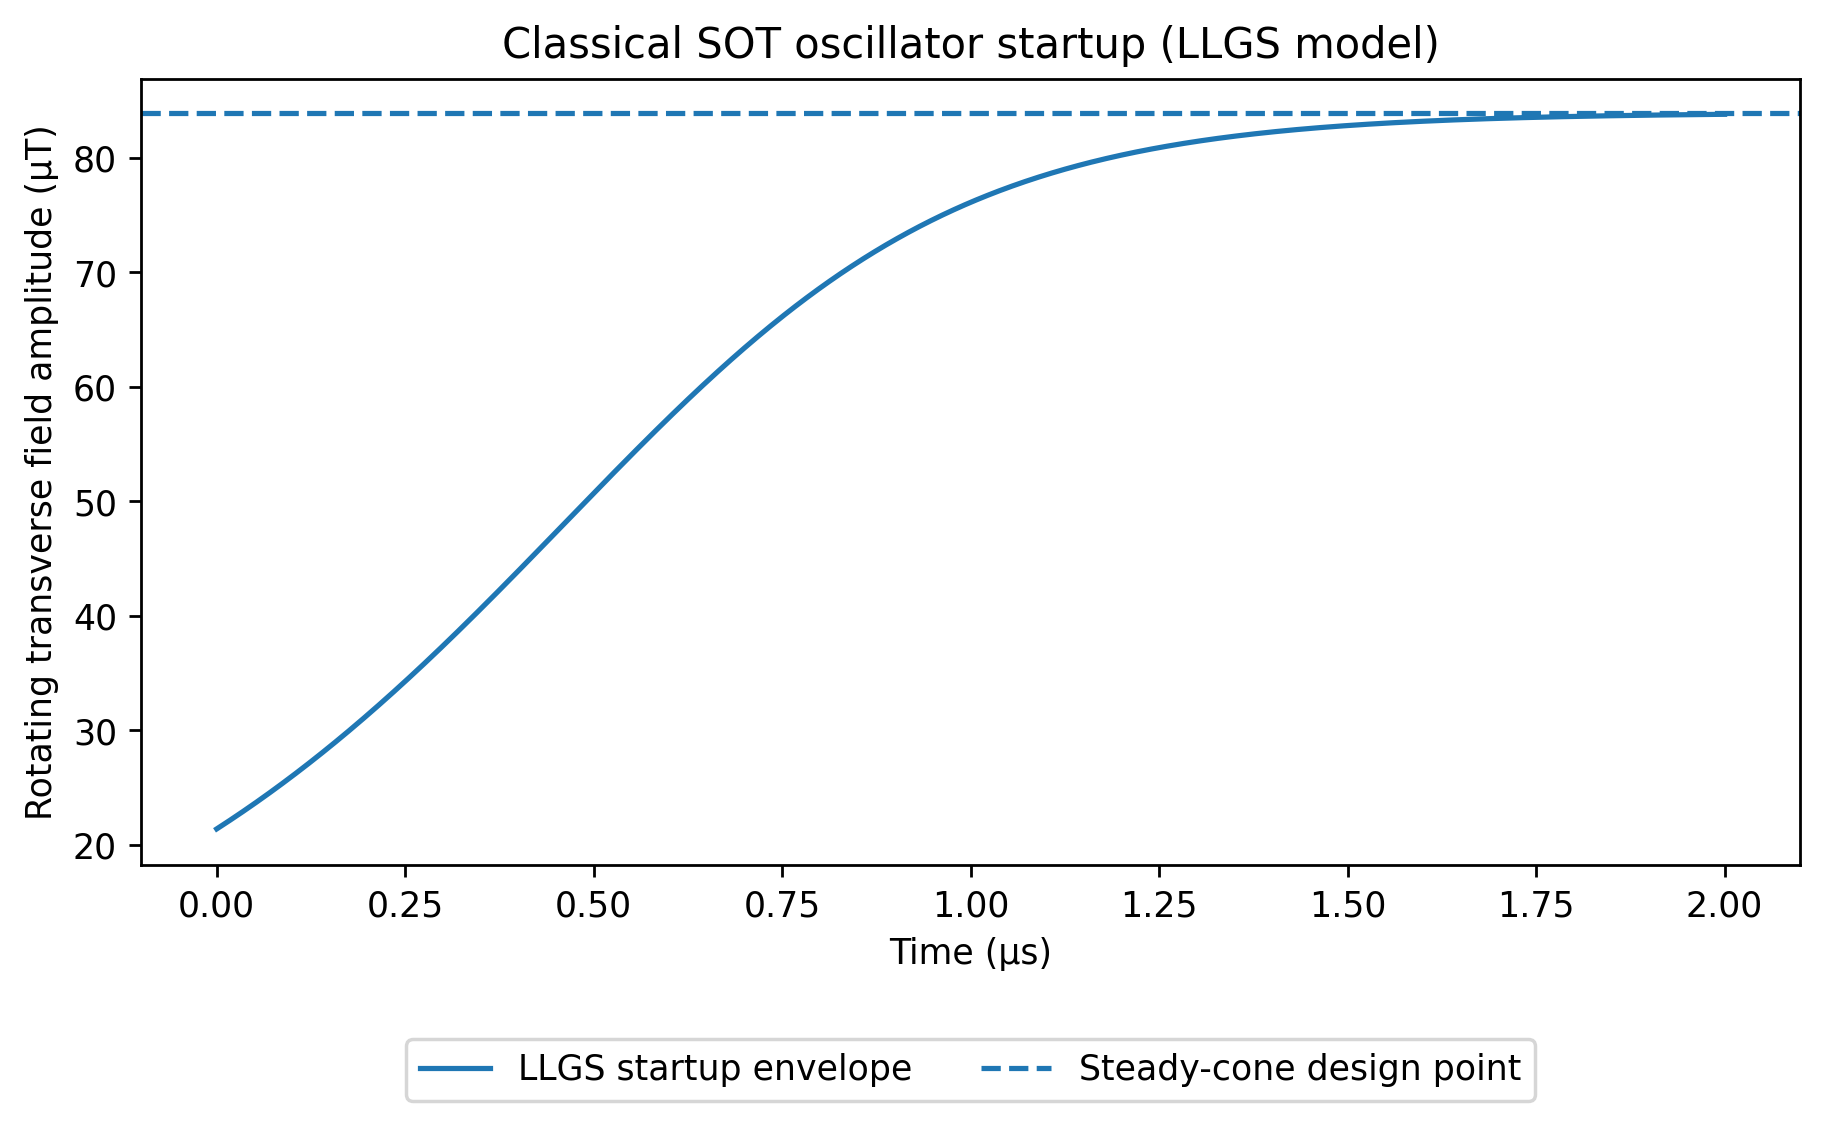

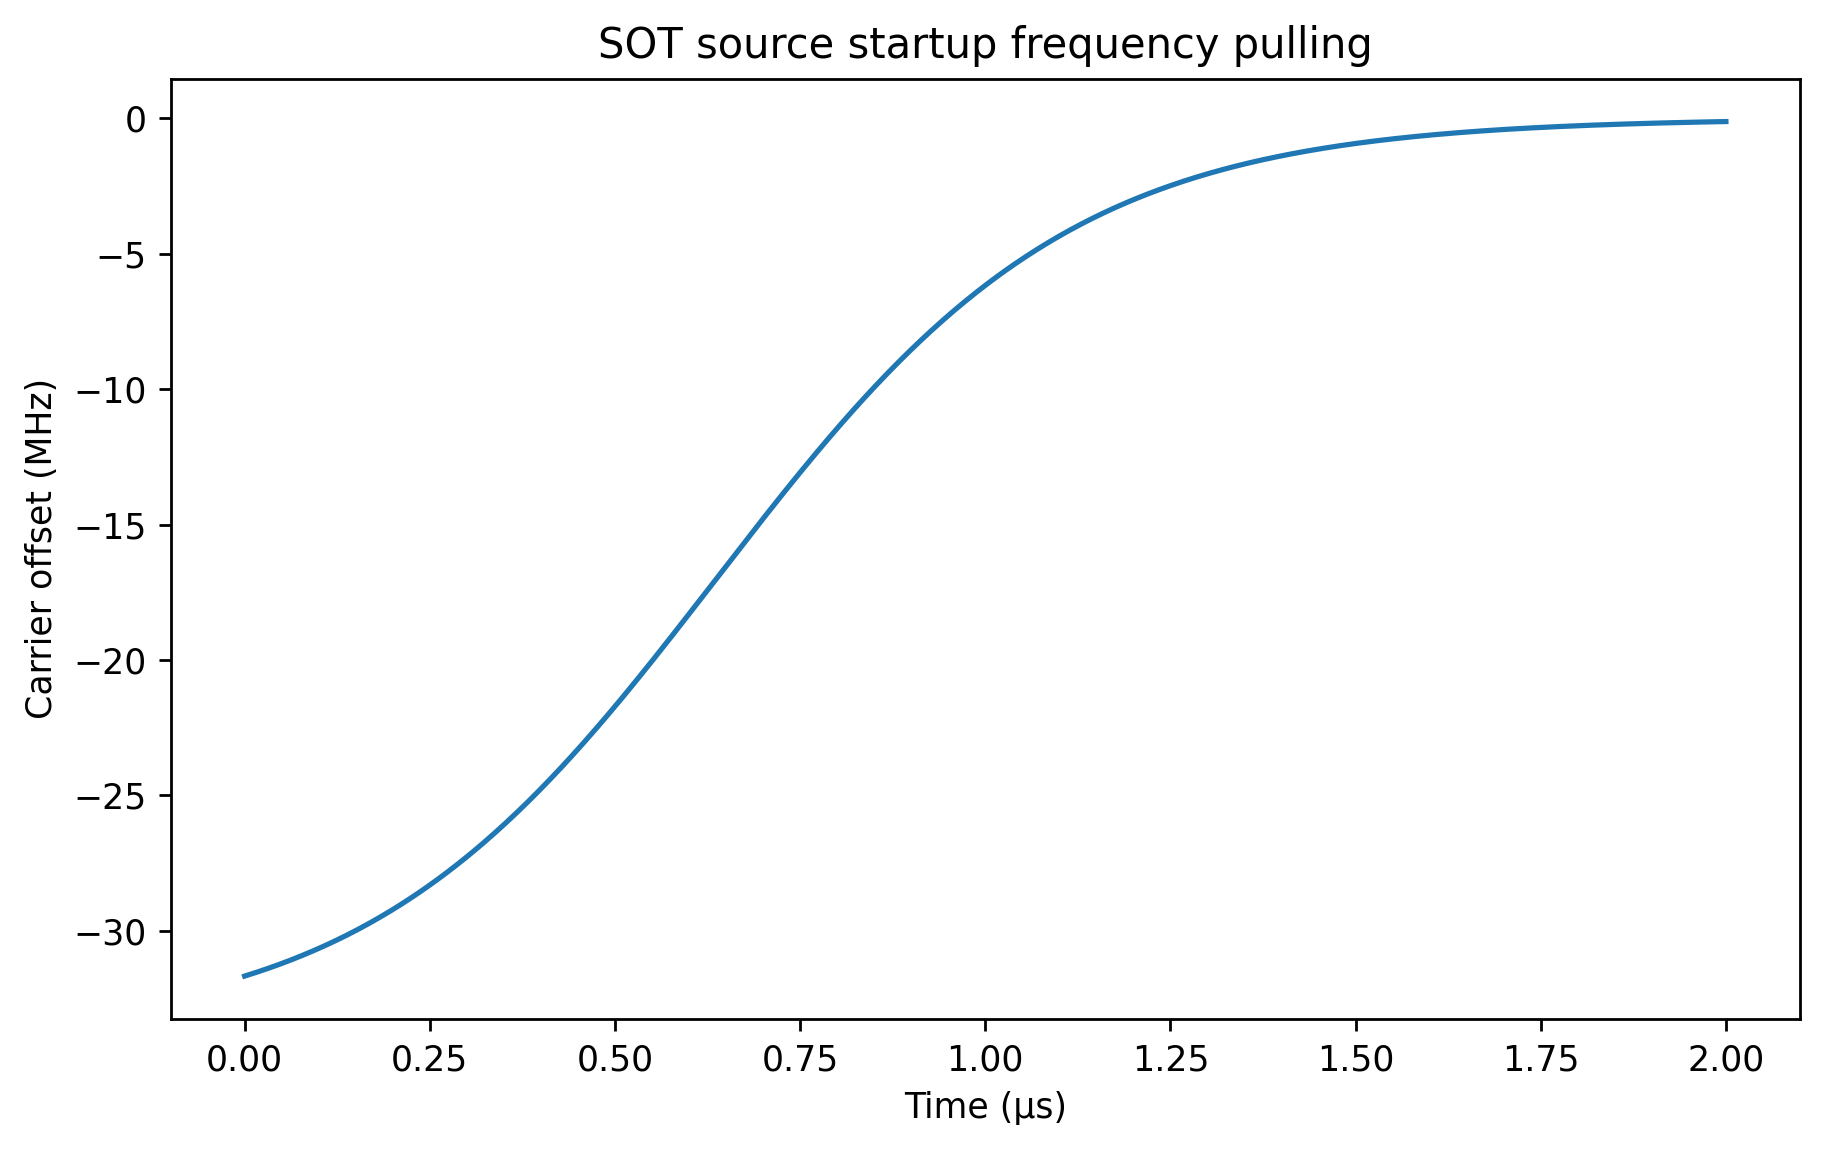

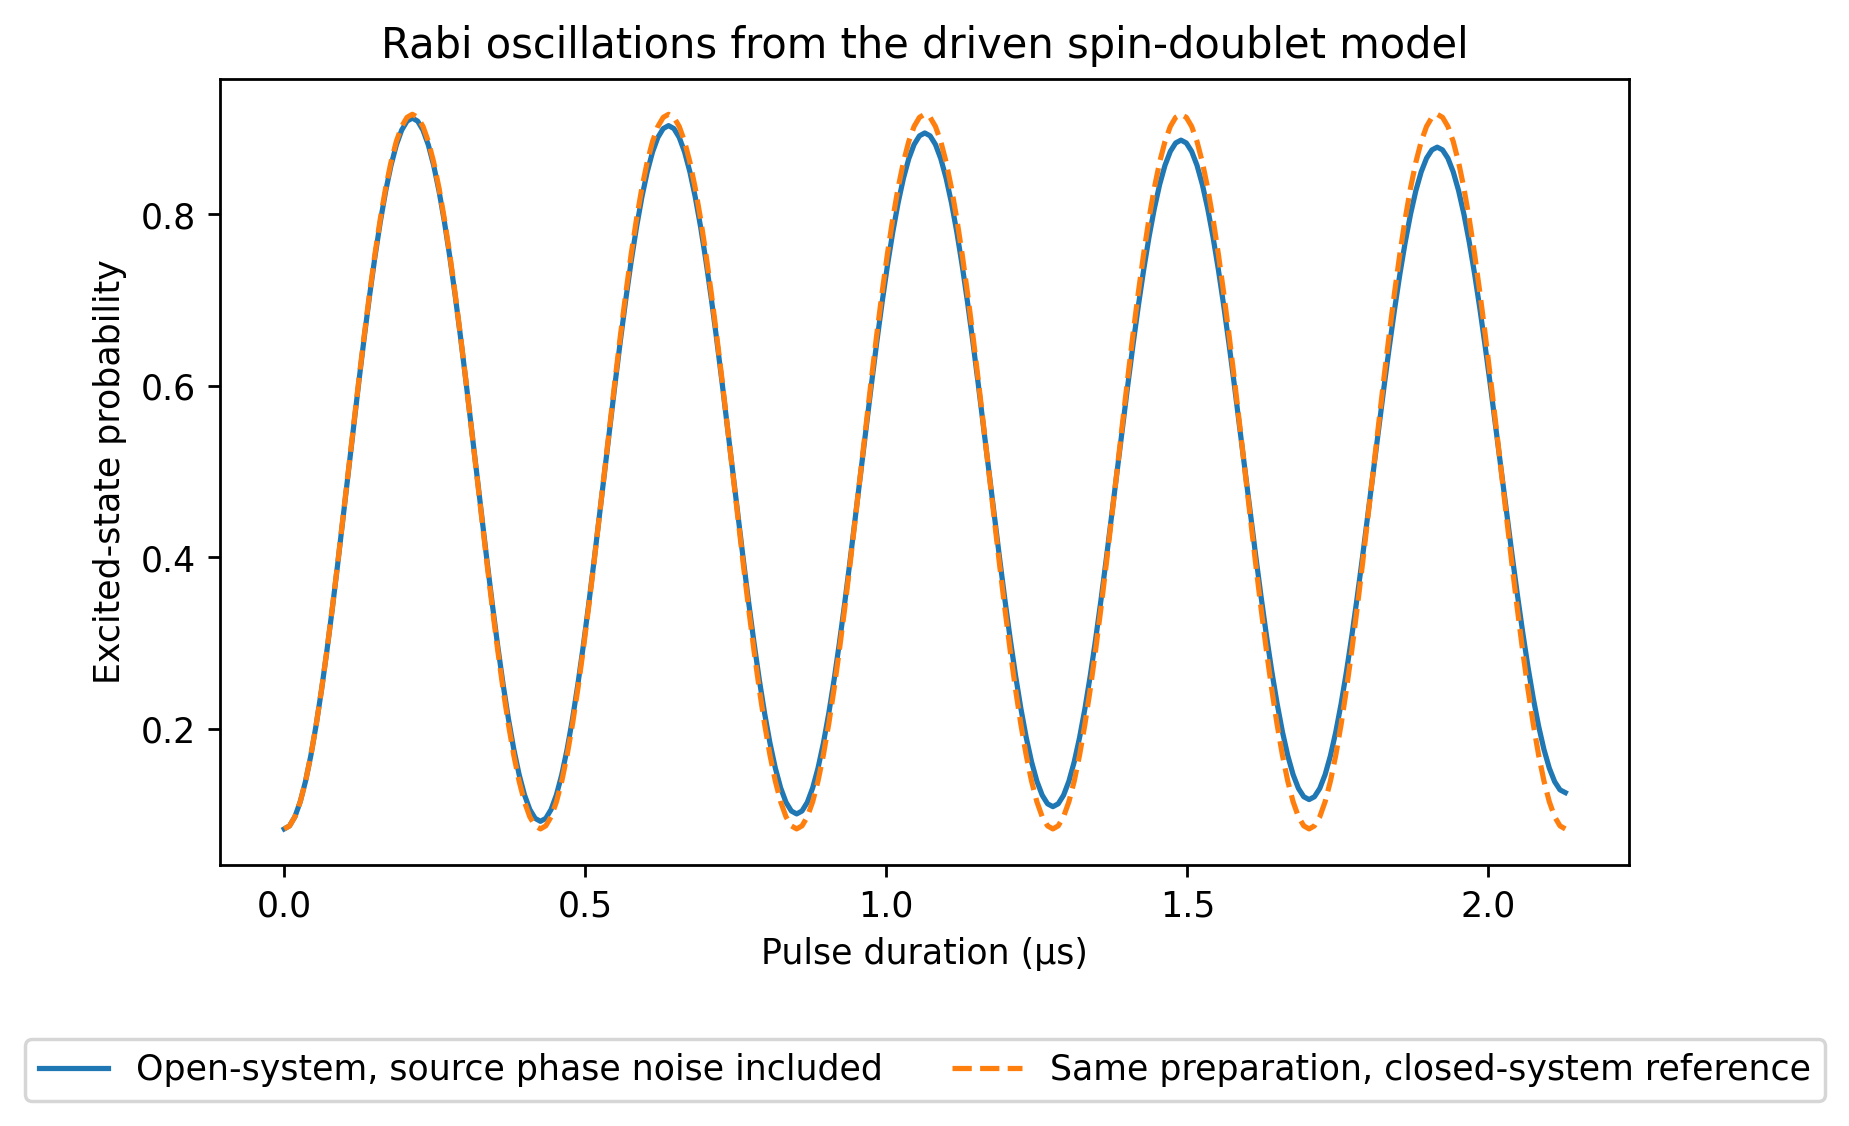

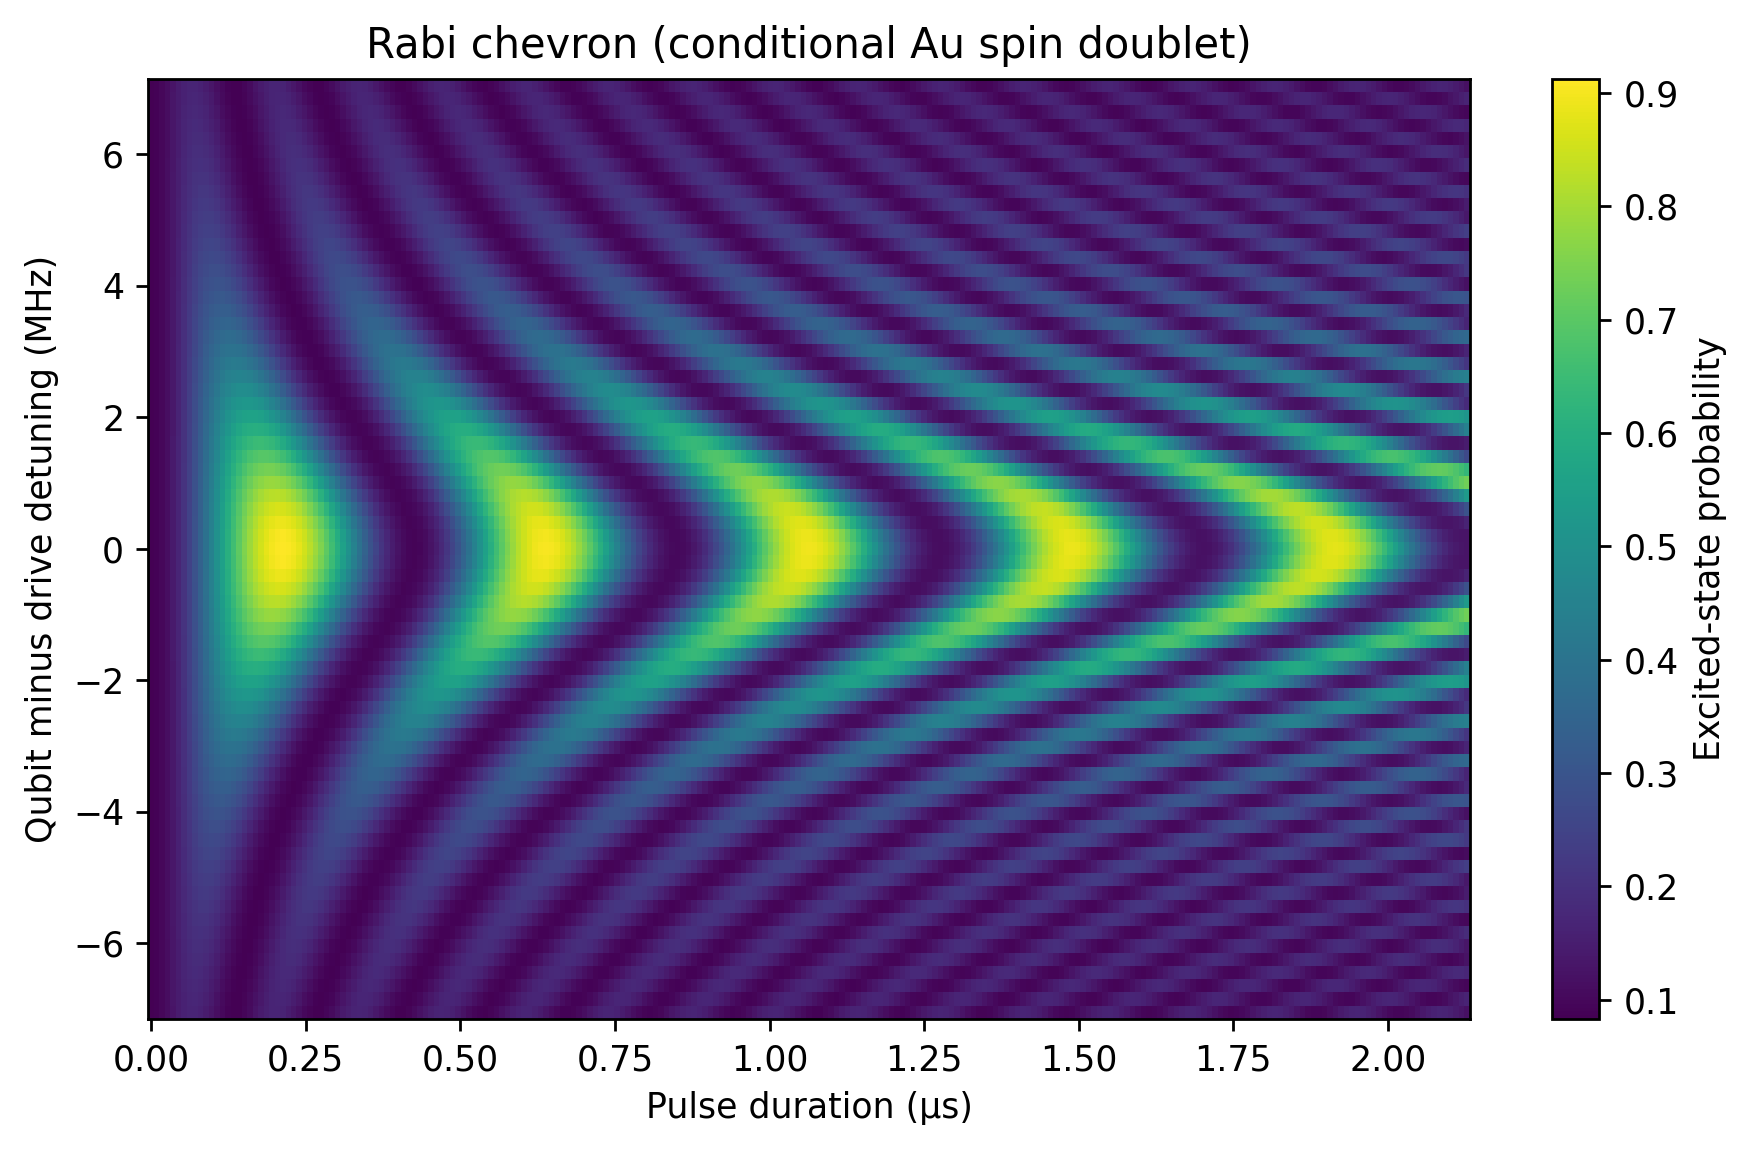

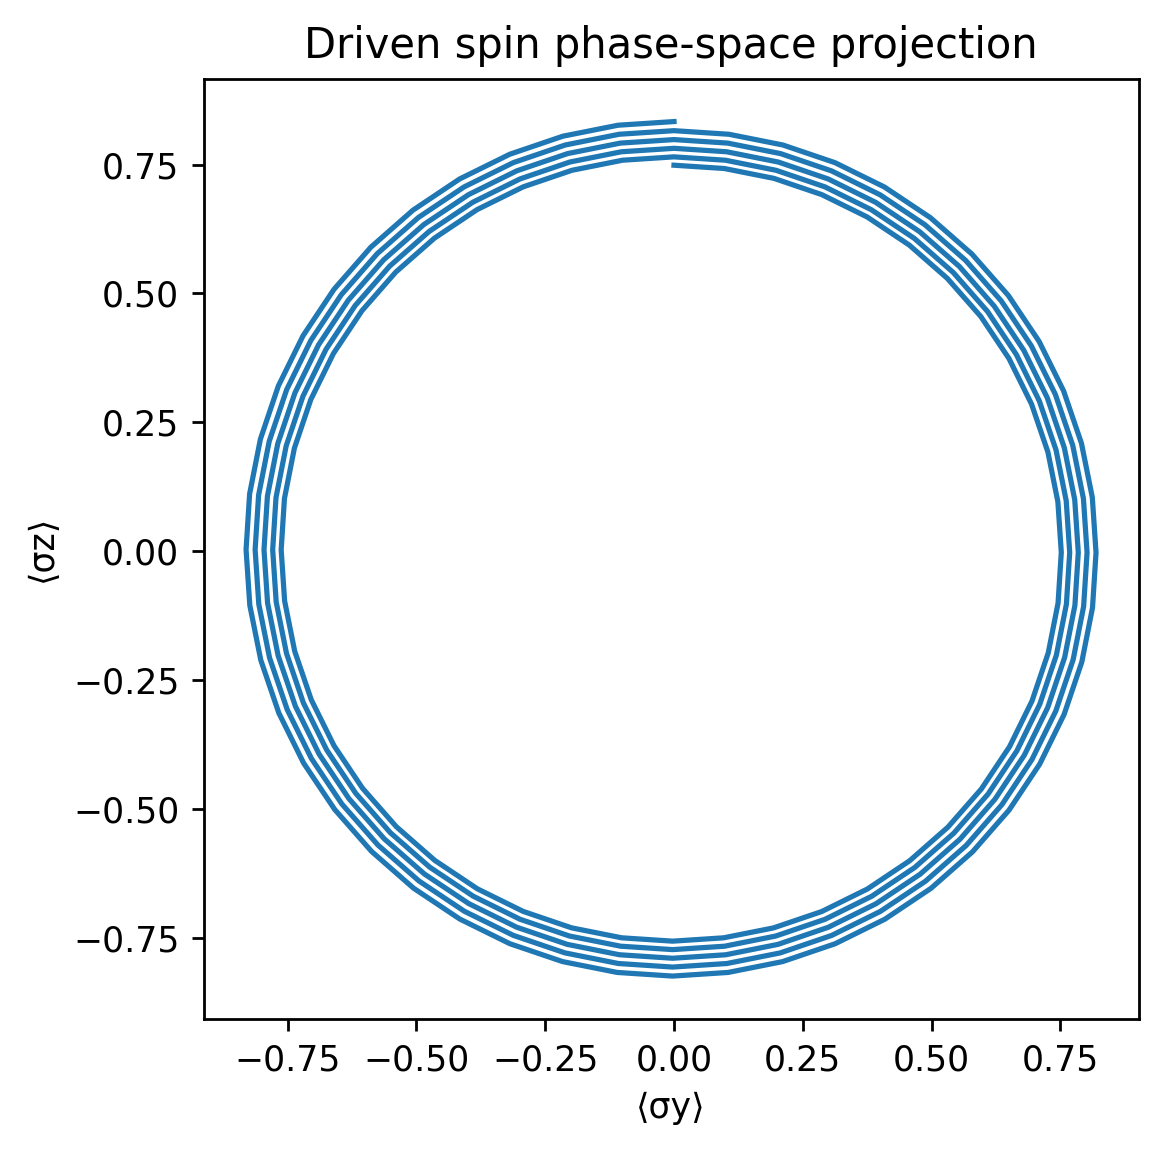

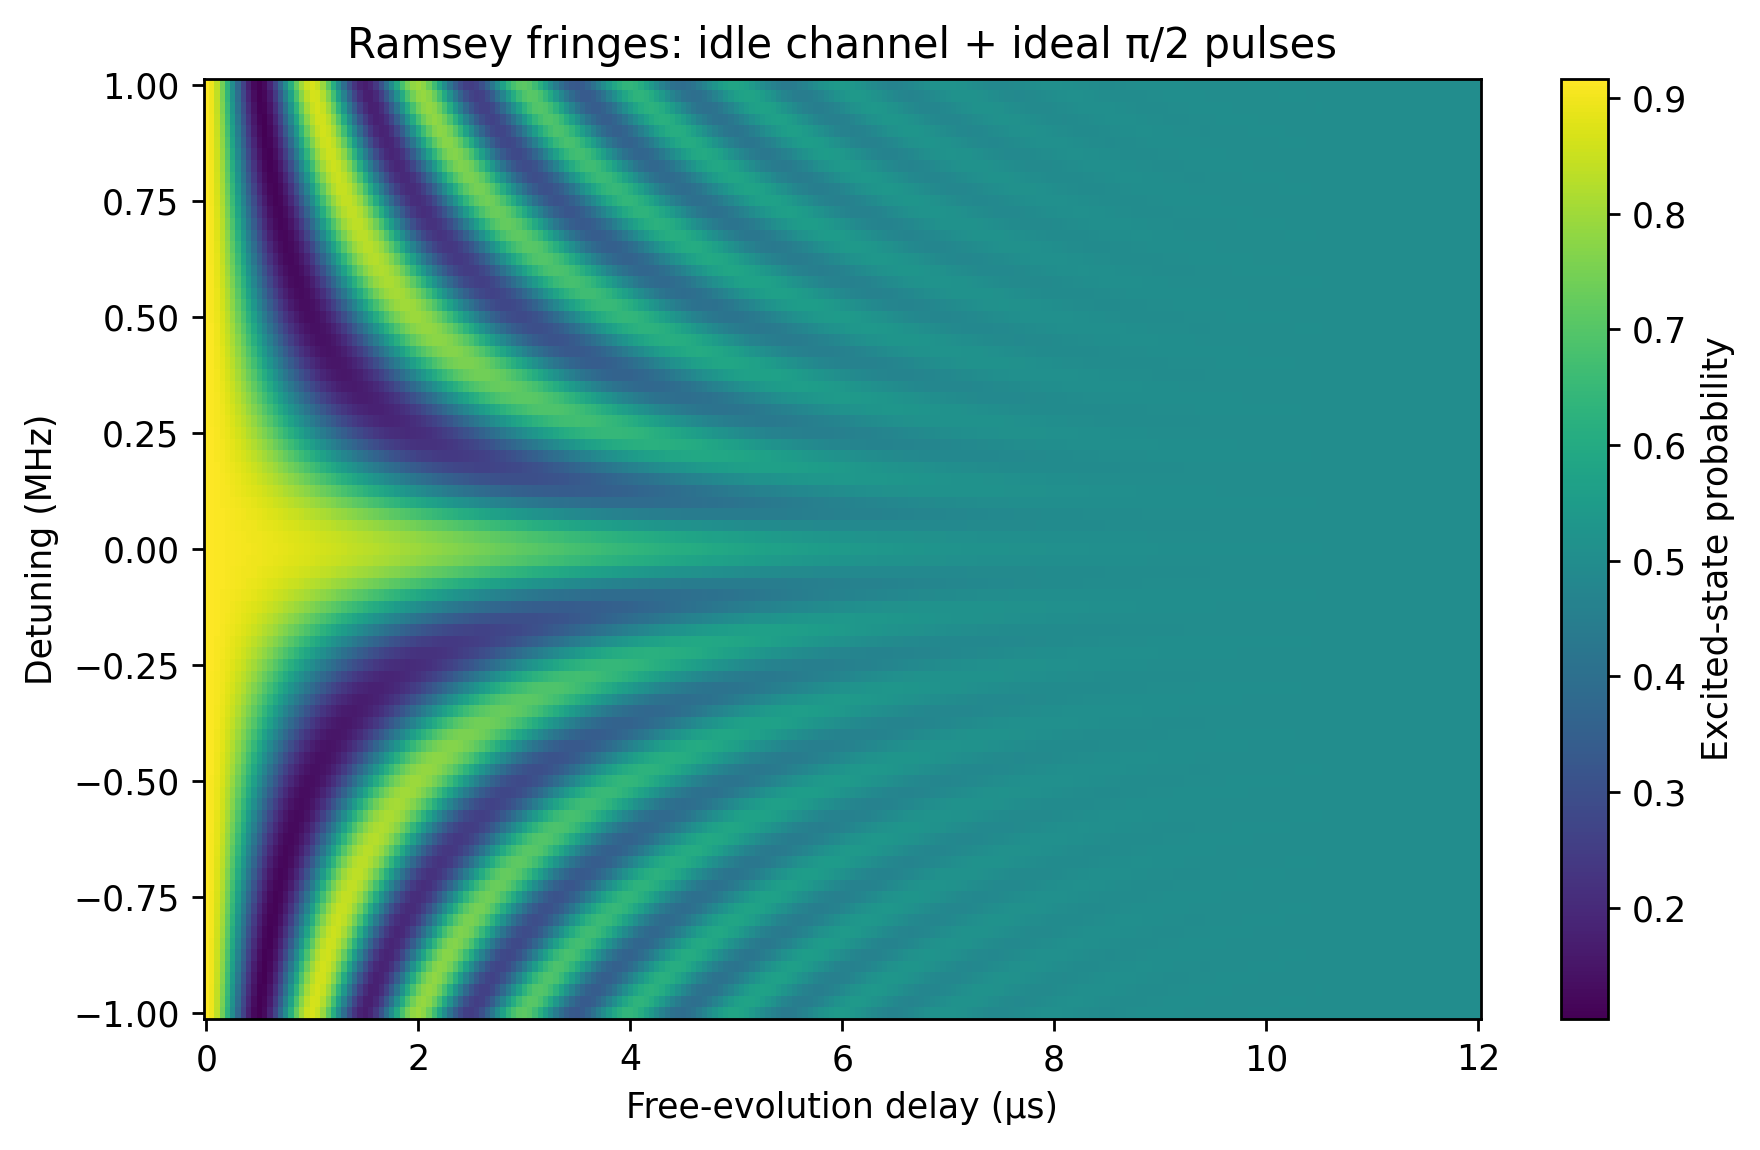

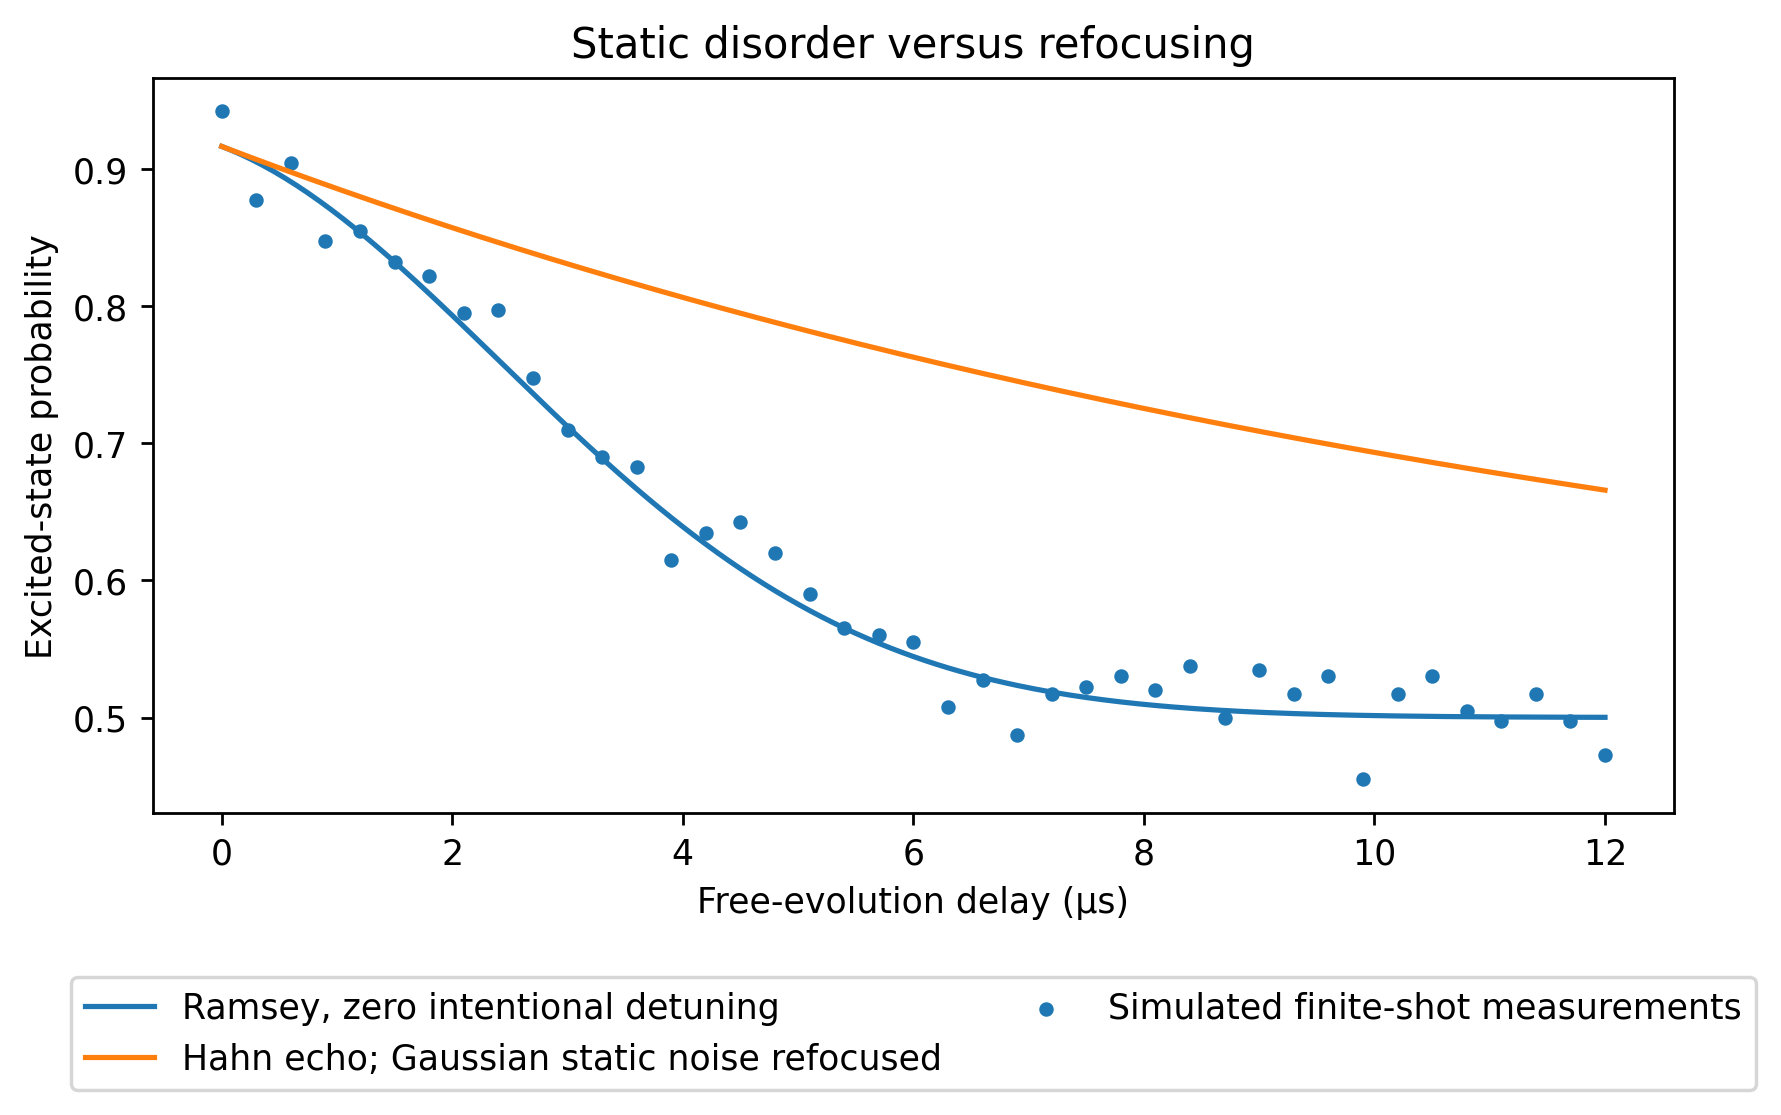

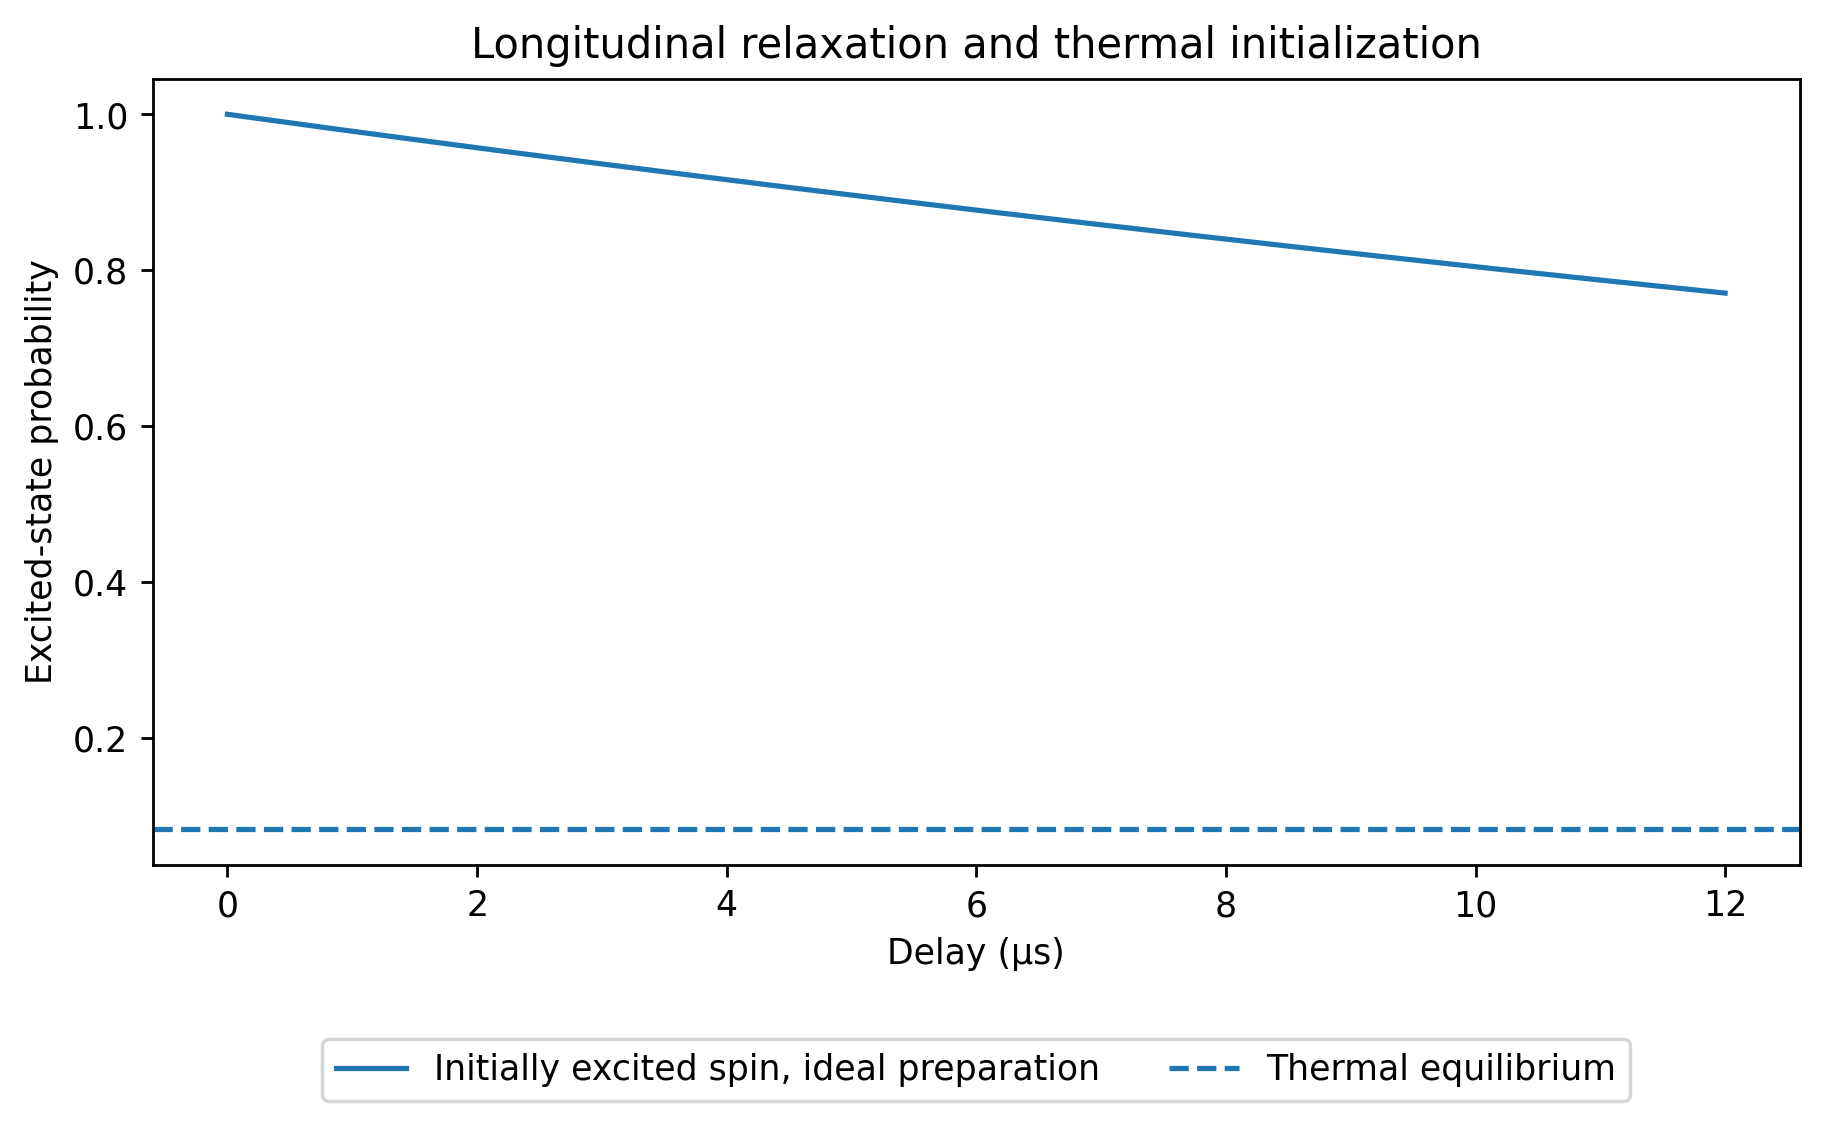

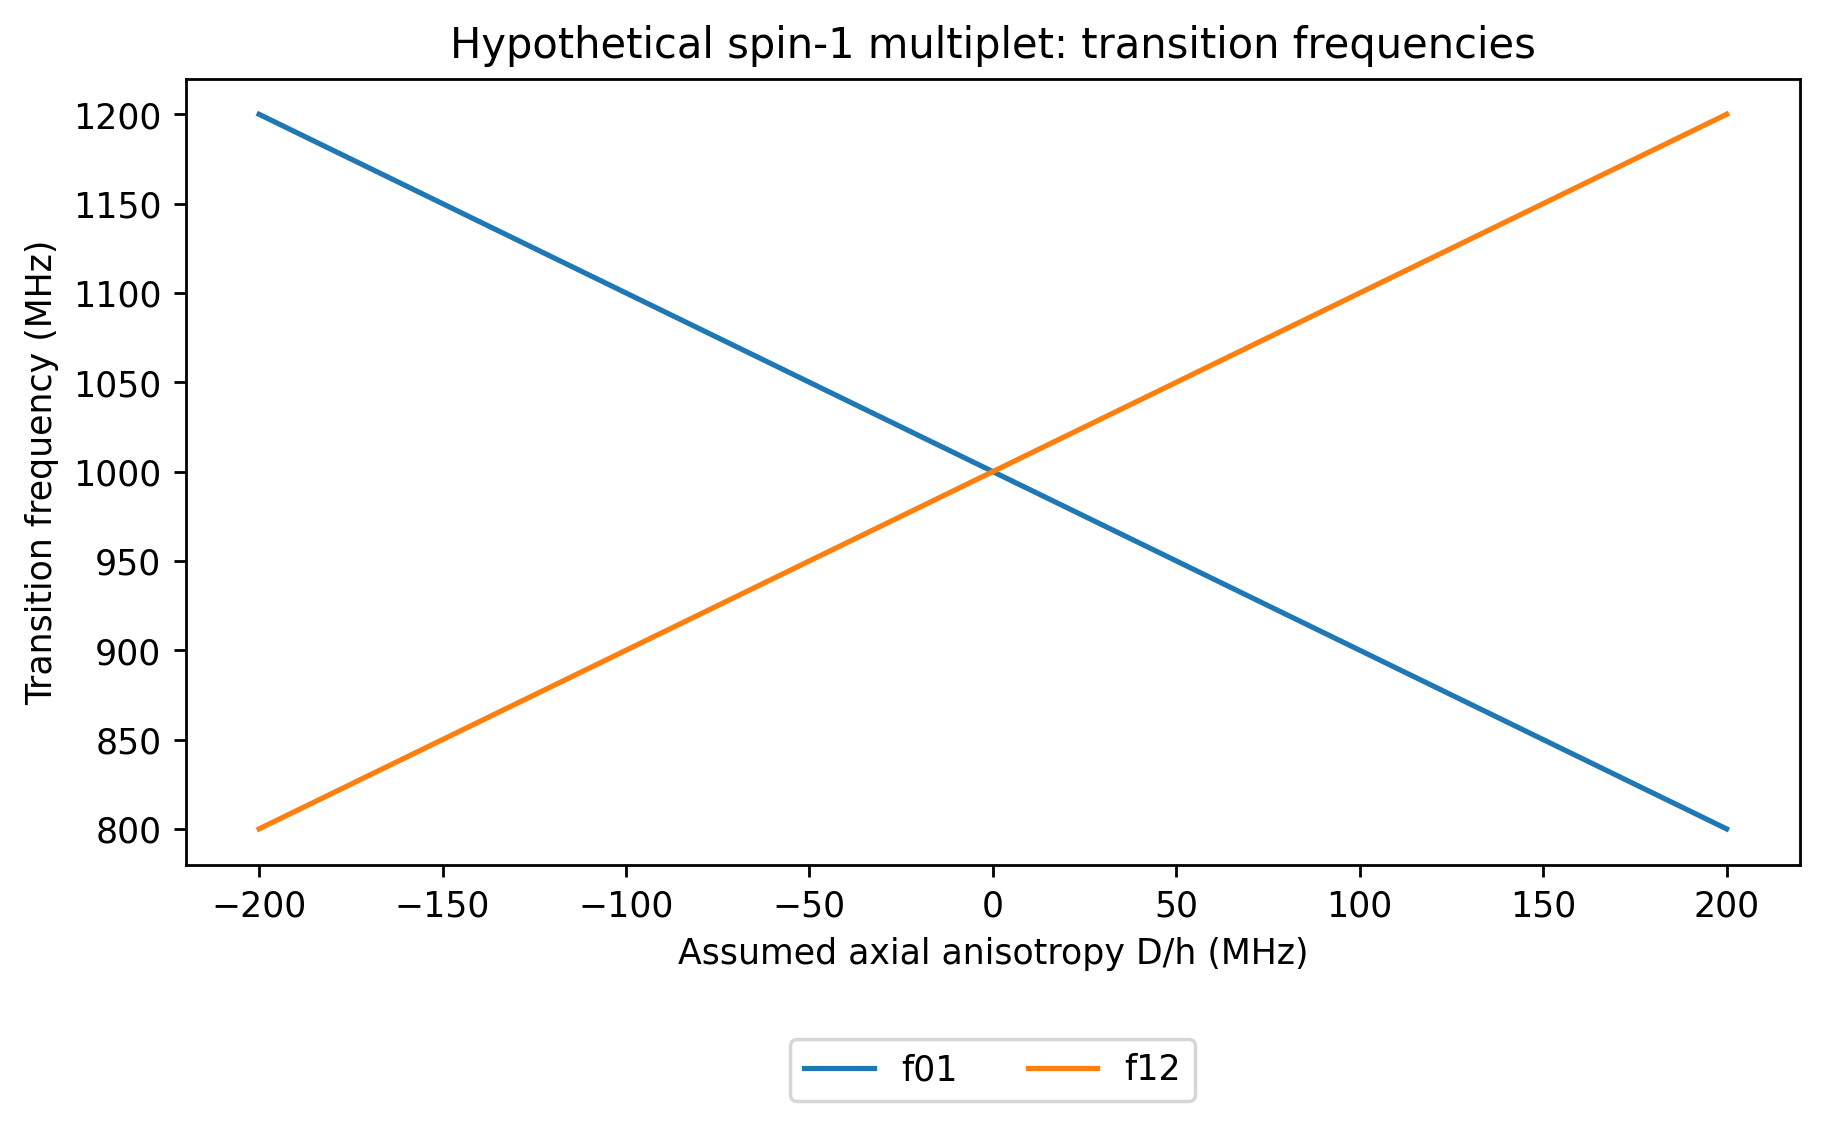

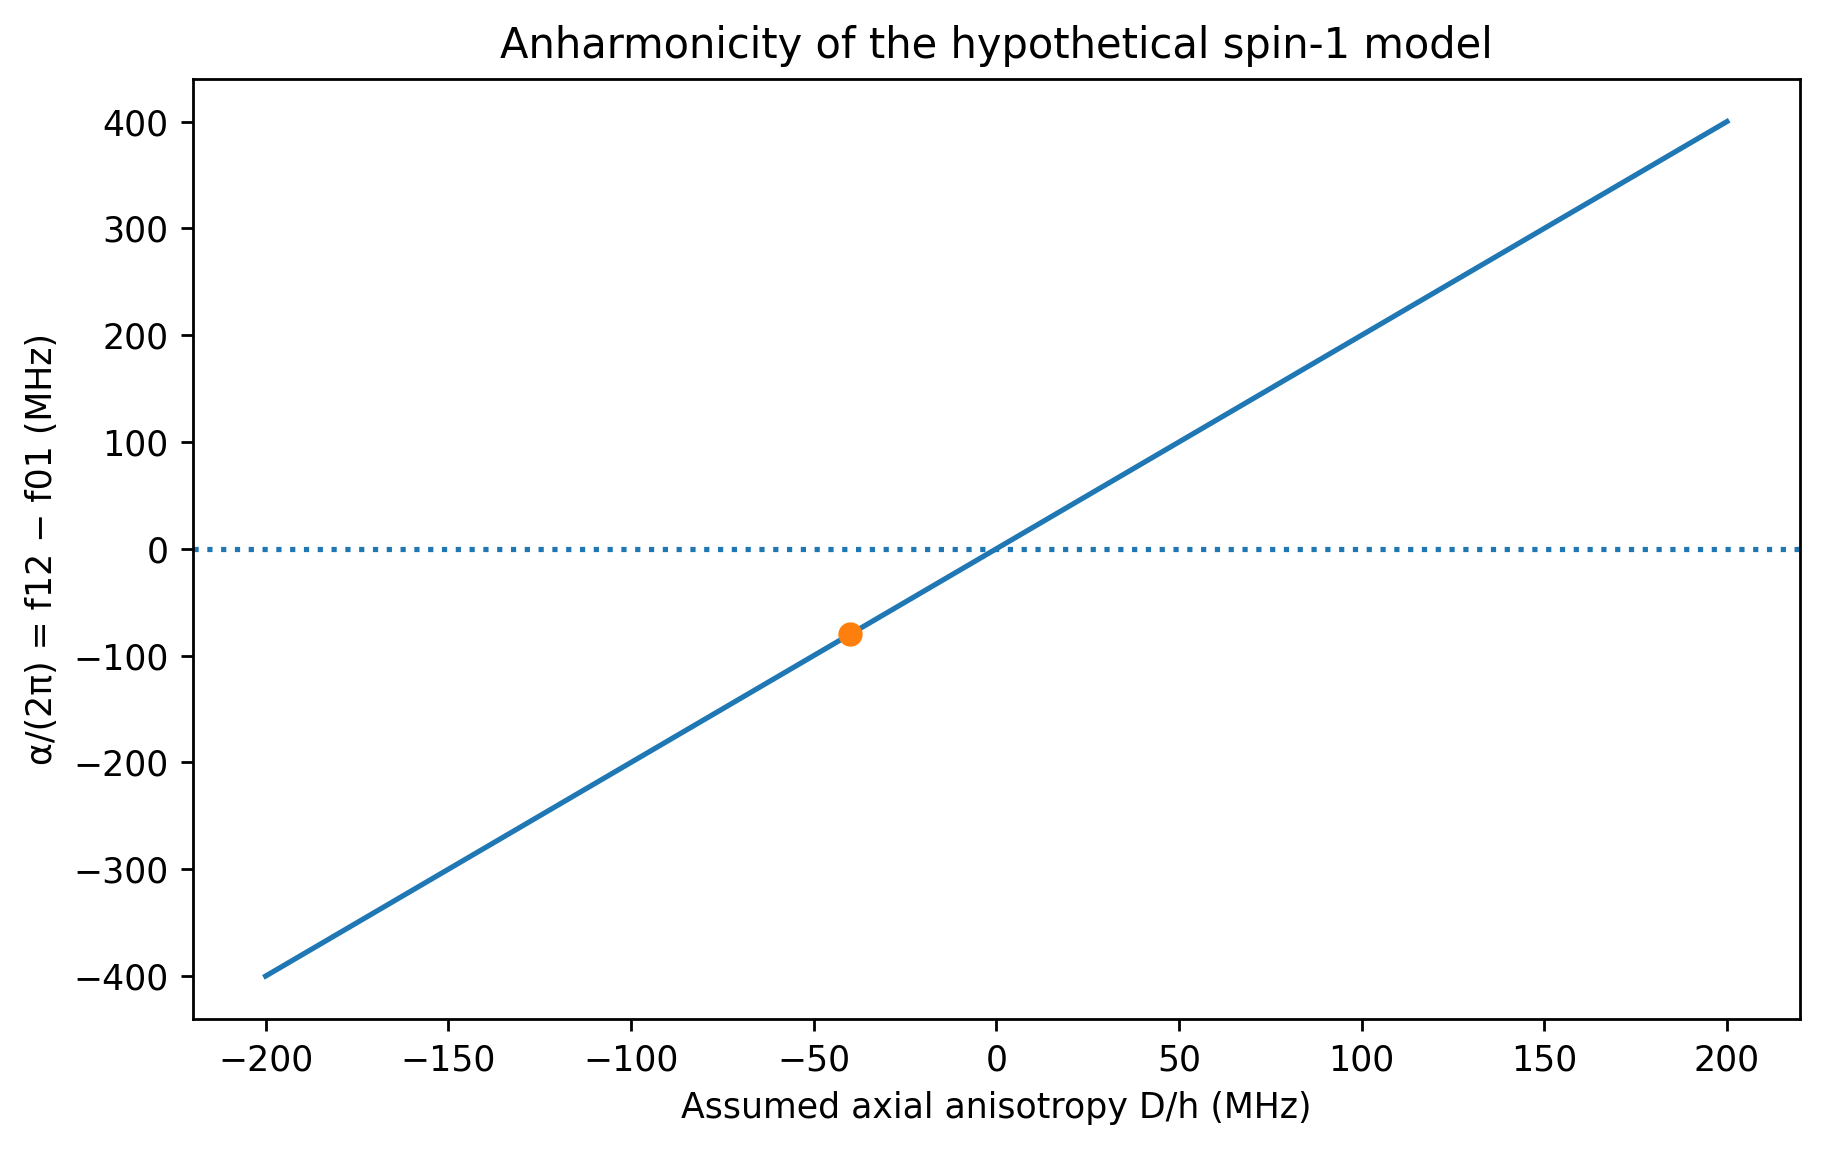

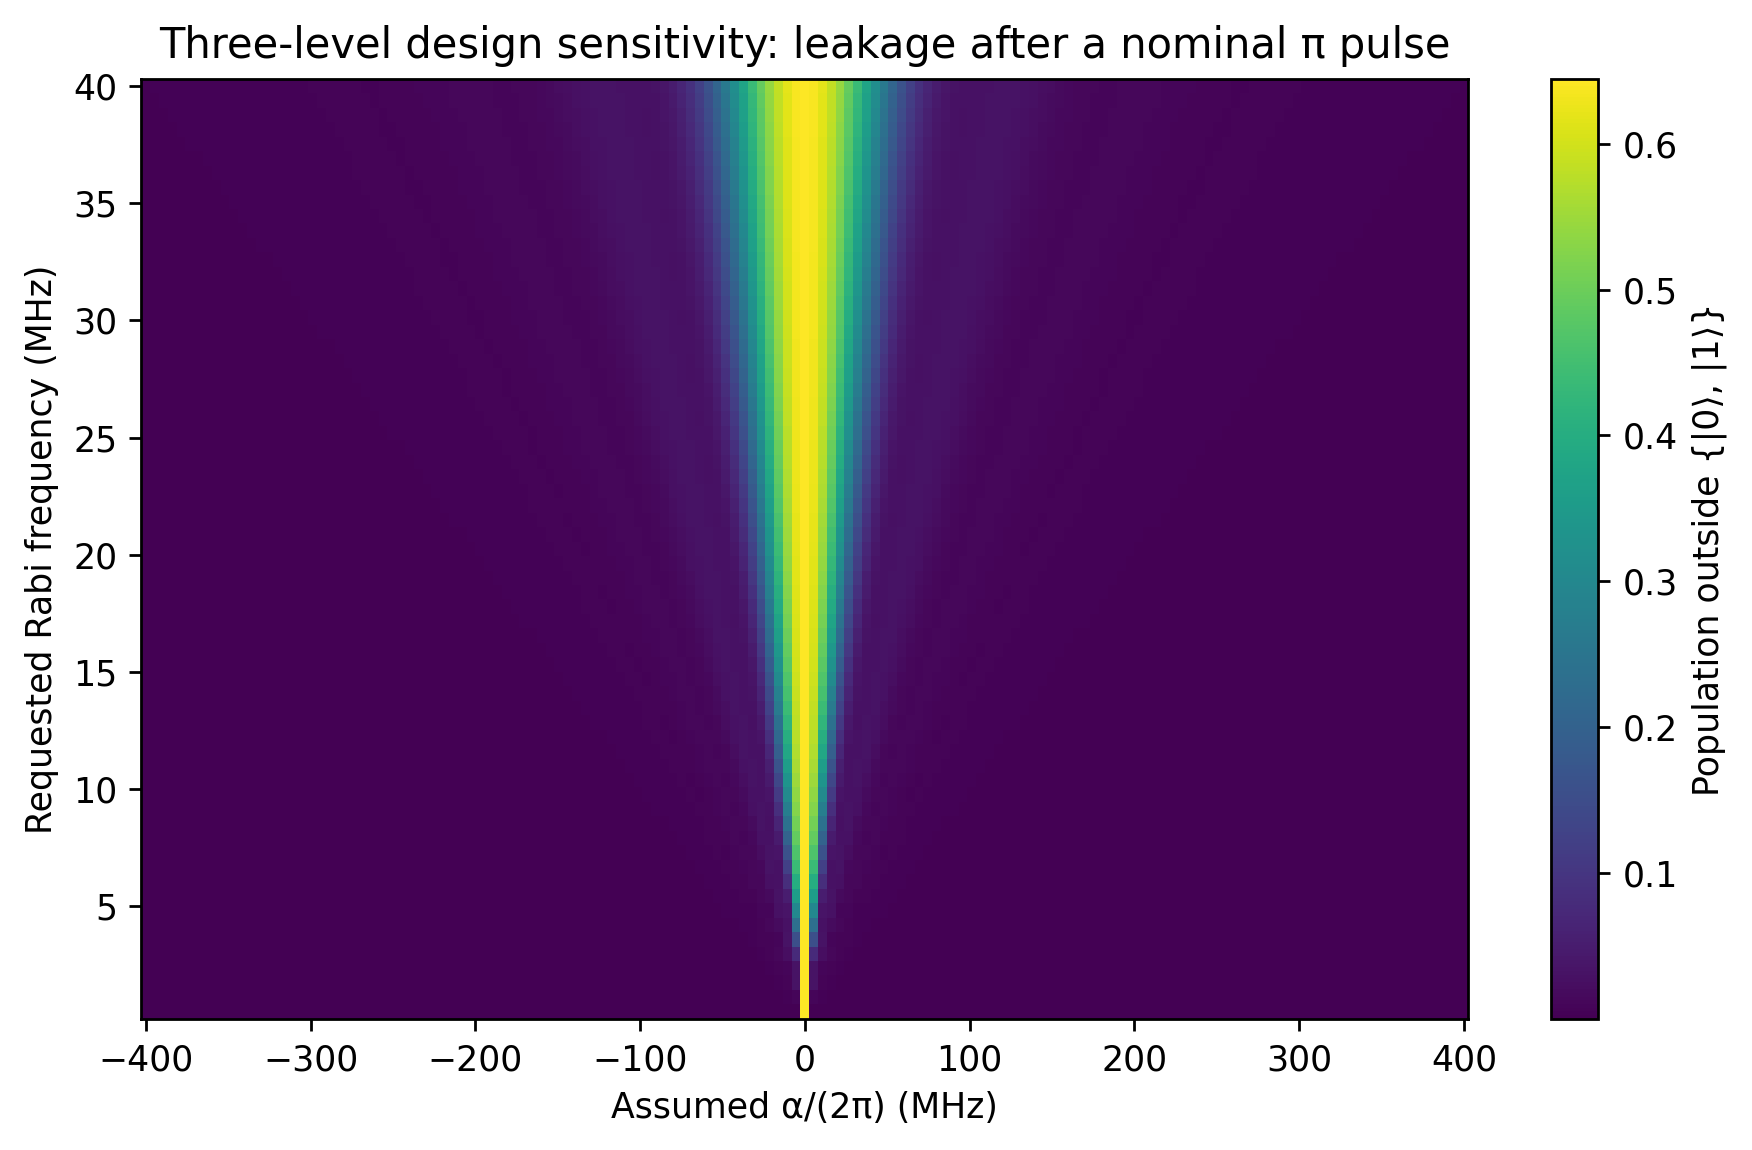

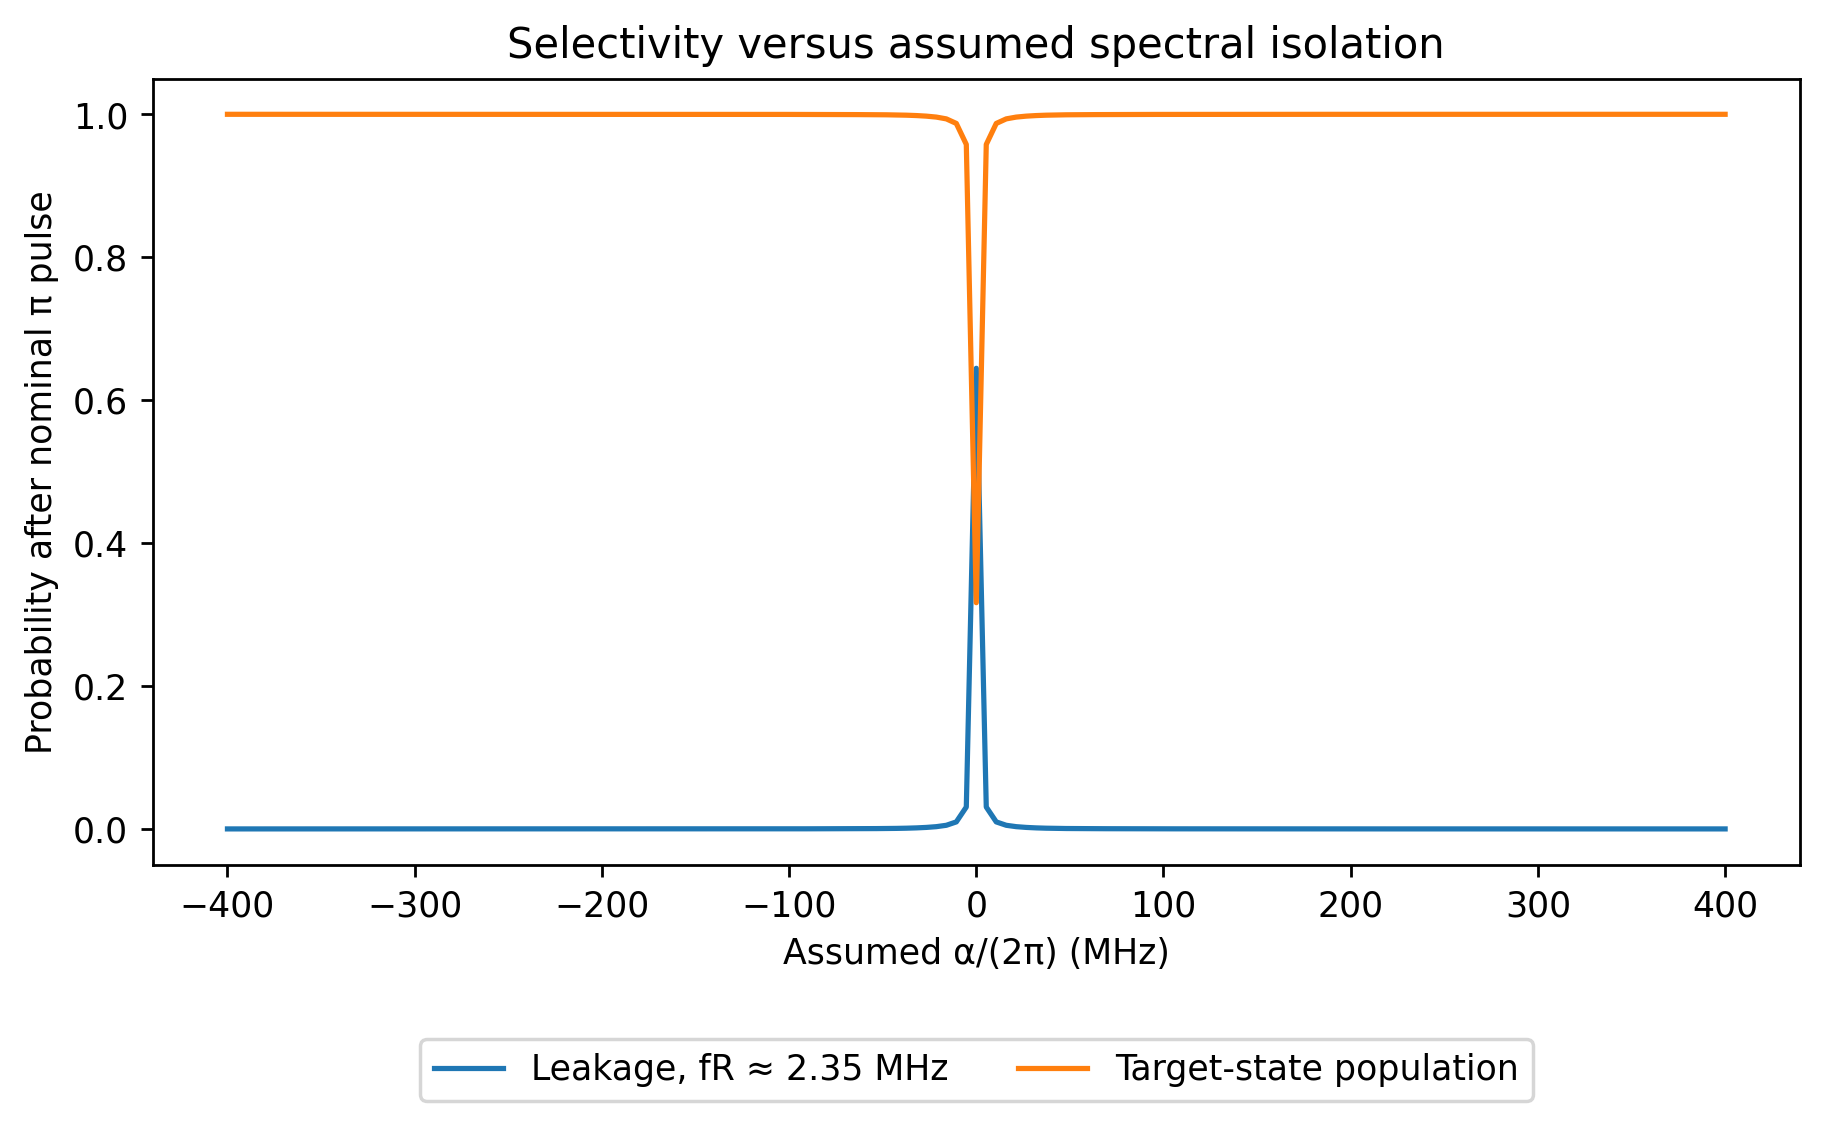

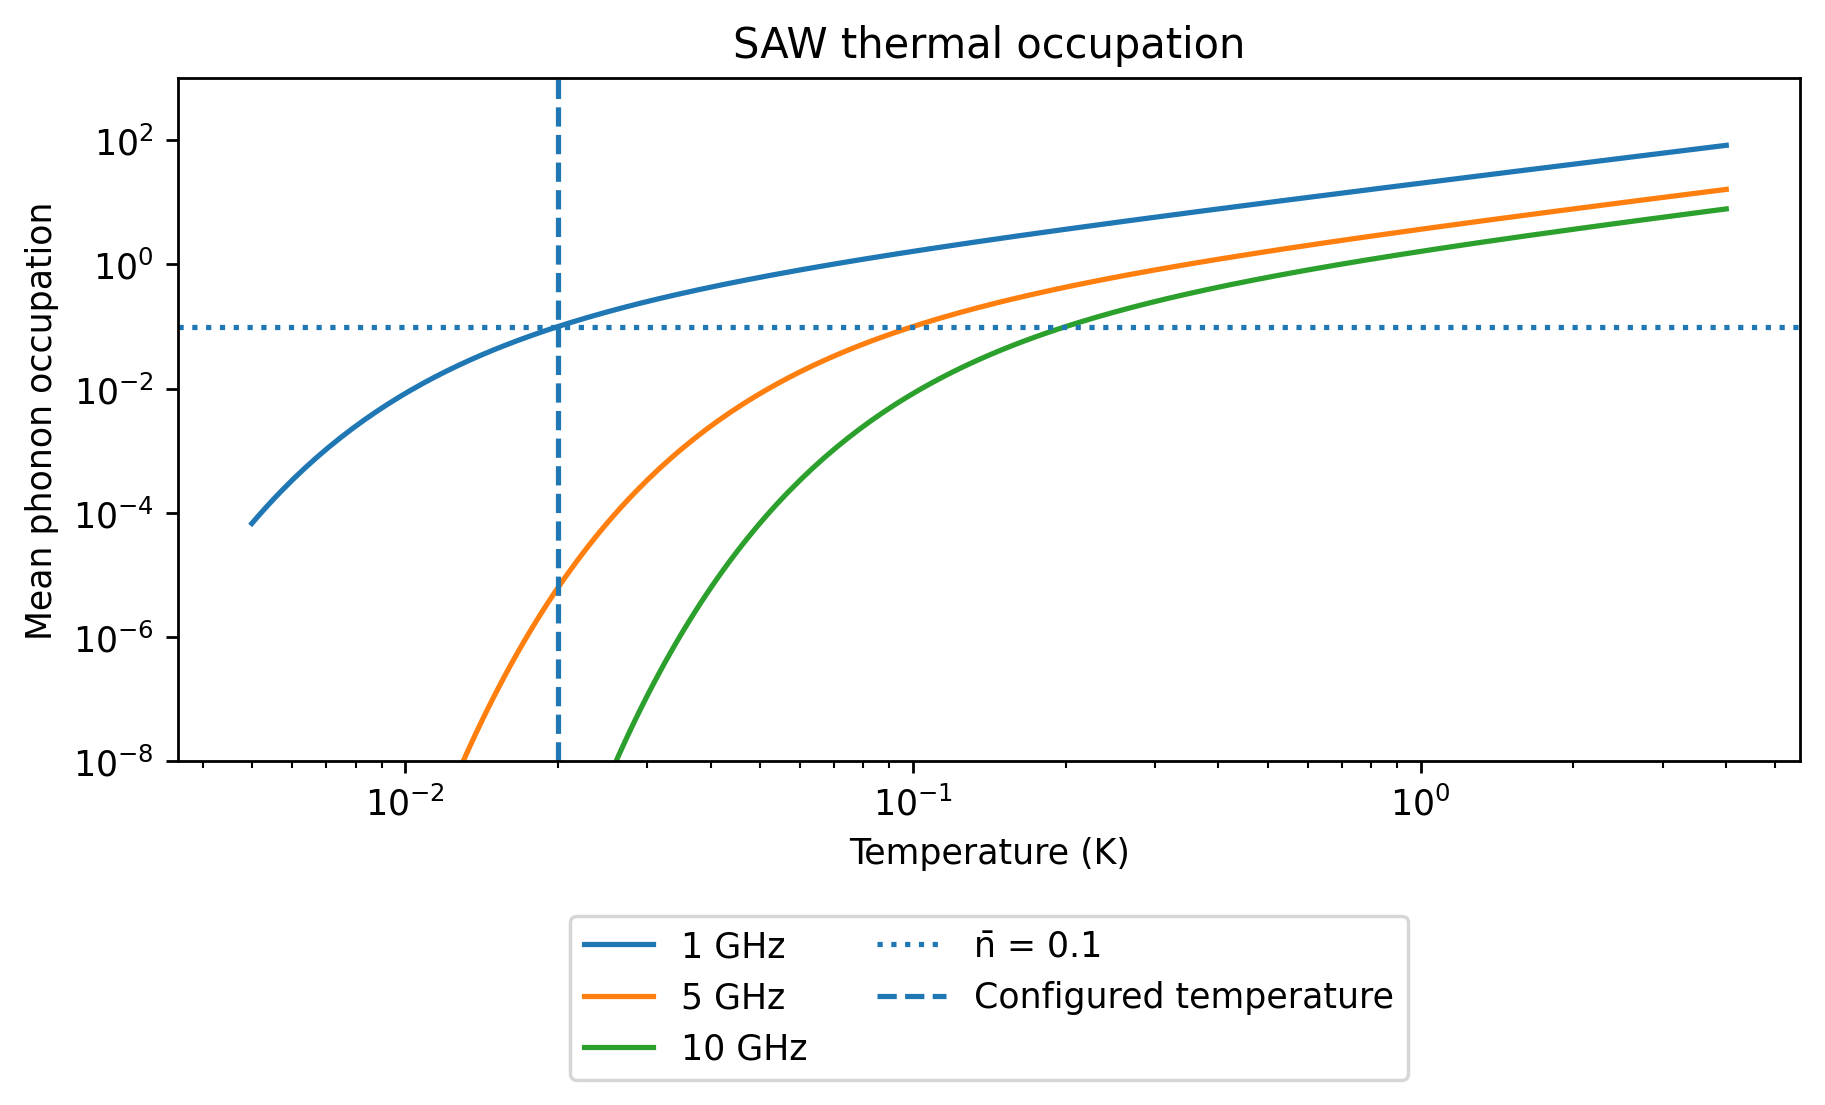

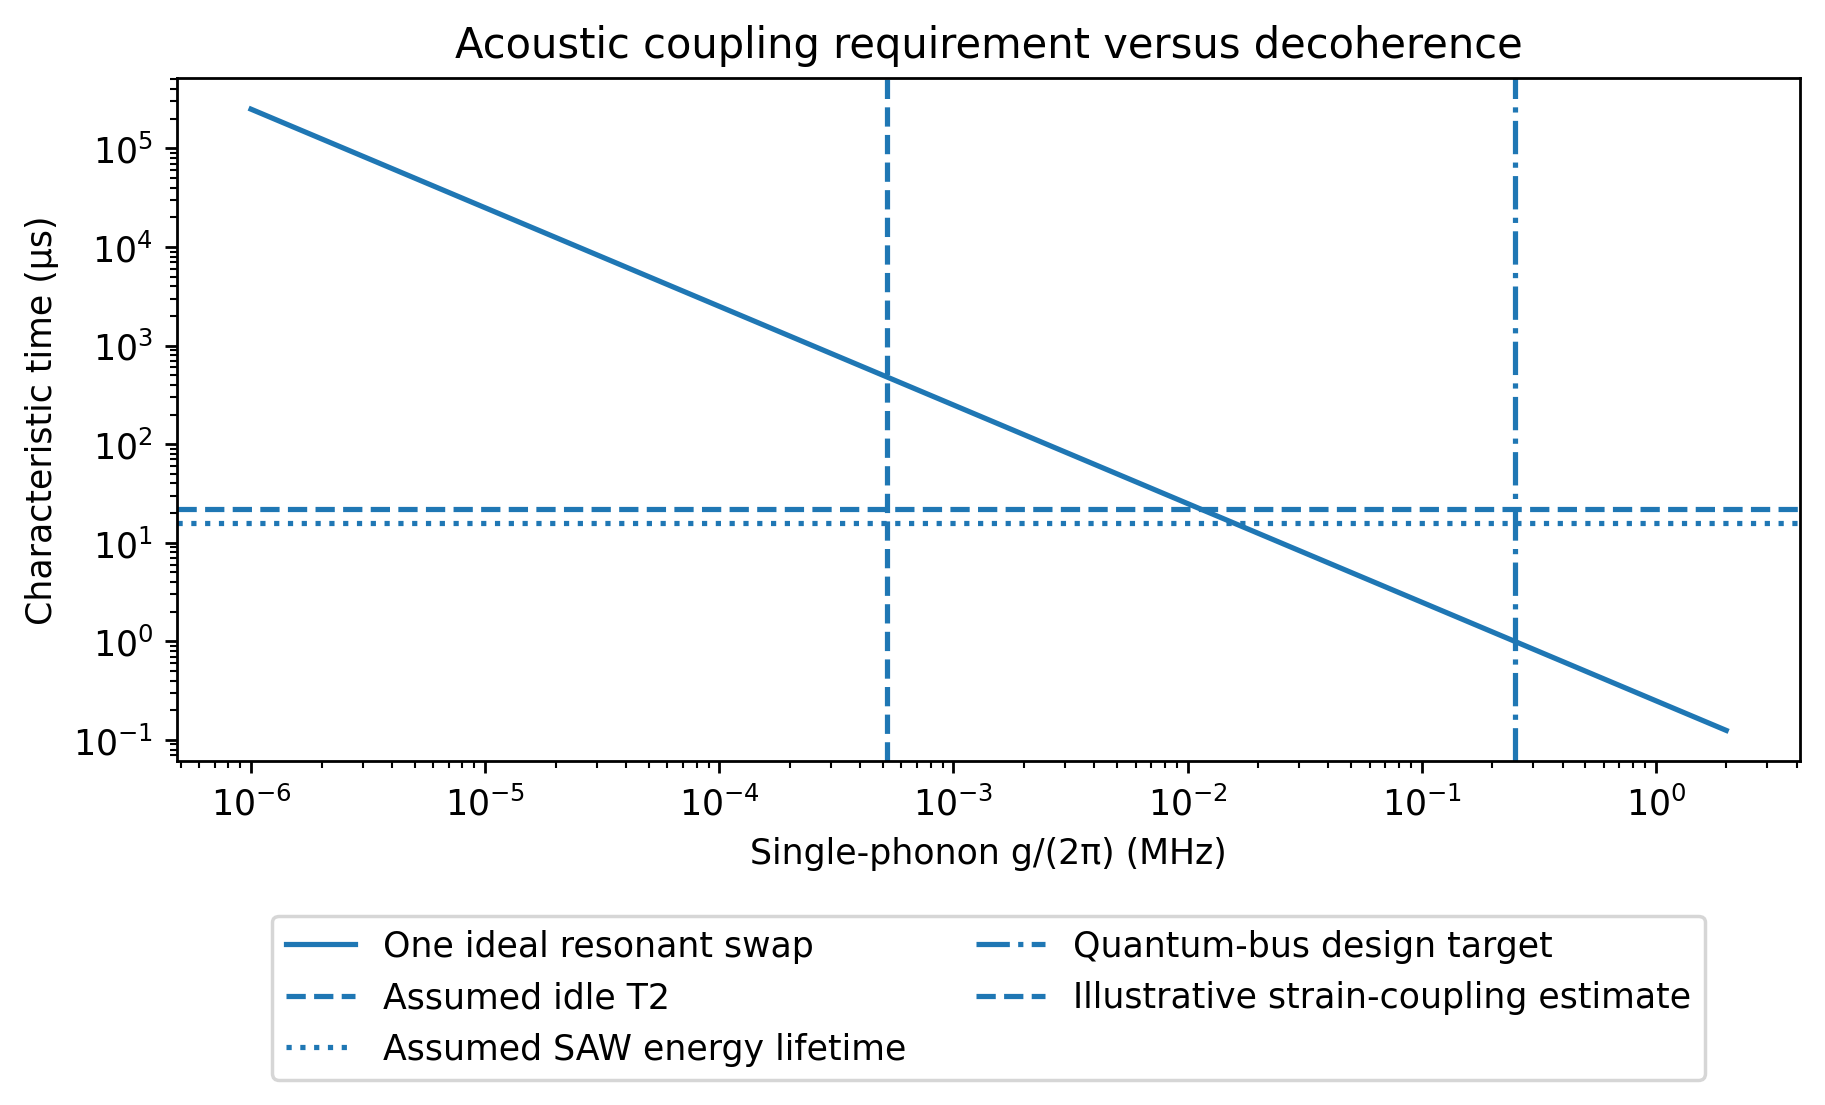

Bus Hilbert dimensions (2, 2, 9); hybrid representation = tensor.


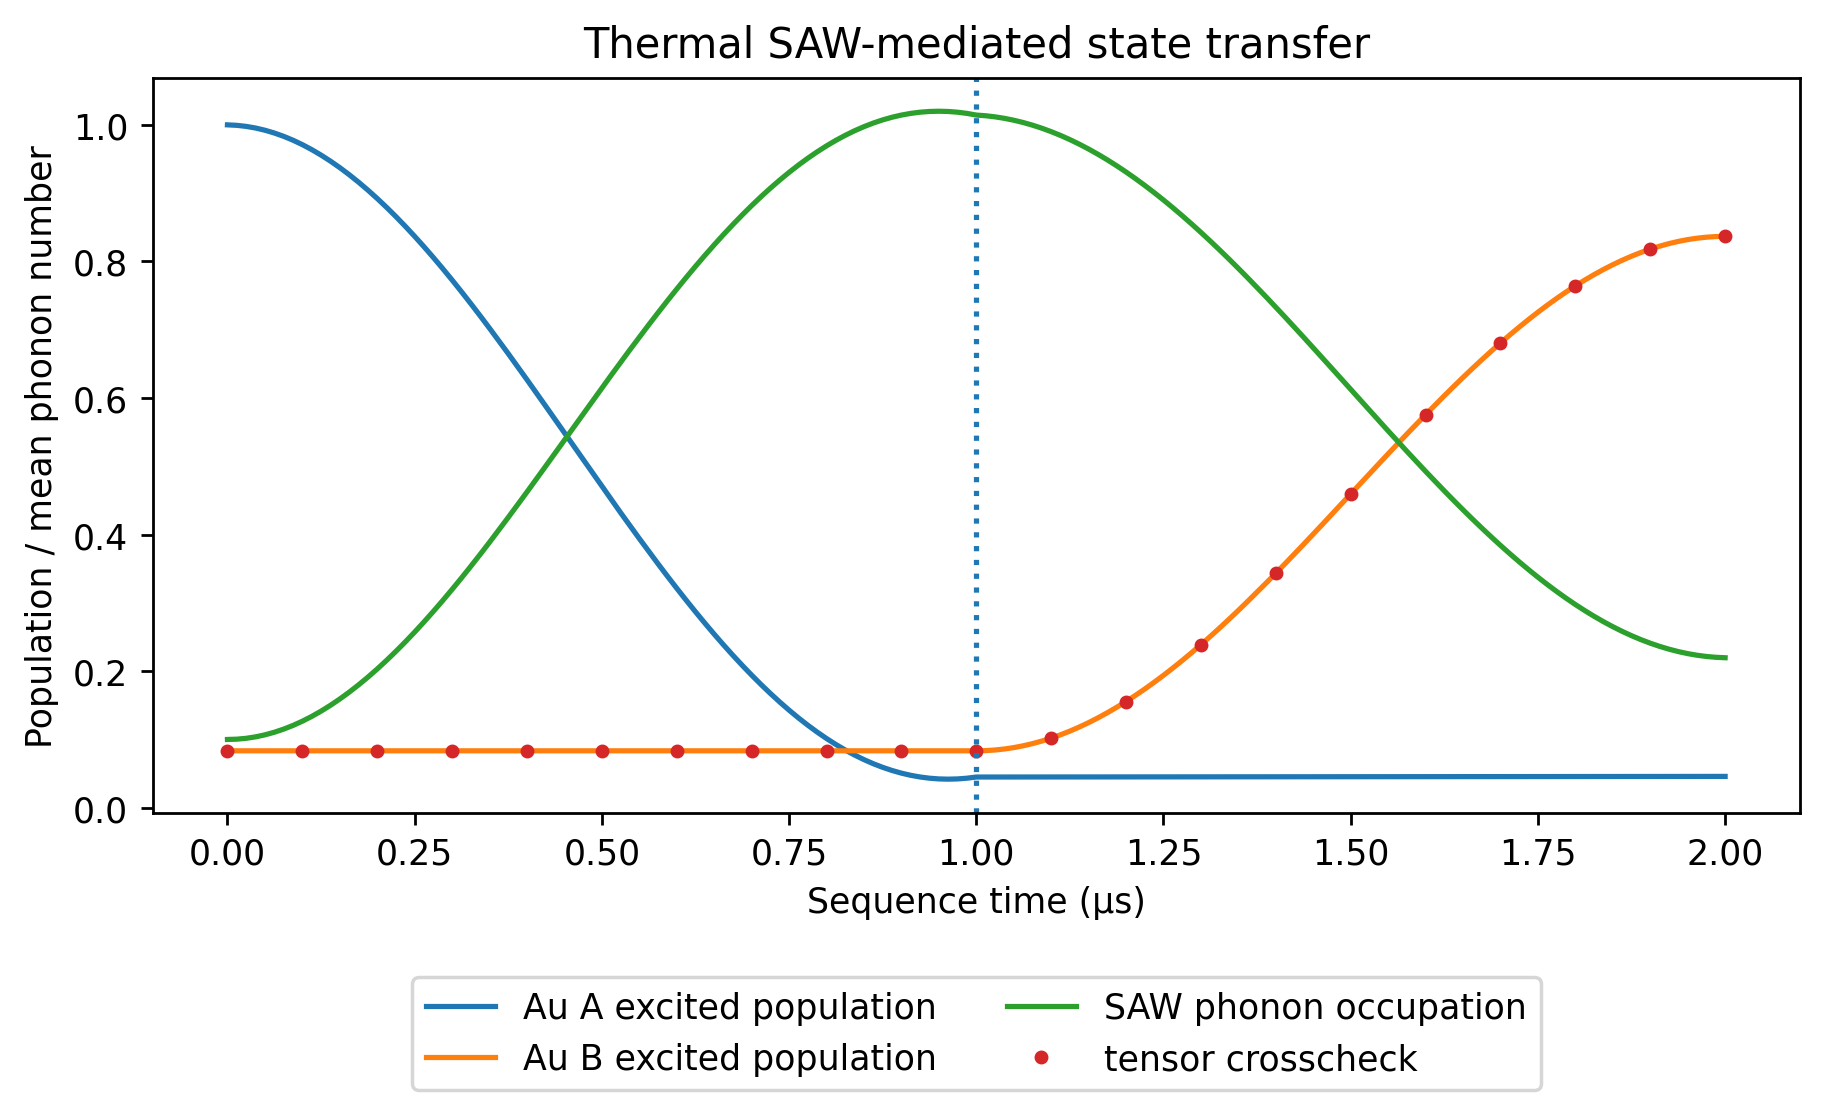

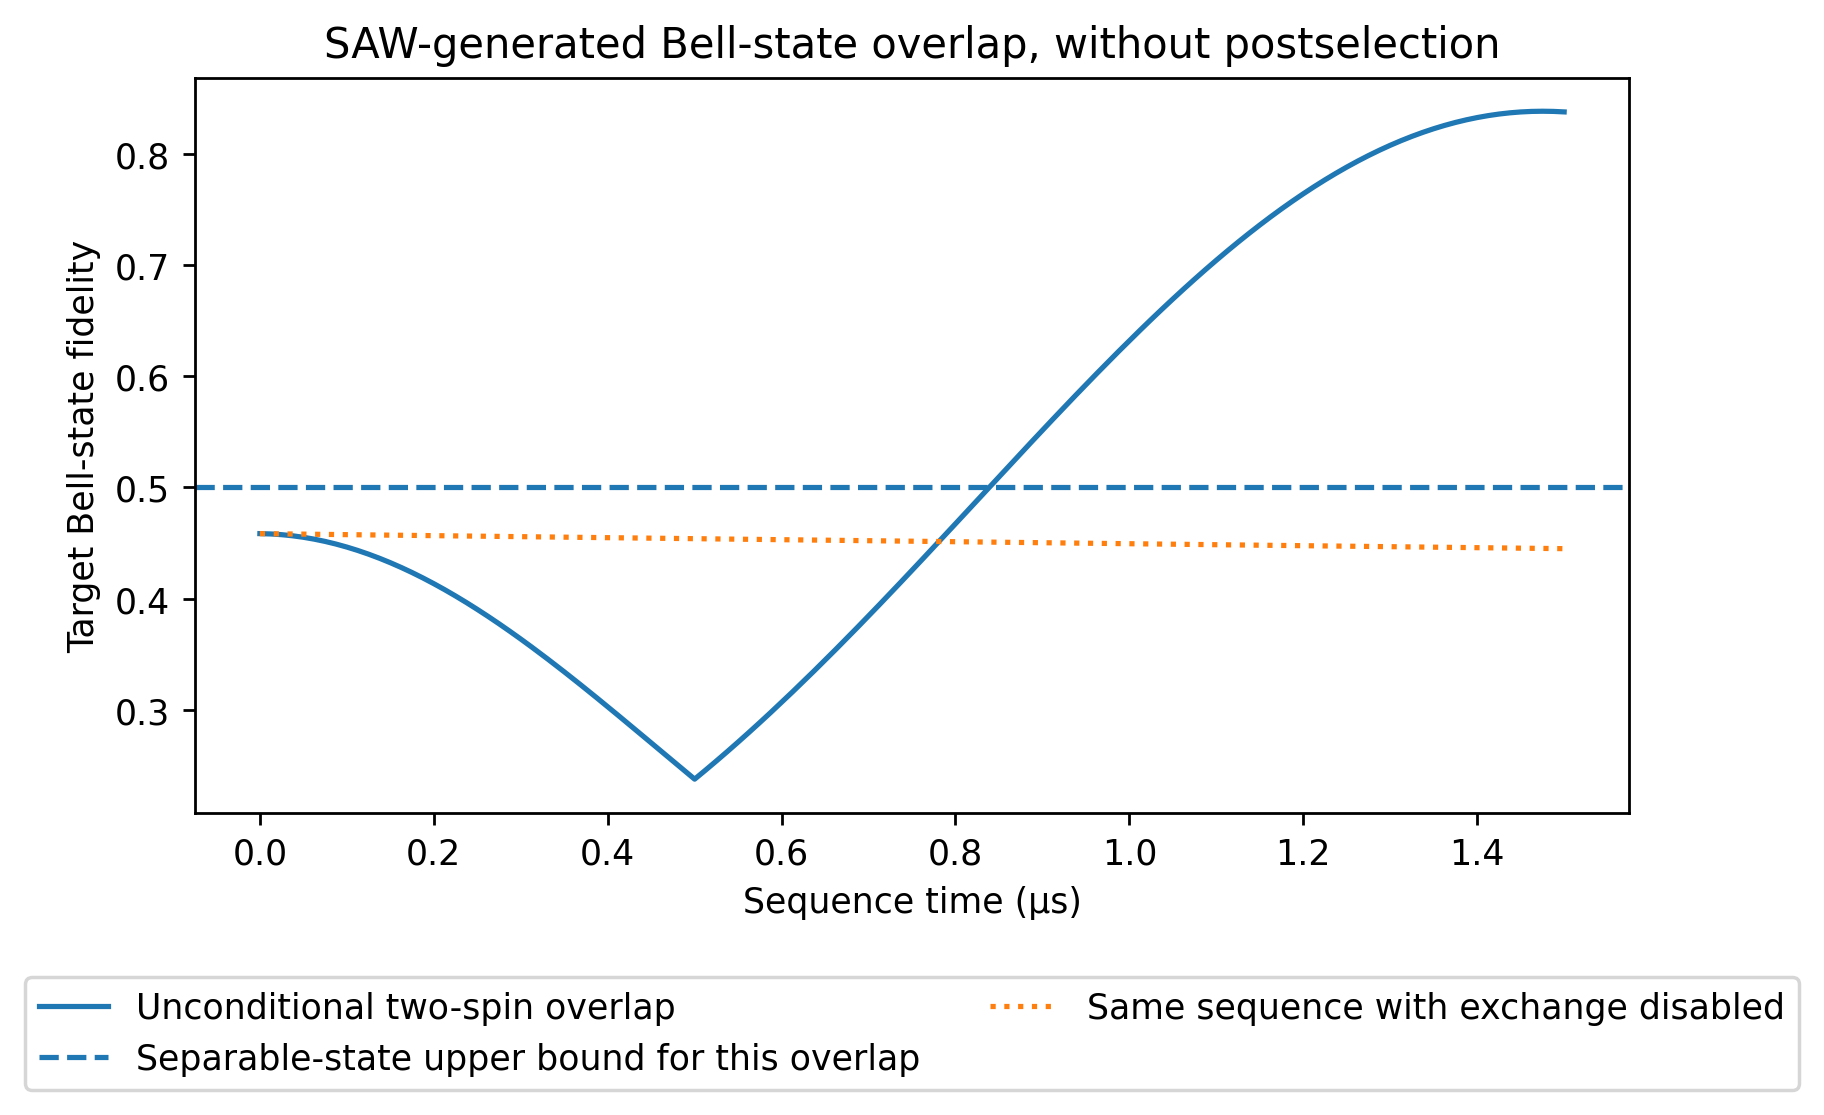

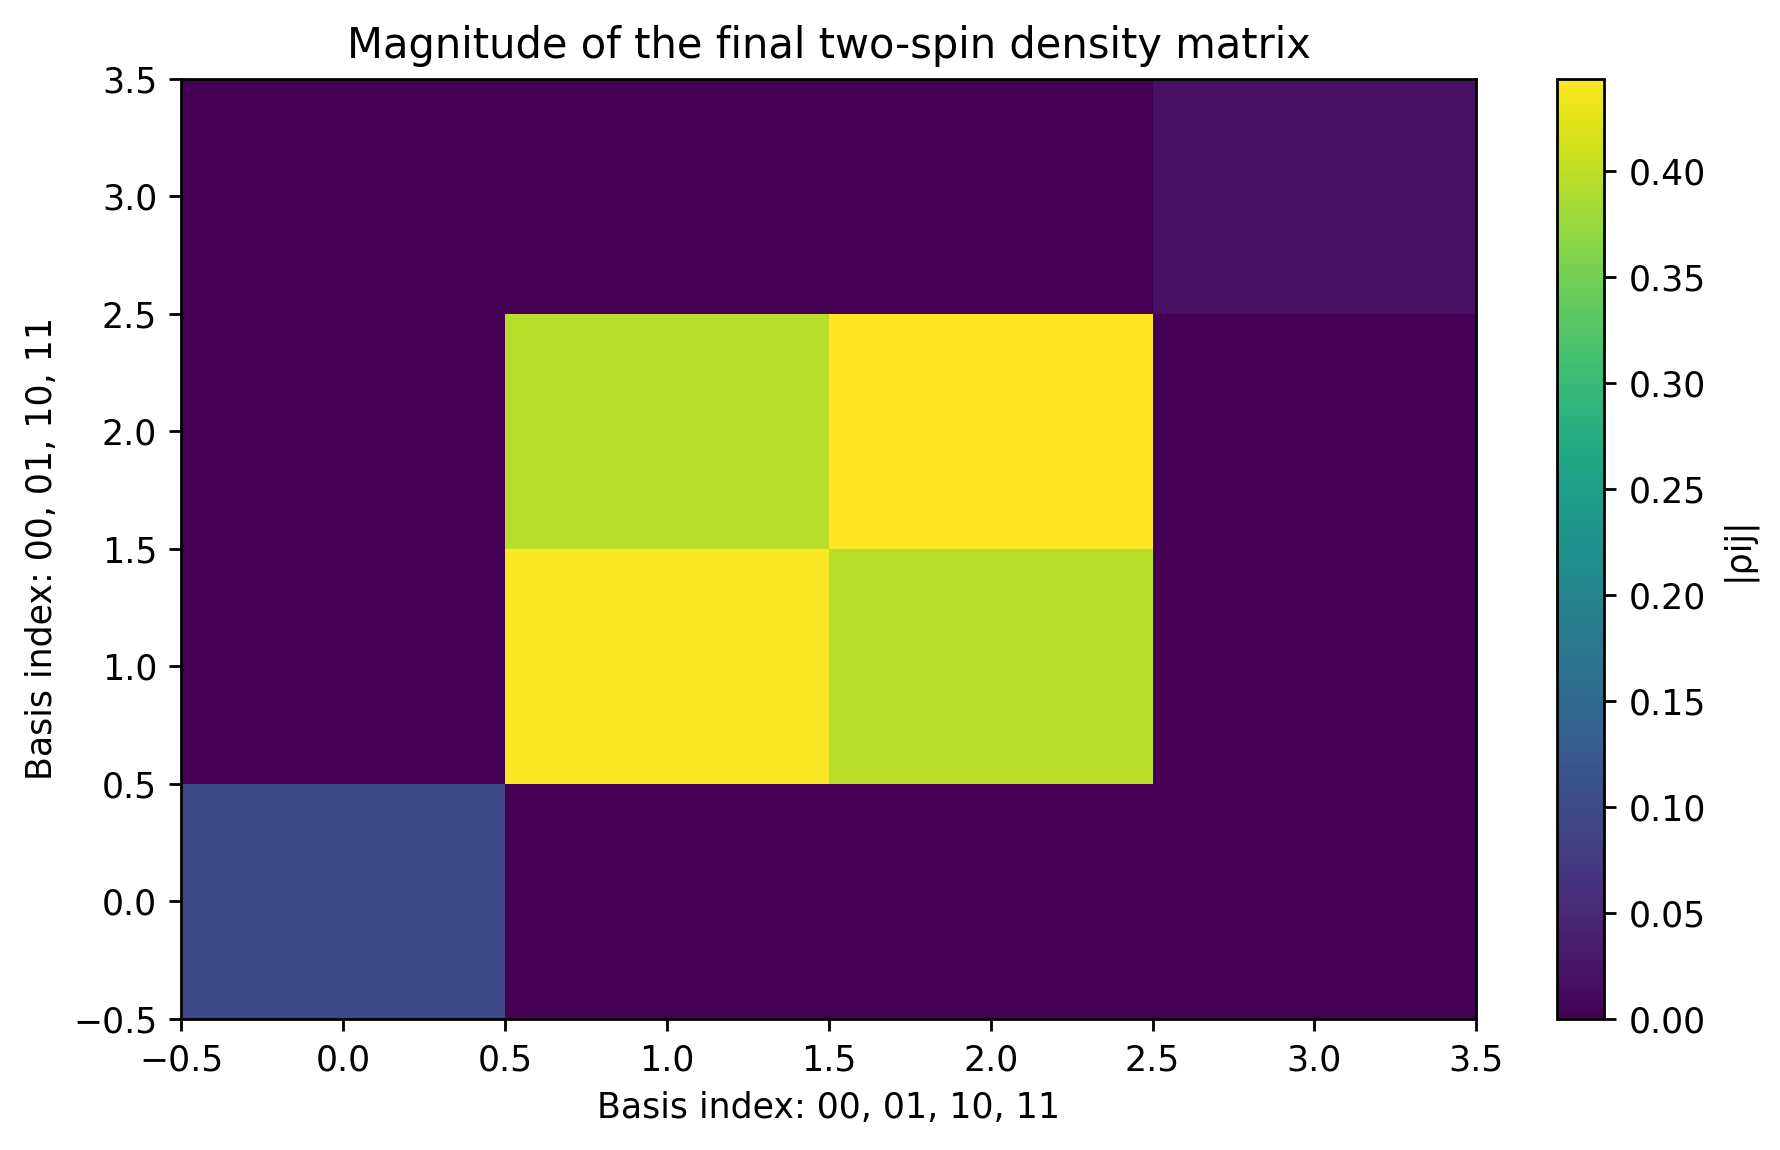

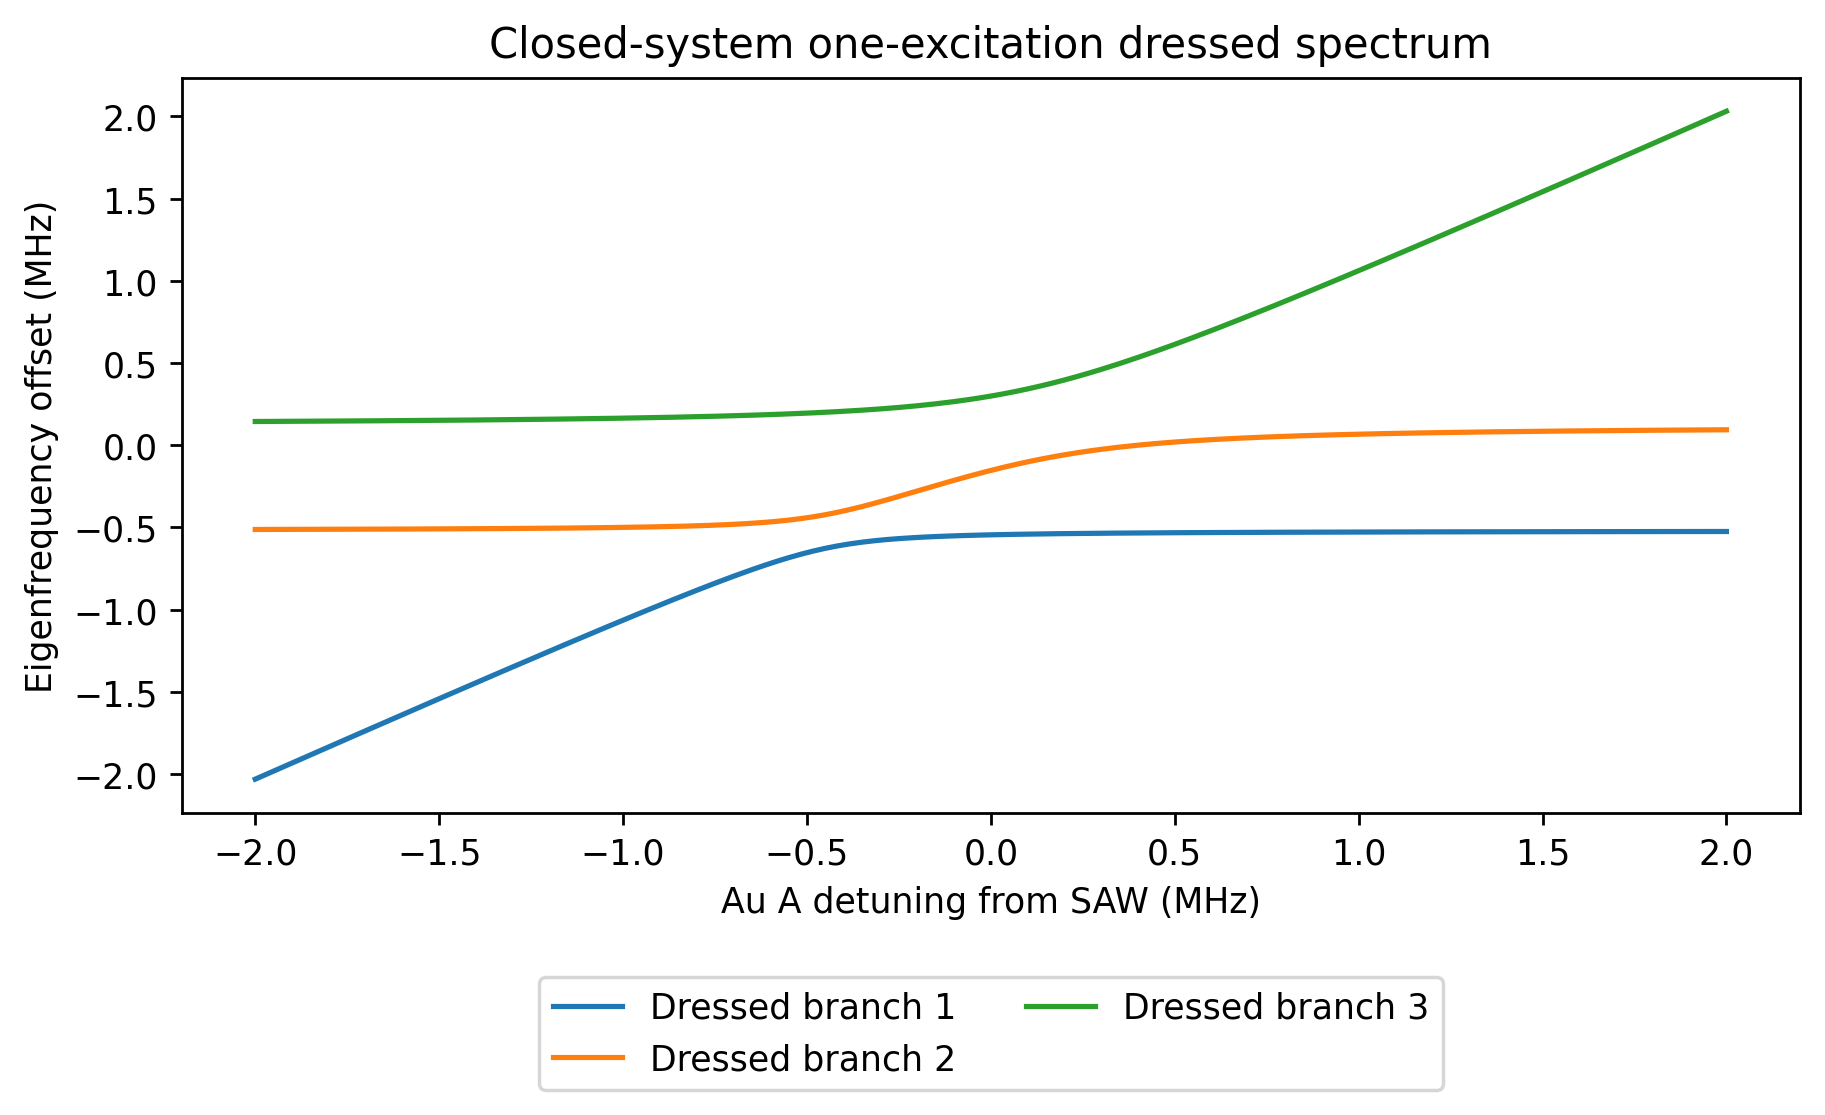

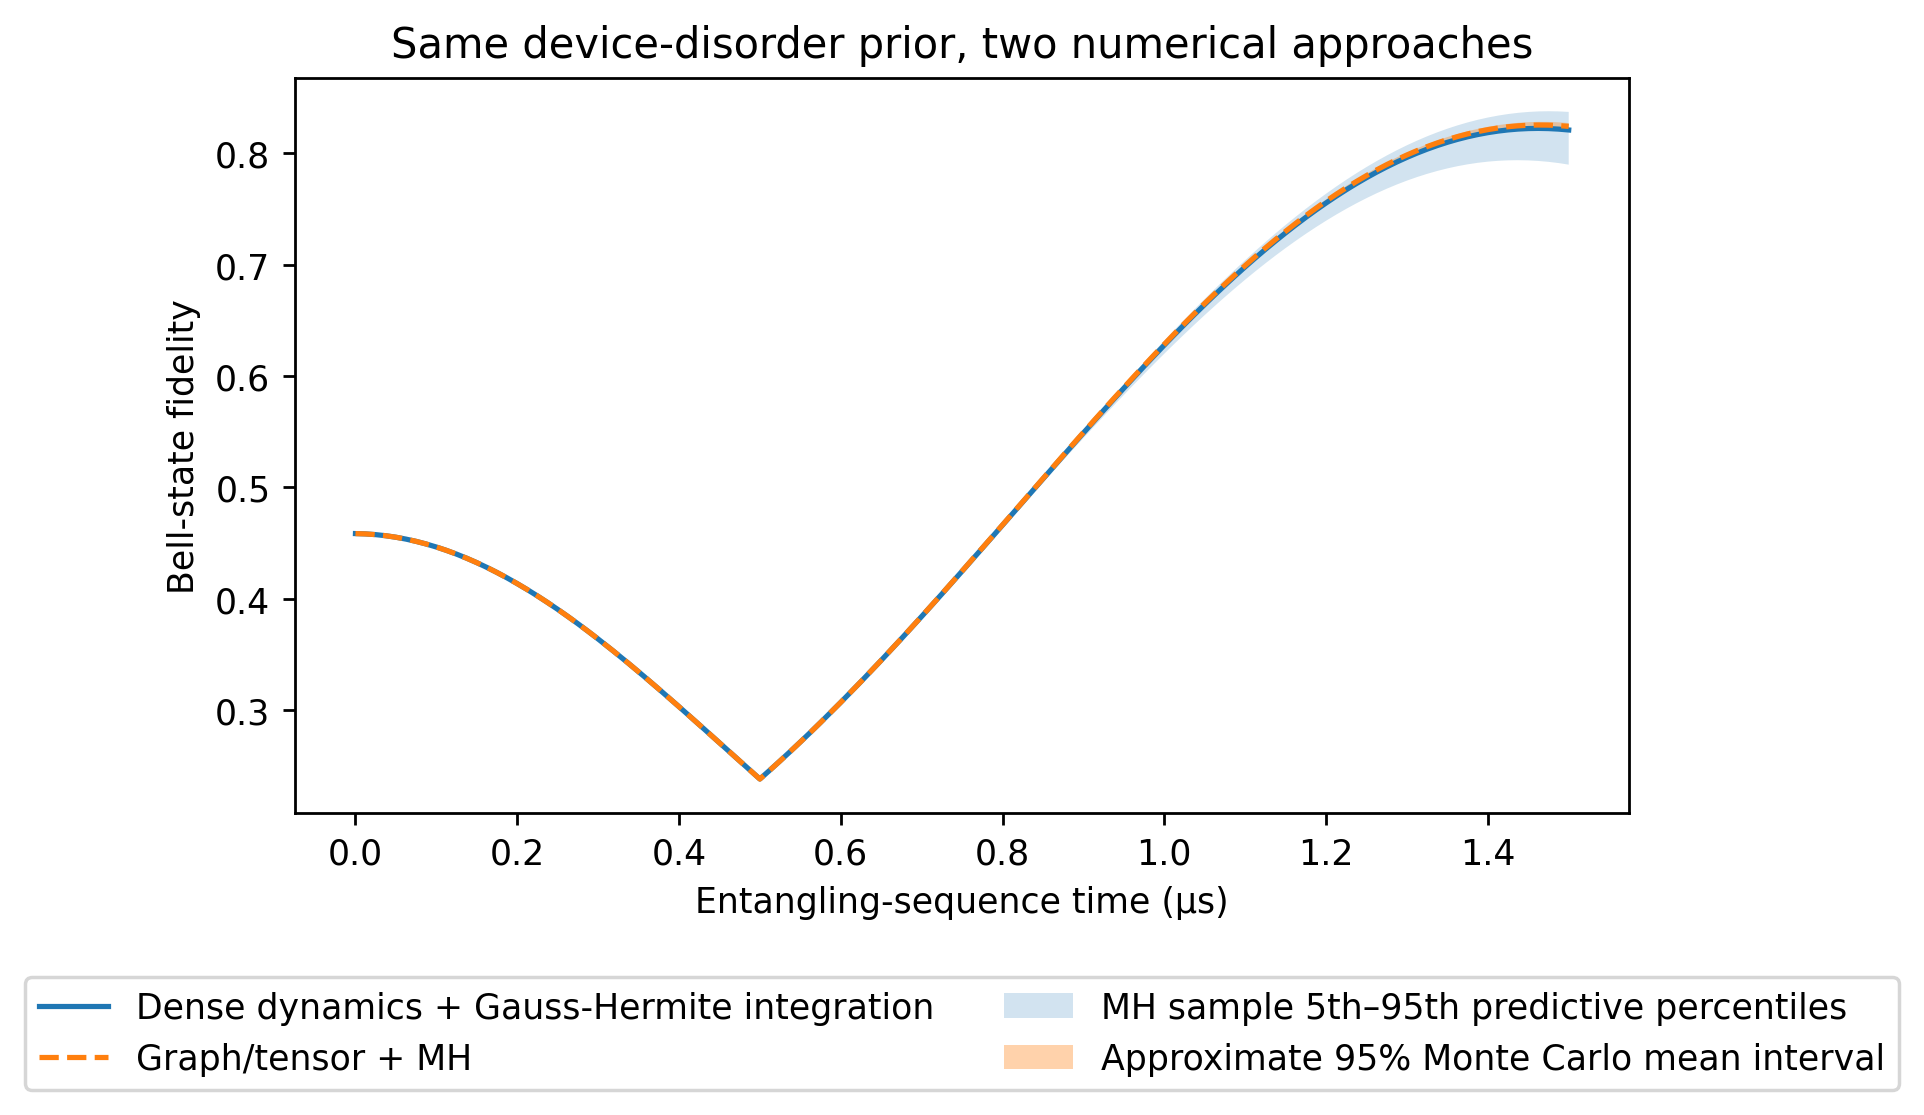

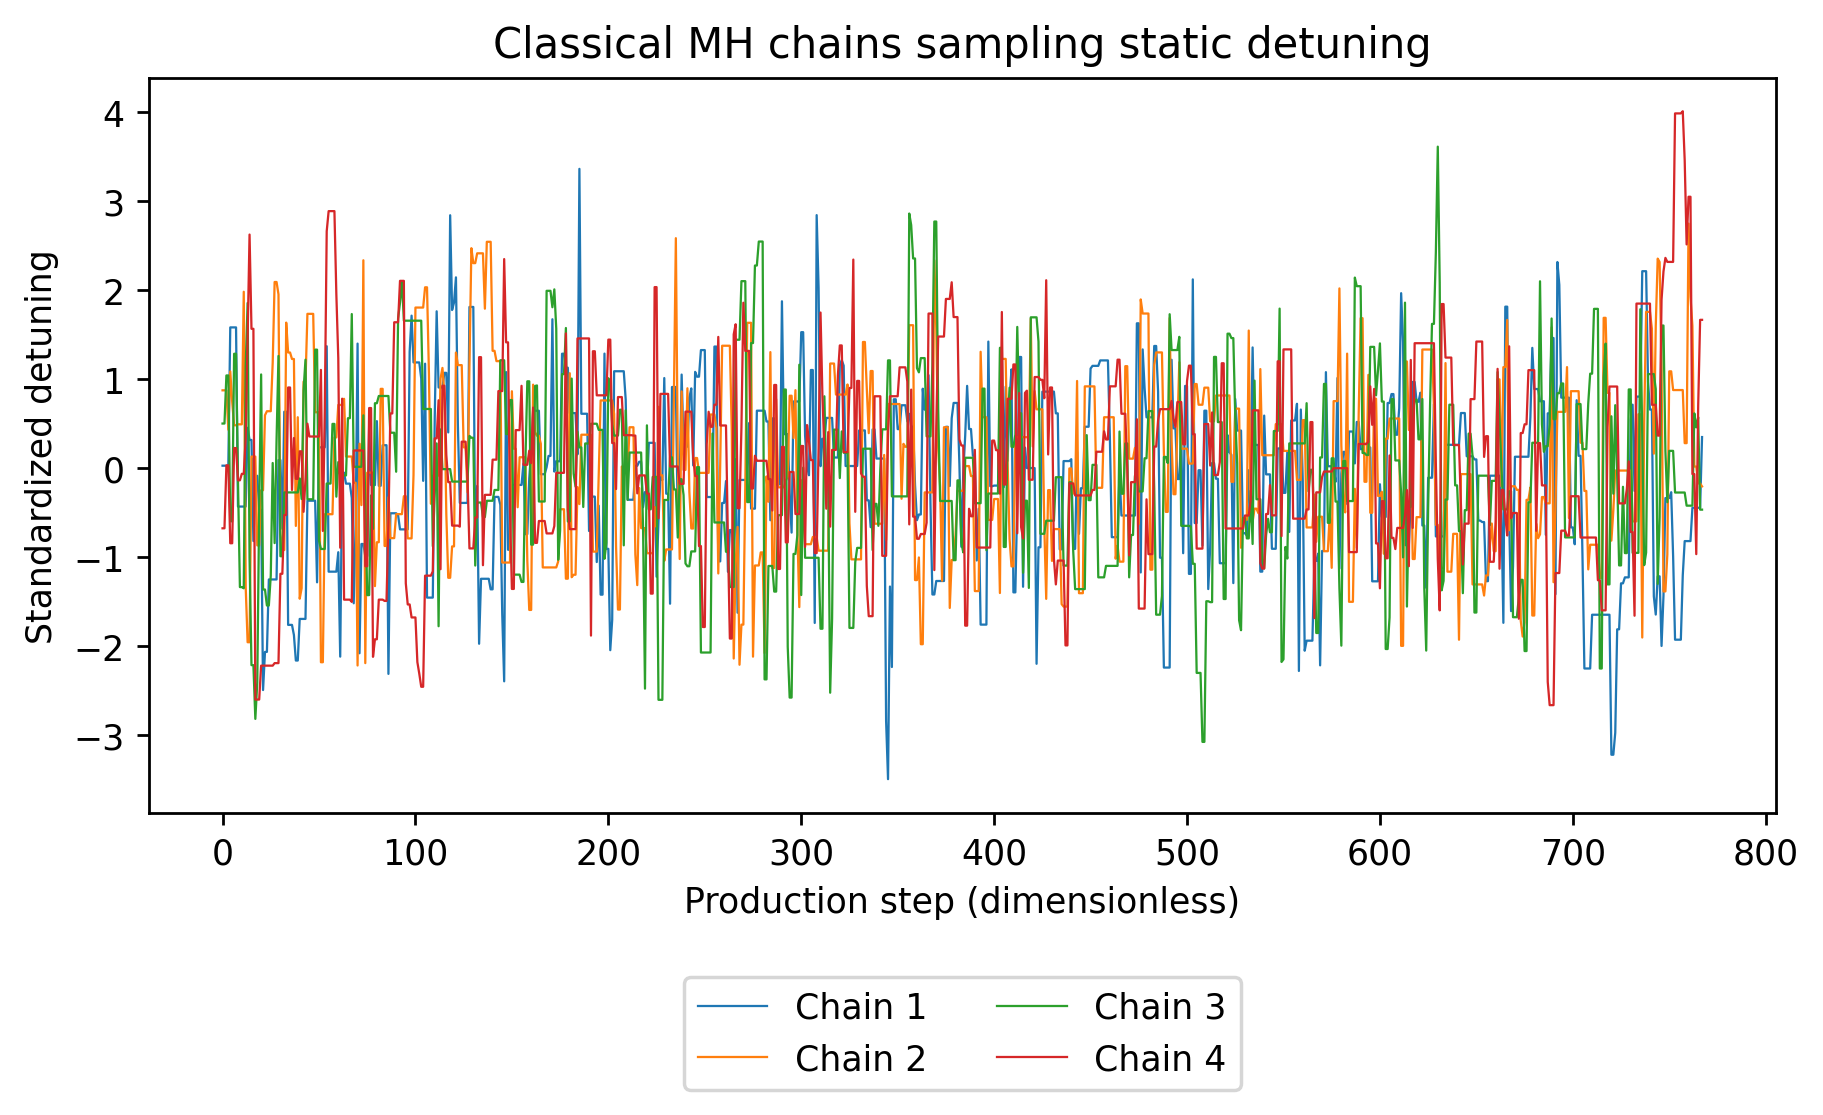

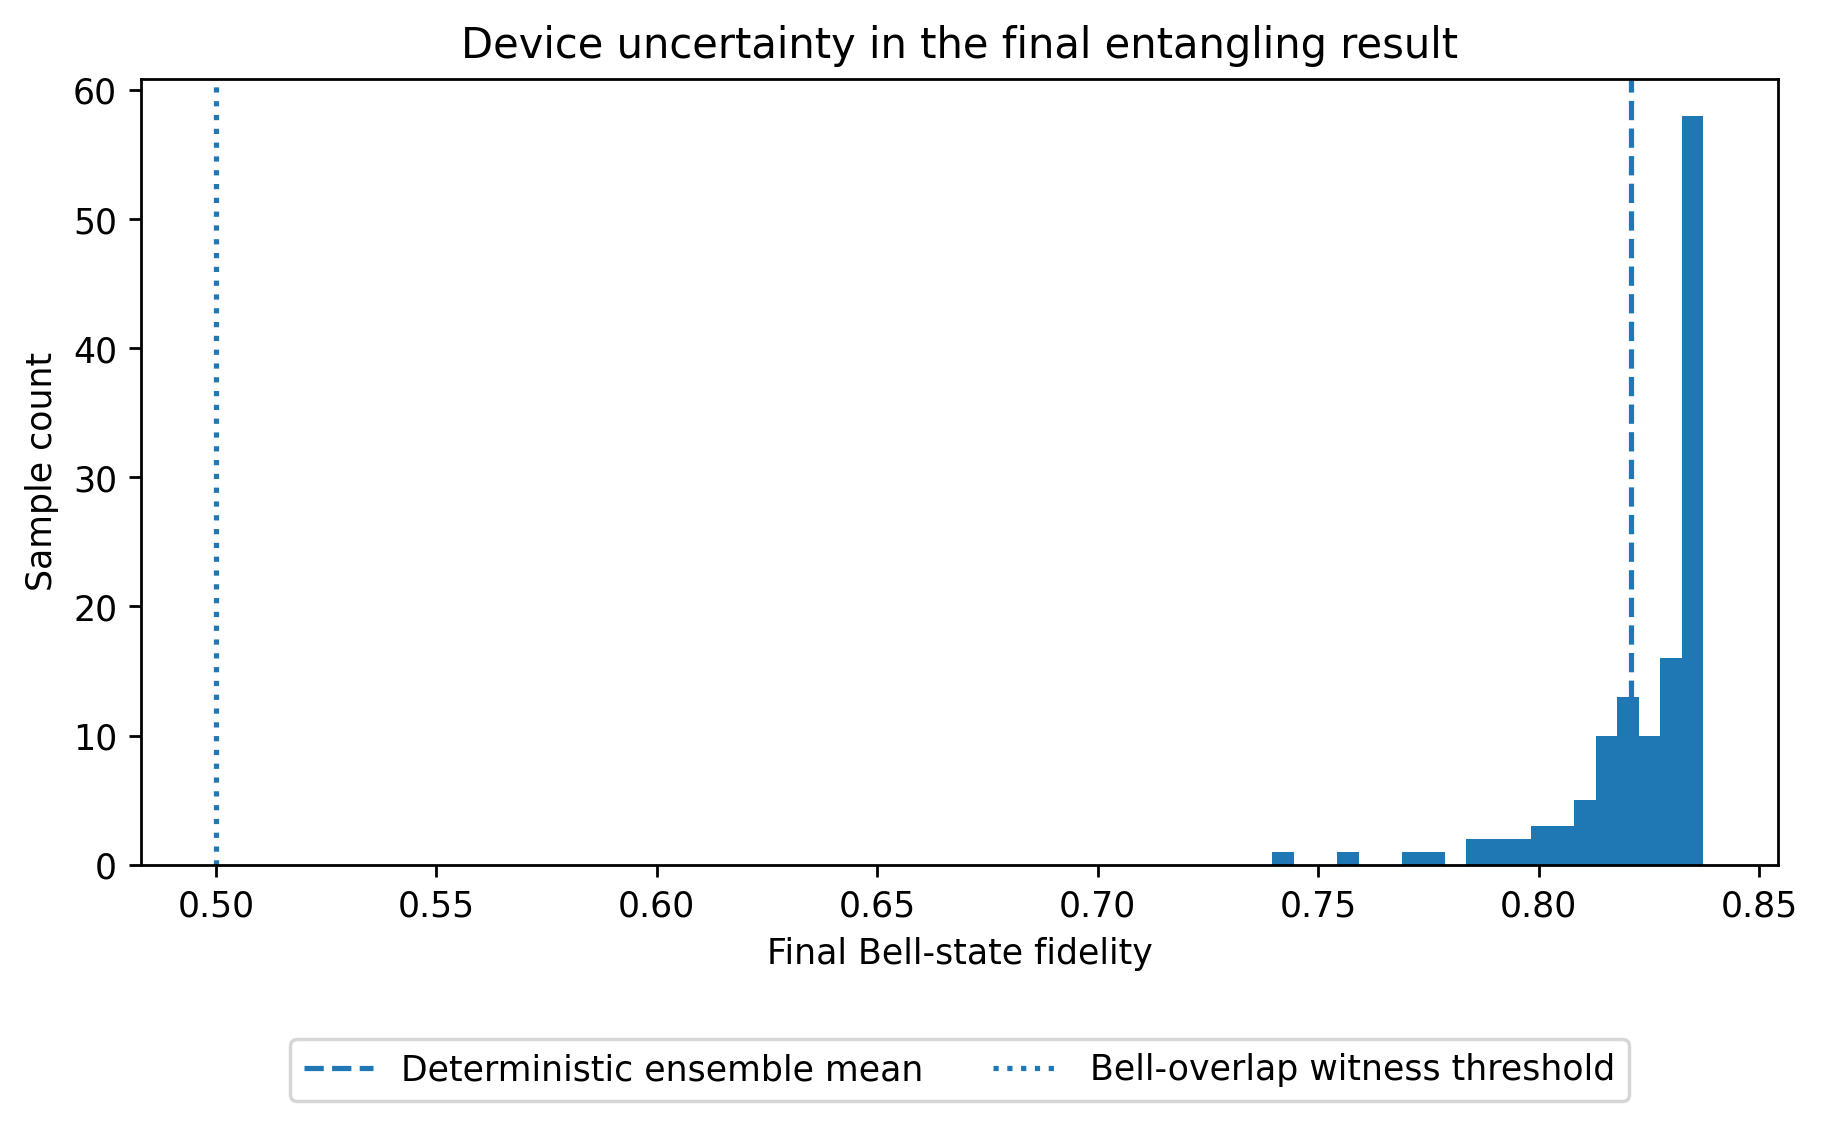

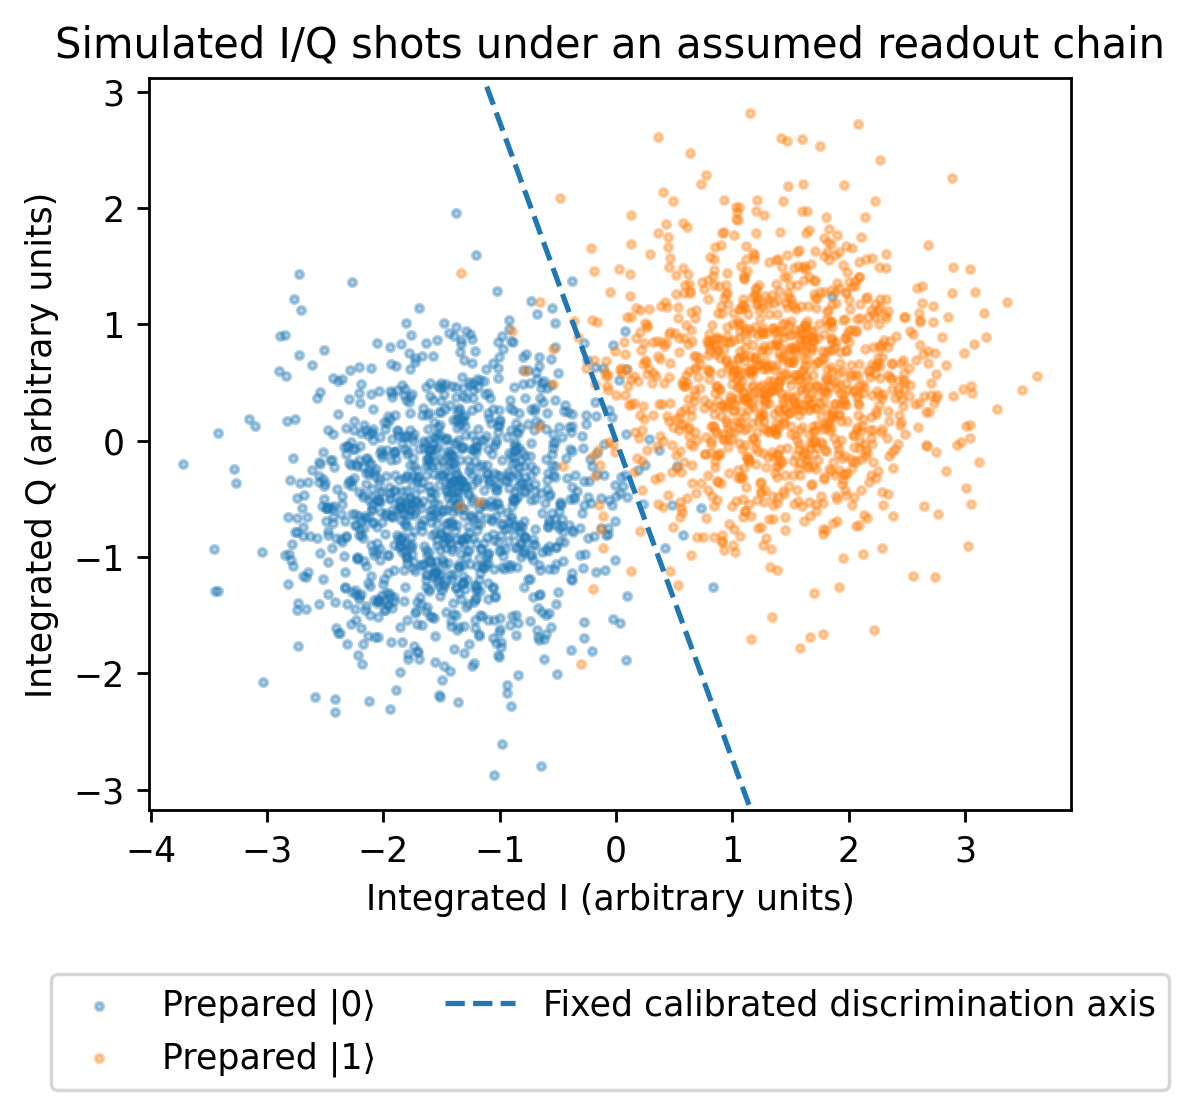

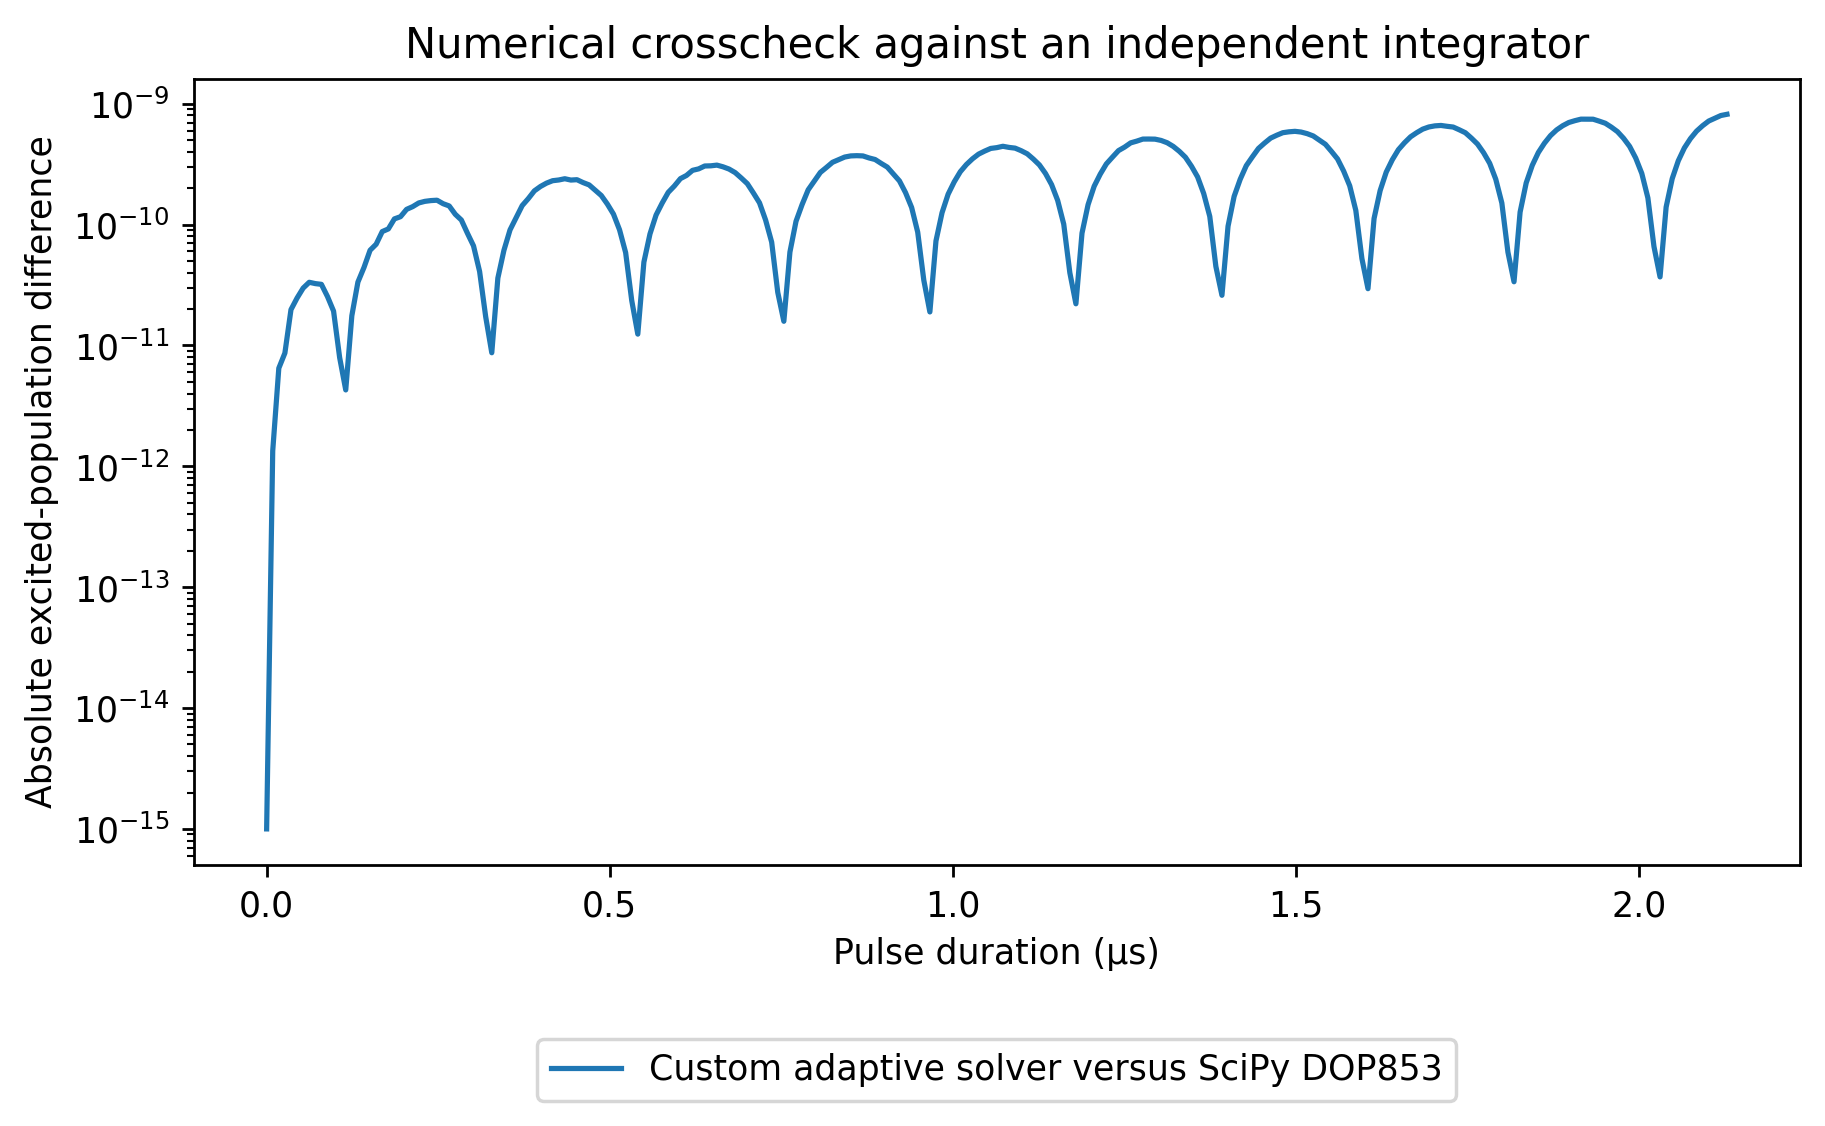


NUMERICAL AND CONDITIONAL PHYSICAL RESULTS
{
  "bus": {
    "dense_vs_hybrid_max_observable_difference": 3.3306690738754696e-16,
    "hybrid_method": "tensor",
    "state_transfer_excited_population_B": 0.83669193955878,
    "bell_fidelity": 0.8373926081819576,
    "bell_negativity": 0.3393745941790868,
    "dense_wall_seconds": 1.1180103820000795,
    "hybrid_wall_seconds": 1.7633660980000059,
    "density_check": {
      "max_trace_error": 1.1102230246251565e-16,
      "max_hermiticity_error": 1.6940658945086007e-21,
      "minimum_eigenvalue": 2.2192609770092565e-10
    },
    "maximum_top_level_population": 4.953128133880838e-08,
    "exchange_disabled_bell_fidelity": 0.4448917583156278,
    "dense_vs_csr_max_observable_difference": 3.3306690738754696e-16,
    "bell_fidelity_change_with_two_extra_bus_levels": 1.1163716617801356e-09
  },
  "independent_checks": {
    "scipy_dop853_max_population_error": 8.18473844255152e-10,
    "closed_system_resonant_rabi_max_error": 1.4168745500

/content/sot_saw_gold_results.zip

In [15]:
RESULTS = main(CFG)

## Experiments that replace the largest assumptions

| Model quantity | Measurement or calculation that supplies it | Decision enabled |
| :--- | :--- | :--- |
| Cluster charge, composition, ligand and spin manifold | Mass/charge identification, EPR or ESR, field-dependent spectroscopy and a relativistic electronic-structure model | Select a reproducible microscopic qubit candidate |
| $f_{01}$, nearest accessible transitions and transition matrix elements | Power- and field-dependent spectroscopy, polarization selection, multi-tone excitation | Replace the illustrative doublet and hypothetical leakage spectrum |
| $T_1$, $T_2^*$, echo $T_2$ and source-on excess noise | Time-domain relaxation, Ramsey, echo, and interleaved source-on/source-off control | Establish whether local SOT control helps after its noise and heating cost |
| Local microwave field and source phase correlation | Calibrated spin response or a nanoscale spin sensor; linewidth, startup and phase-pair measurements | Check finite-pulse control and Ramsey reproducibility |
| SAW mode shape, effective mass and strain tensor | Elastic/piezoelectric finite-element eigenmodes and calibrated acoustic measurements | Replace the zero-point displacement and strain estimate |
| Transverse single-phonon $g$ | Calibrated strain response plus microscopic selection rules, resolved hybridization and quantum-regime swap tests | Determine whether the target exchange rate is credible |
| Bus $Q$, thermal occupation and local temperature | Ringdown, calibrated thermometry and suitable noise/sideband measurements | Set thermal loading, cutoff and loss rates |
| I/Q pointer and detector backaction | Independently prepared states, repeated-readout correlations and calibrated acquisition | Separate assignment error from detector-induced decoherence |
| Parameter disorder distribution | Measurements across multiple sites and preparations | Replace the illustrative Gaussian prior and justify MH inference |

Begin with one spin-active gold cluster and one SOT source, then add a SAW resonator. Comparing source-on and source-off coherence and extracting a transverse acoustic matrix element will be more informative than expanding to a many-site layout before those coefficients are known. The code's two-spin experiment becomes useful once a plausible single-phonon coupling range is available.

## Controlled reruns

Modify `CFG` before the final execution cell. The following examples are independent scenarios, each started from `Settings()`.

```python
# Require the GPU and test CSR operators at the default small Hilbert size.
CFG = dataclasses.replace(Settings(), backend="cupy", require_gpu=True,
                          sparse_policy="always")

# Test loss of relative phase between the two Ramsey pulses.
CFG = dataclasses.replace(Settings(), source_phase_reproducible=False)

# Compare a colder, higher-frequency matched spin and SAW design.
CFG = dataclasses.replace(Settings(), qubit_frequency_mhz=5000.0,
                          saw_frequency_mhz=5000.0, temperature_k=0.020)

# Expand the quantum predictions used to estimate the disorder-averaged result.
CFG = dataclasses.replace(Settings(), mh_production_steps=2048,
                          mh_prediction_samples_per_chain=32)

# Disable exchange without changing the reference pulse durations.
CFG = dataclasses.replace(Settings(), exchange_enabled=False)
```

Changing frequency also changes the required bias field and acoustic scales; material parameters need reassessment for the new regime. Setting the coupling near the illustrative 520 Hz estimate leads to hundreds of microseconds per swap and exposes the assumed coherence limit. Such weak-coupling runs are longer; increase resource caps deliberately and inspect the coupling-budget plot first. This implementation covers a standing-wave single-mode cavity. Propagating interconnects with appreciable transit delays require a multimode or input–output extension.

## Primary literature and software references

1. Chen, X., Strange, M. and Häkkinen, H. (2012). *Non-magnetic and magnetic thiolate-protected Au25 superatoms on Cu(111), Ag(111) and Au(111) surfaces*. Physical Review B, 85, 085422. DOI `10.1103/PhysRevB.85.085422`. Public manuscript `https://arxiv.org/abs/1201.4269`. Electronic-structure support for chemistry- and surface-sensitive cluster models; this calculation supplies neither a gold-qubit coherence time nor an acoustic exchange rate.
2. Jiang, D.-e. and Whetten, R. L. (2009). *Magnetic doping of a thiolated-gold superatom*. Physical Review B, 80, 115402. DOI `10.1103/PhysRevB.80.115402`. Public manuscript `https://arxiv.org/abs/0906.0030`. A separately identified doped-cluster route; a magnetic dopant changes the proposed material and is absent from the default model.
3. Zhang, H. et al. (2020). *Spin-torque oscillation in a magnetic insulator probed by a single-spin sensor*. Physical Review B, 102, 024404. DOI `10.1103/PhysRevB.102.024404`. Public manuscript `https://arxiv.org/abs/1810.07306`. Supports nanoscale spin-torque microwave-source characterization; its sensor is an NV center in diamond.
4. Schuetz, M. J. A. et al. (2015). *Universal Quantum Transducers based on Surface Acoustic Waves*. Physical Review X, 5, 031031. DOI `10.1103/PhysRevX.5.031031`. Public manuscript `https://arxiv.org/abs/1504.05127`. Provides the quantized acoustic-bus and transduction basis.
5. Golter, D. A. et al. (2016). *Coupling a Surface Acoustic Wave to an Electron Spin in Diamond via a Dark State*. Physical Review X, 6, 041060. DOI `10.1103/PhysRevX.6.041060`. Public manuscript `https://arxiv.org/abs/1608.01356`. Demonstrates a specific optical three-level SAW–spin mechanism in diamond; its coupling coefficients cannot be transferred directly to a gold-cluster spin.
6. CuPy development team. *Installation*, stable documentation, accessed September 2026. `https://docs.cupy.dev/en/stable/install.html`. Describes the CUDA 12 and CUDA 13 wheel families and single-distribution installation requirement.
7. QuTiP development team. *Lindblad Master Equation Solver*, stable documentation, accessed September 2026. `https://qutip.readthedocs.io/en/stable/guide/dynamics/dynamics-master.html`.

The references support component principles and computational methods. The device coefficients used here remain declared assumptions pending measurements on the integrated gold-cluster platform.
